# First Implementation 


>>There is the pipeline
**camera.py**: builds the intrinsics for each pyramid level
**frameData.py**: stores image, derivatives, inverse depth, and pose
**pose_estimator_gauss_newton.py**: optimizes the pose
**common.py**: bilinear interpolation
**dataset/desktop_dataset/images**: input images
**Depth-Anything**: computes depth maps on the fly from the images


### Import


In [1]:
from pathlib import Path
import copy
import hashlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import importlib.util
try:
    import camera
except ModuleNotFoundError:
    camera_path = SCRIPT_DIR / "camera.py"
    if camera_path.exists():
        spec = importlib.util.spec_from_file_location("camera", str(camera_path))
        camera = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(camera)
        sys.modules["camera"] = camera
    else:
        raise
import common
import frameData
import pose_estimator_gauss_newton


In [2]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize



C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:


DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


--------------

### Notebook utility functions




---
### Convert to frame, create a list of these frames

In [4]:
import convert_video_frame
VIDEO_PATH = Path(r"C:\Users\conqu\Downloads\fake_bike.mp4")
FRAMES_OUTPUT_DIR = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150")
IMAGE_OUTPUT_DIR = PROJECT_ROOT / "image"
IMAGE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if FRAMES_OUTPUT_DIR.exists():
    for existing_file in FRAMES_OUTPUT_DIR.glob("*.png"):
        existing_file.unlink()
else:
    FRAMES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise ValueError(f"Impossible d'ouvrir la video : {VIDEO_PATH}")

fps = float(cap.get(cv2.CAP_PROP_FPS))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
max_frames = 150
saved_idx = 0

print(f"Video source : {VIDEO_PATH}")
print(f"FPS : {fps}")
print(f"Nombre total de trames dans la video : {frame_count}")
print(f"Extraction des {max_frames} premieres frames vers : {FRAMES_OUTPUT_DIR}")

while saved_idx < max_frames:
    ret, frame = cap.read()
    if not ret or frame is None:
        break

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame_path = FRAMES_OUTPUT_DIR / f"frame_{saved_idx:05d}.png"
    if not convert_video_frame.save_frame(frame_path, gray_frame):
        cap.release()
        raise IOError(f"Echec de l'ecriture de l'image : {frame_path}")

    saved_idx += 1

cap.release()
print(f"{saved_idx} frames sauvegardees dans : {FRAMES_OUTPUT_DIR}")

if saved_idx < 3:
    raise ValueError("Il faut au moins 3 frames pour estimer les intrinseques.")


Video source : C:\Users\conqu\Downloads\fake_bike.mp4
FPS : 30.189198714192802
Nombre total de trames dans la video : 308
Extraction des 150 premieres frames vers : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150


150 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150


In [5]:
dossier_fake = FRAMES_OUTPUT_DIR

In [6]:
fake_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_fake.rglob("*.png")
    if f.is_file()
)

print(f"{len(fake_frame_paths)} fichiers trouves dans {dossier_fake}")

if len(fake_frame_paths) != 150:
    raise ValueError(f"Le dossier de travail doit contenir exactement 150 frames, obtenu: {len(fake_frame_paths)}")


150 fichiers trouves dans C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150


In [7]:

KEYFRAME_PATH = fake_frame_paths[0]
TARGET_PATH= fake_frame_paths[1]

print(KEYFRAME_PATH)
print(TARGET_PATH)

C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150\frame_00000.png
C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150\frame_00001.png


Here we rewrite a few small helper functions to make the pipeline explicit:

- load a grayscale image from its path
- compute a depth map with Depth Anything
- convert depth -> inverse depth
- quickly display a 4x4 matrix

The depth is inferred directly from the corresponding image with the `vitb` encoder, and can optionally be cached in `depth_anything_cache/vitb` to avoid recomputing it every time.

The important conversion is:

$$
\rho = \frac{1}{d}
$$

where **d** is the depth and **rho** is the inverse depth expected by the solver.

In [8]:


#PERMET DE NORMALISER LE CHEMIN DE L'IMAGE, EN S'ASSURANT QU'IL EST ABSOLU ET QU'IL EXISTE
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path



#PERMET DE CONSTRUIRE LE CHEMIN DE CACHE POUR LA CARTE DE PROFONDEUR CORRESPONDANTE À UNE IMAGE, EN UTILISANT UN HASH DU CHEMIN DE L'IMAGE POUR ÉVITER LES CONFLITS
def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


#PERMET DE CHARGER UNE IMAGE EN NIVEAUX DE GRIS À PARTIR D'UN CHEMIN, EN UTILISANT OPENCV POUR LIRE LE FICHIER ET LE CONVERTIR EN UN TABLEAU NUMPY
def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


### Extract keyframe

Here we load:

- the reference image specified in `KEYFRAME_PATH`
- the depth map inferred by **Depth Anything** for this image

This image provides the base 3D geometry.


In [9]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)


xFormers not available


xFormers not available


Depth Anything loaded on cpu (97.47M parameters)


In [10]:

print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image_path = C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150\frame_00000.png
keyframe_image shape = (1280, 704) dtype = uint8
keyframe_depth shape = (1280, 704) dtype = float32
depth min/max = 0.0 109.40399169921875
valid depth ratio = 0.7173018022017046


Text(0.5, 1.0, 'Inverse depth')

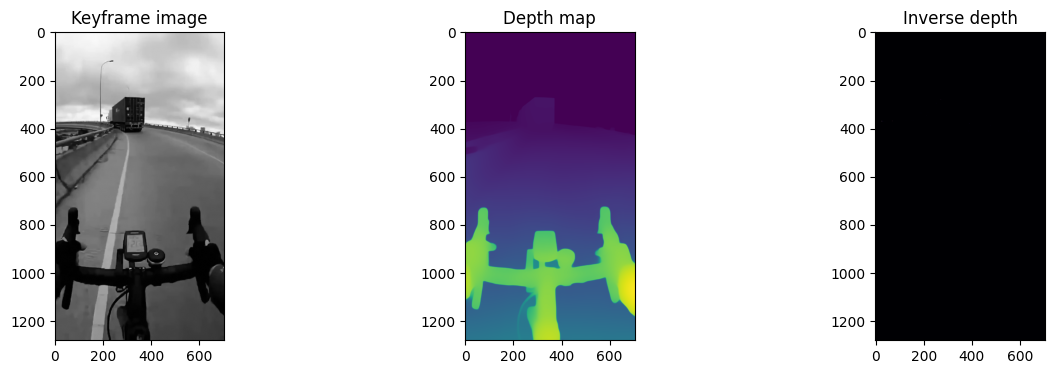

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))




axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")


axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")




### **Intrinsics estimated from fake_bike.mp4**


Les intrinseques sont estimees automatiquement une seule fois a partir de 3 frames reparties sur les **150 premieres images** de `fake_bike.mp4`.
Le resultat alimente ensuite **tout le notebook** et la boucle sequence complete.



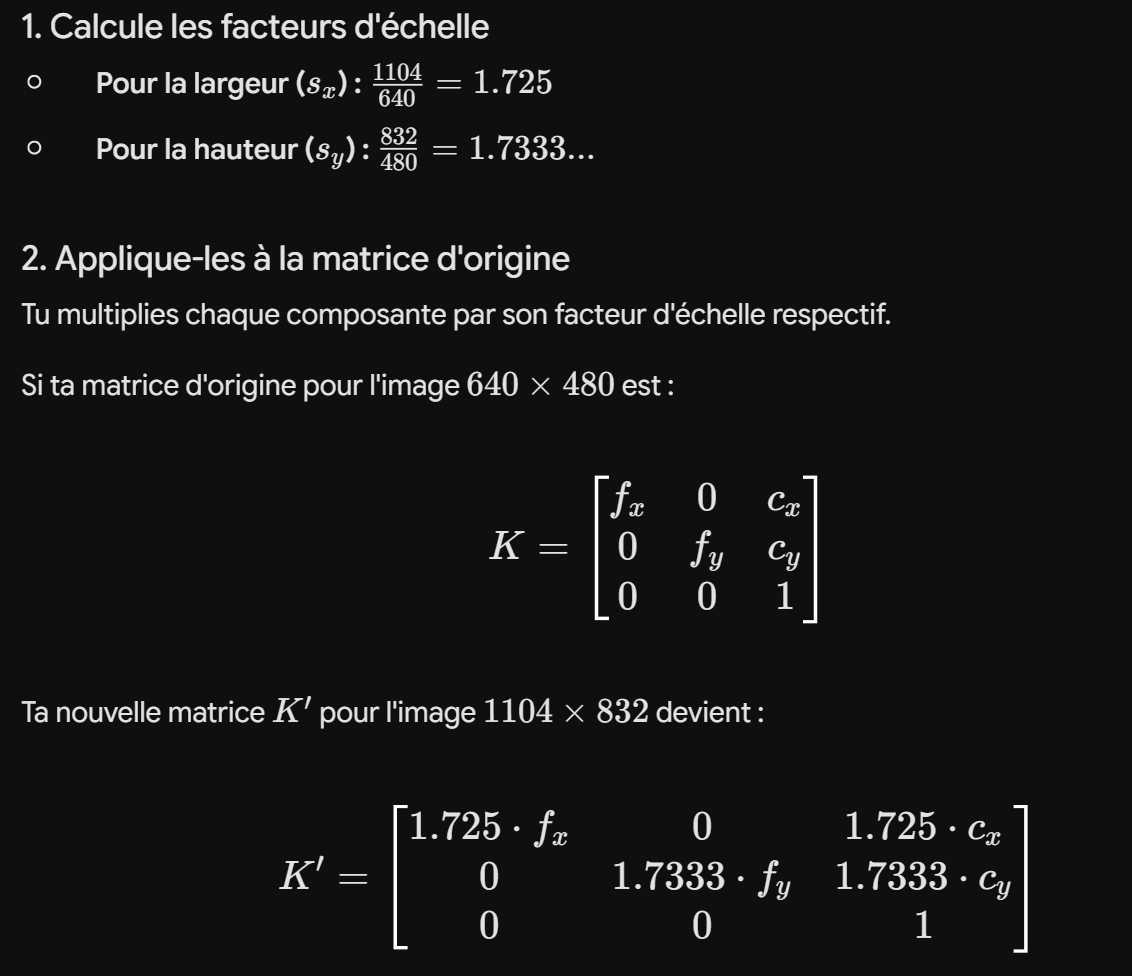

In [12]:

import base64
from IPython.display import HTML
with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\capture.png","rb") as f:
    with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\capture.png","rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')
HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')

In [13]:
# ==================================================
# Intrinseques estimees UNE FOIS au debut
# ==================================================
from estimate_intrinsics import estimate_camera_intrinsics_from_frames

loaded_height, loaded_width = keyframe_image.shape[:2]
frames_for_intrinsics = fake_frame_paths[:150]

candidate_index_sets = []
if len(frames_for_intrinsics) >= 3:
    last_index = len(frames_for_intrinsics) - 1
    candidate_index_sets.extend(
        [
            [0, last_index // 2, last_index],
            [last_index // 6, last_index // 2, (5 * last_index) // 6],
            [0, last_index // 3, (2 * last_index) // 3],
            [0, 1, 2],
        ]
    )

candidate_index_sets.append(np.linspace(0, len(frames_for_intrinsics) - 1, 3, dtype=int).tolist())

estimated_K = None
used_intrinsic_paths = None
last_error = None

for raw_indices in candidate_index_sets:
    candidate_indices = [int(min(max(index, 0), len(frames_for_intrinsics) - 1)) for index in raw_indices]
    if len(set(candidate_indices)) < 3:
        continue

    sample_paths = [normalize_image_path(frames_for_intrinsics[index]) for index in candidate_indices]
    sample_frames = [load_gray_image(path) for path in sample_paths]

    try:
        estimated_K = estimate_camera_intrinsics_from_frames(sample_frames)
        used_intrinsic_paths = sample_paths
        break
    except Exception as exc:
        print(f"Echec estimation intrinseques avec indices {candidate_indices}: {exc}")
        last_error = exc

if estimated_K is None:
    raise RuntimeError(f"Impossible d'estimer les intrinseques pour fake_bike.mp4. Derniere erreur: {last_error}")

USER_WIDTH = loaded_width
USER_HEIGHT = loaded_height
USER_FX = float(estimated_K[0, 0])
USER_FY = float(estimated_K[1, 1])
USER_CX = float(estimated_K[0, 2])
USER_CY = float(estimated_K[1, 2])

intrinsics_user = {
    "width": USER_WIDTH,
    "height": USER_HEIGHT,
    "fx": USER_FX,
    "fy": USER_FY,
    "cx": USER_CX,
    "cy": USER_CY,
}

K_user = np.array(
    [
        [USER_FX, 0.0, USER_CX],
        [0.0, USER_FY, USER_CY],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    USER_WIDTH,
    USER_HEIGHT,
)

intrinsics_used_lvl0 = {
    "width": cam.width[0],
    "height": cam.height[0],
    "fx": cam.fx[0],
    "fy": cam.fy[0],
    "cx": cam.cx[0],
    "cy": cam.cy[0],
}

K_used_lvl0 = np.array(
    [
        [cam.fx[0], 0.0, cam.cx[0]],
        [0.0, cam.fy[0], cam.cy[0]],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

print("Loaded keyframe size:")
print("  width  =", loaded_width)
print("  height =", loaded_height)
print()
print("Frames utilisees pour estimer les intrinseques:")
for path in used_intrinsic_paths:
    print(" ", path)
print()
print("Intrinseques estimees au debut du notebook:")
print(intrinsics_user)
print()
print("K_user =")
print(K_user)
print()
print("Internal working resolution used by the pipeline (level 0):")
print("  width  =", intrinsics_used_lvl0["width"])
print("  height =", intrinsics_used_lvl0["height"])
print()
print("K_used_lvl0 =")
print(K_used_lvl0)


Echec estimation intrinseques avec indices [0, 74, 149]: Pas assez d'inliers apres RANSAC: 24 correspondances.


Echec estimation intrinseques avec indices [24, 74, 124]: Pas assez d'inliers apres RANSAC: 18 correspondances.


Echec estimation intrinseques avec indices [0, 49, 99]: Pas assez d'inliers apres RANSAC: 29 correspondances.


Loaded keyframe size:
  width  = 704
  height = 1280

Frames utilisees pour estimer les intrinseques:
  C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150\frame_00000.png
  C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150\frame_00001.png
  C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150\frame_00002.png

Intrinseques estimees au debut du notebook:
{'width': 704, 'height': 1280, 'fx': 4605.830781166069, 'fy': 4605.830781166069, 'cx': 352.0, 'cy': 640.0}

K_user =
[[4605.830781    0.        352.      ]
 [   0.       4605.830781  640.      ]
 [   0.          0.          1.      ]]

Internal working resolution used by the pipeline (level 0):
  width  = 640
  height = 480

K_used_lvl0 =
[[4187.118892    0.        320.      ]
 [   0.       1727.186543  240.      ]
 [   0.          0.          1.      ]]


In [14]:
scale_x = cam.width[0] / USER_WIDTH
scale_y = cam.height[0] / USER_HEIGHT

print("Check that the pipeline camera really comes from the USER intrinsics above:")
print("  scale_x =", scale_x)
print("  scale_y =", scale_y)
print()
print("  USER_FX -> cam.fx[0] :", USER_FX, "->", cam.fx[0])
print("  USER_FY -> cam.fy[0] :", USER_FY, "->", cam.fy[0])
print("  USER_CX -> cam.cx[0] :", USER_CX, "->", cam.cx[0])
print("  USER_CY -> cam.cy[0] :", USER_CY, "->", cam.cy[0])
print()
print("Expected level-0 values after internal resize:")
print("  expected fx =", USER_FX * scale_x)
print("  expected fy =", USER_FY * scale_y)
print("  expected cx =", USER_CX * scale_x)
print("  expected cy =", USER_CY * scale_y)

assert np.isclose(cam.fx[0], USER_FX * scale_x)
assert np.isclose(cam.fy[0], USER_FY * scale_y)
assert np.isclose(cam.cx[0], USER_CX * scale_x)
assert np.isclose(cam.cy[0], USER_CY * scale_y)

print()
print("Assertion passed: the notebook is using the intrinsics defined above.")


Check that the pipeline camera really comes from the USER intrinsics above:
  scale_x = 0.9090909090909091
  scale_y = 0.375

  USER_FX -> cam.fx[0] : 4605.830781166069 -> 4187.118891969153
  USER_FY -> cam.fy[0] : 4605.830781166069 -> 1727.1865429372758
  USER_CX -> cam.cx[0] : 352.0 -> 320.0
  USER_CY -> cam.cy[0] : 640.0 -> 240.0

Expected level-0 values after internal resize:
  expected fx = 4187.118891969153
  expected fy = 1727.1865429372758
  expected cx = 320.0
  expected cy = 240.0

Assertion passed: the notebook is using the intrinsics defined above.


### Verification for every pyramid level

On affiche maintenant les intrinseques utilisees a **chaque niveau** de la pyramide, et on verifie qu elles correspondent bien a la regle automatique du code : division par `2**lvl` a partir du niveau 0.

In [15]:
intrinsics_per_level = []
base_fx = cam.fx[0]
base_fy = cam.fy[0]
base_cx = cam.cx[0]
base_cy = cam.cy[0]
base_width = cam.width[0]
base_height = cam.height[0]

print("Intrinsics used for each pyramid level:")
print()

for lvl in range(len(cam.fx)):
    scale = 2 ** lvl
    expected_fx = base_fx / scale
    expected_fy = base_fy / scale
    expected_cx = base_cx / scale
    expected_cy = base_cy / scale
    expected_width = int(base_width / scale)
    expected_height = int(base_height / scale)

    K_lvl = np.array([
        [cam.fx[lvl], 0.0, cam.cx[lvl]],
        [0.0, cam.fy[lvl], cam.cy[lvl]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    assert np.isclose(cam.fx[lvl], expected_fx)
    assert np.isclose(cam.fy[lvl], expected_fy)
    assert np.isclose(cam.cx[lvl], expected_cx)
    assert np.isclose(cam.cy[lvl], expected_cy)
    assert cam.width[lvl] == expected_width
    assert cam.height[lvl] == expected_height

    intrinsics_per_level.append({
        "level": lvl,
        "scale": scale,
        "width": cam.width[lvl],
        "height": cam.height[lvl],
        "fx": cam.fx[lvl],
        "fy": cam.fy[lvl],
        "cx": cam.cx[lvl],
        "cy": cam.cy[lvl],
        "K": K_lvl,
    })

    print(f"LEVEL {lvl}")
    print(f"  scale  = 1 / {scale}")
    print(f"  size   = {cam.width[lvl]} x {cam.height[lvl]}")
    print(f"  fx, fy = {cam.fx[lvl]:.6f}, {cam.fy[lvl]:.6f}")
    print(f"  cx, cy = {cam.cx[lvl]:.6f}, {cam.cy[lvl]:.6f}")
    print("  K =")
    print(K_lvl)
    print()

print("All assertions passed: each level uses the expected intrinsics.")


Intrinsics used for each pyramid level:

LEVEL 0
  scale  = 1 / 1
  size   = 640 x 480
  fx, fy = 4187.118892, 1727.186543
  cx, cy = 320.000000, 240.000000
  K =
[[4187.118892    0.        320.      ]
 [   0.       1727.186543  240.      ]
 [   0.          0.          1.      ]]

LEVEL 1
  scale  = 1 / 2
  size   = 320 x 240
  fx, fy = 2093.559446, 863.593271
  cx, cy = 160.000000, 120.000000
  K =
[[2093.559446    0.        160.      ]
 [   0.        863.593271  120.      ]
 [   0.          0.          1.      ]]

LEVEL 2
  scale  = 1 / 4
  size   = 160 x 120
  fx, fy = 1046.779723, 431.796636
  cx, cy = 80.000000, 60.000000
  K =
[[1046.779723    0.         80.      ]
 [   0.        431.796636   60.      ]
 [   0.          0.          1.      ]]

LEVEL 3
  scale  = 1 / 8
  size   = 80 x 60
  fx, fy = 523.389861, 215.898318
  cx, cy = 40.000000, 30.000000
  K =
[[523.389861   0.        40.      ]
 [  0.       215.898318  30.      ]
 [  0.         0.         1.      ]]

LEVEL 4
  scal

In [16]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(480, 640), invDepth=(480, 640), grad=(480, 640, 2)
level 1: image=(240, 320), invDepth=(240, 320), grad=(240, 320, 2)
level 2: image=(120, 160), invDepth=(120, 160), grad=(120, 160, 2)
level 3: image=(60, 80), invDepth=(60, 80), grad=(60, 80, 2)
level 4: image=(30, 40), invDepth=(30, 40), grad=(30, 40, 2)


### Extract the the current image




Now we take a second image, specified in `TARGET_PATH`.

This is the image whose relative pose with respect to the keyframe we want to estimate.
At first, its pose is the identity, and then the solver updates it.

In [17]:
current_image_path = normalize_image_path(TARGET_PATH)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



### Recap

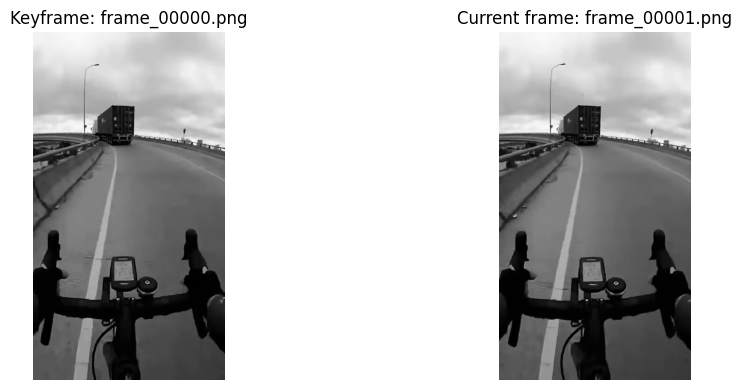

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")


axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


---
### **Initial pose and optimization updates**

Dans la cellule suivante, `pose_solver` est cree avec `cam`.
Donc les intrinseques utilisees pour l'estimation de pose sont bien celles affichees juste au-dessus.


In [19]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

print("Proof before optimization:")
print("  pose_solver.camera is cam ->", pose_solver.camera is cam)
print("  pose_solver.camera.fx[0] =", pose_solver.camera.fx[0])
print("  pose_solver.camera.fy[0] =", pose_solver.camera.fy[0])
print("  pose_solver.camera.cx[0] =", pose_solver.camera.cx[0])
print("  pose_solver.camera.cy[0] =", pose_solver.camera.cy[0])
print()
print("Reference level-0 intrinsics that should match:")
print(intrinsics_used_lvl0)
print()

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Proof before optimization:
  pose_solver.camera is cam -> True
  pose_solver.camera.fx[0] = 4187.118891969153
  pose_solver.camera.fy[0] = 1727.1865429372758
  pose_solver.camera.cx[0] = 320.0
  pose_solver.camera.cy[0] = 240.0

Reference level-0 intrinsics that should match:
{'width': 640, 'height': 480, 'fx': 4187.118891969153, 'fy': 1727.1865429372758, 'cx': 320.0, 'cy': 240.0}

Initial photometric errors before optimization:
  level 4 = 401.97686375321314
  level 3 = 369.3545150501668
  level 2 = 382.41422625241523


**optPose(...)** performs several updates:

- it computes an error
- it locally linearizes the problem
- it computes a pose increment
- it accepts or rejects this update depending on the error improvement

At the end, **current_frame.pose** contains the estimated extrinsic matrix of the current frame relative to the keyframe.


In [20]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  401.97686375321314


update too small, level converged! it:  5  error:  262.91408931152233  lambda:  28147497671065.6
lvl:  3  initial error:  216.56090617105926


 error improvement too small, level converged! it:  3  error:  209.27029433190526  lambda:  0.0
lvl:  2  initial error:  271.6464110957015


 error improvement too small, level converged! it:  7  error:  200.48769050405932  lambda:  0.0


Final photometric errors after optimization:
  level 4 = 267.10859269345957
  level 3 = 200.94684655947248
  level 2 = 200.48769050405932


#### Sanity check on pose estimation

Ici on verifie que le resultat a du sens :
- les erreurs photometriques doivent baisser apres optimisation
- la pose finale doit contenir des valeurs finies
- on veut aussi garder une trace interpretable du gain obtenu a chaque niveau.

In [21]:
optimization_summary = {
    "lvl4_initial": float(initial_error_lvl4),
    "lvl4_final": float(final_error_lvl4),
    "lvl3_initial": float(initial_error_lvl3),
    "lvl3_final": float(final_error_lvl3),
    "lvl2_initial": float(initial_error_lvl2),
    "lvl2_final": float(final_error_lvl2),
}

error_improvement = {
    "lvl4": float(initial_error_lvl4 - final_error_lvl4),
    "lvl3": float(initial_error_lvl3 - final_error_lvl3),
    "lvl2": float(initial_error_lvl2 - final_error_lvl2),
}

print("Optimization summary:")
for lvl in [4, 3, 2]:
    initial_value = optimization_summary[f"lvl{lvl}_initial"]
    final_value = optimization_summary[f"lvl{lvl}_final"]
    improvement = error_improvement[f"lvl{lvl}"]
    print(f"  level {lvl}: initial={initial_value:.6f}, final={final_value:.6f}, improvement={improvement:.6f}")

pose_matrix_now = current_frame.pose.as_matrix()
pose_is_finite = bool(np.isfinite(pose_matrix_now).all())
errors_improved = {lvl: (error_improvement[f"lvl{lvl}"] > 0.0) for lvl in [4, 3, 2]}

print()
print("Pose matrix finite ->", pose_is_finite)
print("Errors improved by level ->", errors_improved)

assert pose_is_finite, "Pose matrix contains non-finite values."

if all(errors_improved.values()):
    print()
    print("Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.")
else:
    print()
    print("Warning: at least one pyramid level did not improve, but the pose matrix remains finite. Execution continues for sequence-level analysis.")


Optimization summary:
  level 4: initial=401.976864, final=267.108593, improvement=134.868271
  level 3: initial=369.354515, final=200.946847, improvement=168.407668
  level 2: initial=382.414226, final=200.487691, improvement=181.926536

Pose matrix finite -> True
Errors improved by level -> {4: True, 3: True, 2: True}

Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.


### Output matrix: the final extrinsic matrix

This is the most important output of the notebook.

This 4x4 matrix represents the estimated relative pose of the current image with respect to the keyframe.

In block form:

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$


In [22]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)


Extrinsic matrix for frame_00001.png relative to frame_00000.png:
[[ 0.999951  0.009887  0.000745  0.000182]
 [-0.009888  0.999951  0.000304  0.000327]
 [-0.000742 -0.000311  1.       -0.005802]
 [ 0.        0.        0.        1.      ]]


--
Comparaison avec le GT

In [23]:
GT_Pose = np.array([
    [0.999994773, -0.001180835, -0.002703893, -0.017635176],
    [0.001167188,  0.999986898, -0.005040318, -0.021989598],
    [0.002709795,  0.005037578,  0.999983107,  0.000817620],
    [0.0,          0.0,          0.0,          1.0],
], dtype=np.float64)


Difference = extrinsic_matrix - GT_Pose
A = np.round(Difference, 2)  # 1 chiffre après la virgule

print(A)

[[-0.    0.01  0.    0.02]
 [-0.01 -0.    0.01  0.02]
 [-0.   -0.01  0.   -0.01]
 [ 0.    0.    0.    0.  ]]


----------- 

---
### **x'=HX (core of the NoteBook)**

On garde maintenant **une seule metrique** : la **photometric error**.

Definition :
- on reprojecte chaque pixel valide du keyframe dans l image courante
- on compare l intensite du keyframe a l intensite observee apres reprojection
- on prend la difference au carre
- on somme sur tous les pixels valides



In [24]:
def compute_photometric_error(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    squared_error_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)

    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)

            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))
            squared_error = (key_intensity - observed_intensity) ** 2

            squared_error_map[y, x] = squared_error
            valid_mask[y, x] = True

    photometric_error = float(np.nansum(squared_error_map[valid_mask]))

    return {
        "photometric_error": photometric_error,
        "squared_error_map": squared_error_map,
        "valid_mask": valid_mask,
        "level": lvl,
    }


---
### Evaluation

In [25]:
evaluation = compute_photometric_error(current_frame, keyframe, cam, lvl=0)

In [26]:
photometric_error = evaluation["photometric_error"]

print("Photometric error =", photometric_error)


Photometric error = 48931676.0


In [27]:
abs_error_map = np.sqrt(evaluation["squared_error_map"])
valid_mask = evaluation["valid_mask"]

valid_abs_errors = abs_error_map[valid_mask]

total_valid_pixels = int(valid_abs_errors.size)
num_gt_200 = int(np.sum(valid_abs_errors > 200))
num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))





num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))








print("Pixel count by absolute difference range:")
print("  total valid pixels       =", total_valid_pixels)
print("  difference > 200         =", num_gt_200)
print("  150 <= difference <= 200 =", num_150_200)
print("  100 <= difference < 150  =", num_100_150)
print("   50 <= difference < 100  =", num_50_100)
print("   30 <= difference < 50   =", num_30_50)
print("   10 <= difference < 30   =", num_10_30)
print("    0 <= difference < 10   =", num_0_10)


Pixel count by absolute difference range:
  total valid pixels       = 217961
  difference > 200         = 5
  150 <= difference <= 200 = 53
  100 <= difference < 150  = 513
   50 <= difference < 100  = 5367
   30 <= difference < 50   = 6496
   10 <= difference < 30   = 15961
    0 <= difference < 10   = 189566


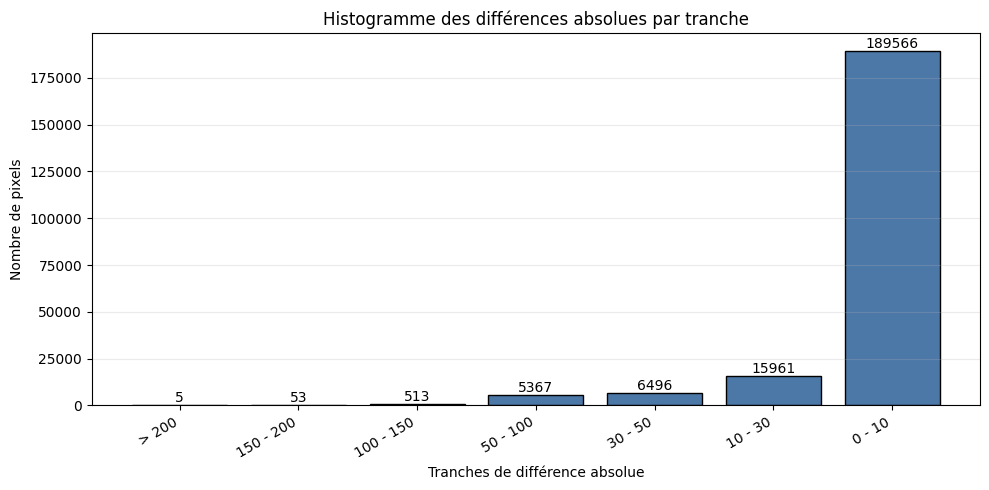

In [28]:
range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

range_counts = [
    num_gt_200,
    num_150_200,
    num_100_150,
    num_50_100,
    num_30_50,
    num_10_30,
    num_0_10,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
plt.title("Histogramme des différences absolues par tranche")
plt.xlabel("Tranches de différence absolue")
plt.ylabel("Nombre de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, range_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


### Squared photometric error map

Cette figure n ajoute pas une nouvelle metrique.
Elle sert seulement a voir **ou** l erreur photometrique se concentre dans l image.


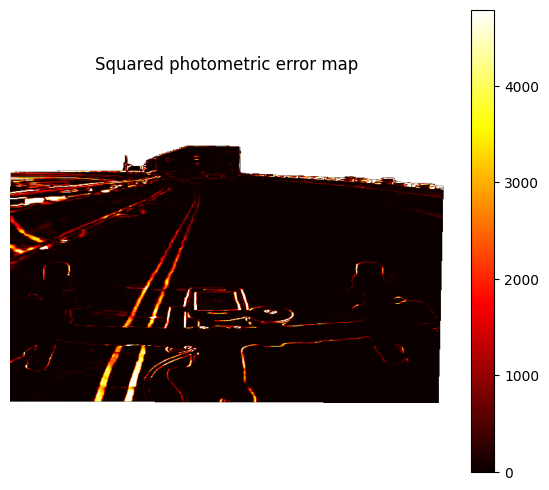

In [29]:
squared_error_map = evaluation["squared_error_map"]
valid_mask = evaluation["valid_mask"]

valid_values = squared_error_map[valid_mask]
vmax_sq = float(np.nanpercentile(valid_values, 99)) if valid_values.size > 0 else 1.0

plt.figure(figsize=(7, 6))
plt.imshow(squared_error_map, cmap="hot", vmin=0, vmax=vmax_sq)
plt.title("Squared photometric error map")
plt.axis("off")
plt.colorbar()
plt.show()


In [30]:
print("Only evaluation metric used in this notebook:")
print("  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels")


Only evaluation metric used in this notebook:
  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels


------
### **Scale sur toutes les images**

In [31]:
print(fake_frame_paths[0])

C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\ai\fake_bike_frames_first150\frame_00000.png


Sequence fake_bike_first150:
  source size = 704 x 1280
  working size level-0 = 640 x 480
  fx level-0 = 4187.118891969153
  fy level-0 = 1727.1865429372758



[fake_bike_first150] frame 0 -> keyframe de reference: frame_00000.png


lvl:  4  initial error:  401.97686375321314


update too small, level converged! it:  5  error:  262.91408931152233  lambda:  28147497671065.6
lvl:  3  initial error:  216.56090617105926


 error improvement too small, level converged! it:  3  error:  209.27029433190526  lambda:  0.0
lvl:  2  initial error:  271.6464110957015


 error improvement too small, level converged! it:  7  error:  200.48769050405932  lambda:  0.0


[fake_bike_first150] frame 1 -> frame_00001.png | sum error = 48931676.00 | mean abs error = 5.8079 | valid pixels = 217961


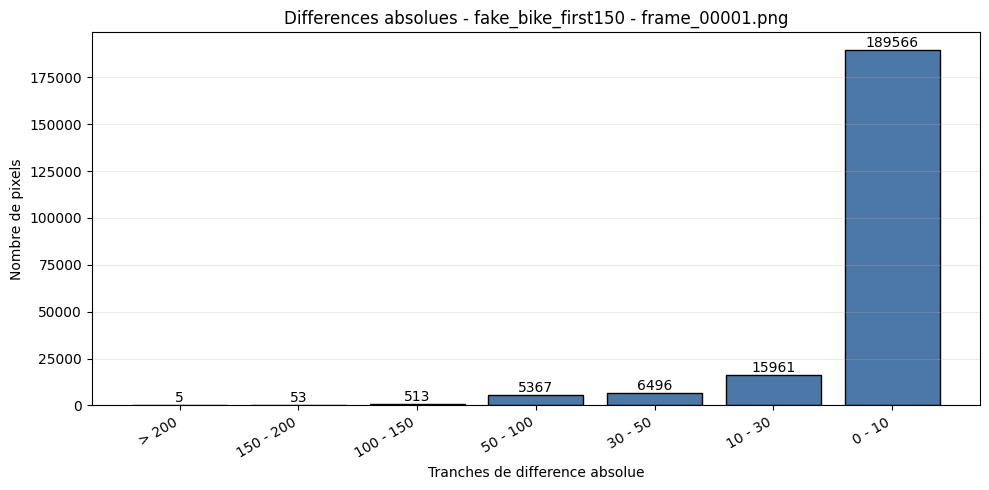

lvl:  4  initial error:  784.3200514138814
 error improvement too small, level converged! it:  3  error:  495.8159434359874  lambda:  0.1
lvl:  3  initial error:  425.465684592617


 error improvement too small, level converged! it:  3  error:  419.61920472928745  lambda:  0.8
lvl:  2  initial error:  446.6231218182375


update too small, level converged! it:  7  error:  384.66491189887415  lambda:  112589990684262.4


[fake_bike_first150] frame 2 -> frame_00002.png | sum error = 96915624.00 | mean abs error = 9.3962 | valid pixels = 214702


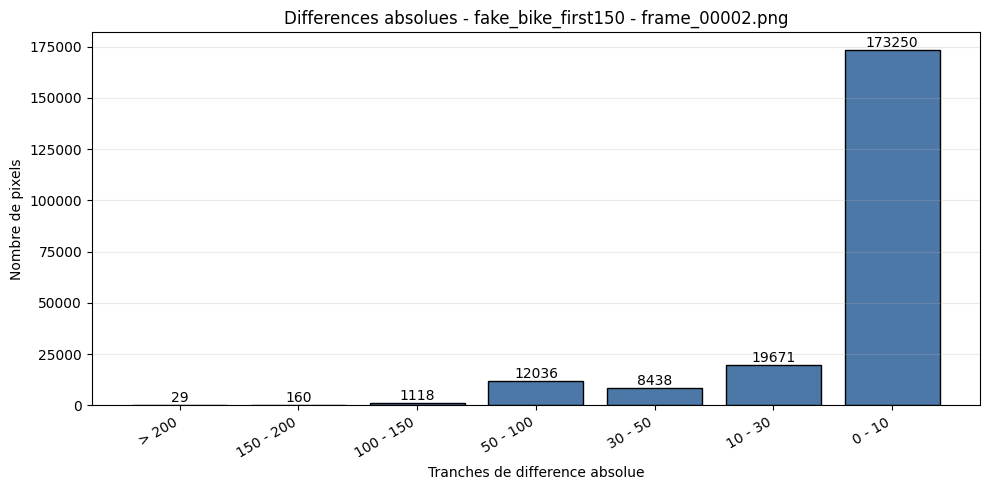

lvl:  4  initial error:  1066.3367609254494


 error improvement too small, level converged! it:  7  error:  671.7687071560863  lambda:  3.2
lvl:  3  initial error:  592.3959810550872


 error improvement too small, level converged! it:  8  error:  545.2394065405016  lambda:  0.1
lvl:  2  initial error:  622.0275604717436


update too small, level converged! it:  7  error:  572.3688265949351  lambda:  14073748835532.8


[fake_bike_first150] frame 3 -> frame_00003.png | sum error = 136097888.00 | mean abs error = 12.7806 | valid pixels = 209214


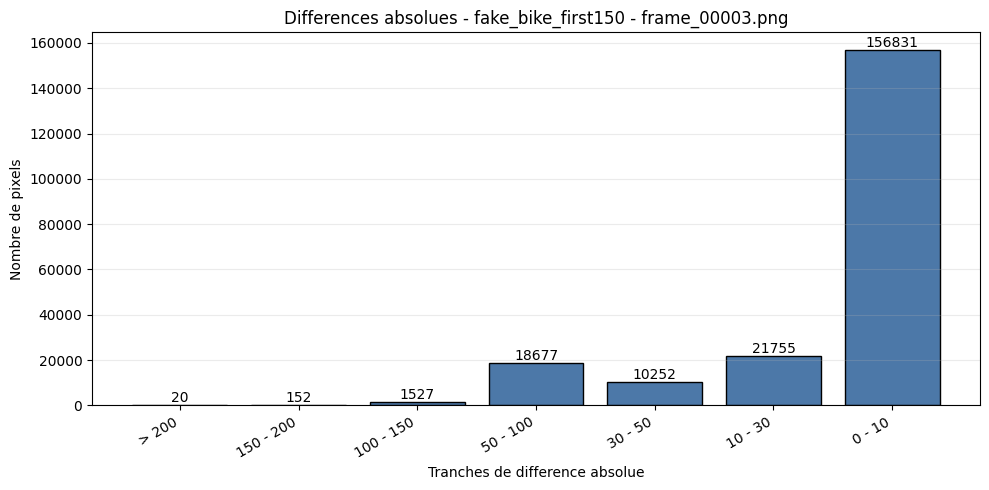

lvl:  4  initial error:  1354.7236503856038


 error improvement too small, level converged! it:  3  error:  787.6956842605094  lambda:  7036874417766.4
lvl:  3  initial error:  781.3873554815805


 error improvement too small, level converged! it:  2  error:  777.2565851419755  lambda:  14073748835532.8
lvl:  2  initial error:  814.6594915440928


 error improvement too small, level converged! it:  13  error:  741.8278118123411  lambda:  0.0


[fake_bike_first150] frame 4 -> frame_00004.png | sum error = 164853184.00 | mean abs error = 15.5926 | valid pixels = 202496


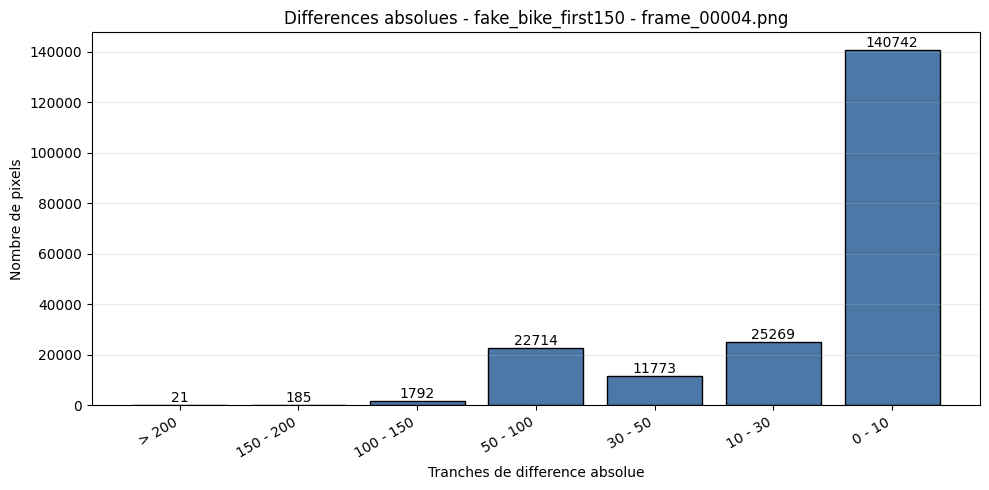

lvl:  4  initial error:  1611.786632390745


 error improvement too small, level converged! it:  5  error:  896.6652205445789  lambda:  0.0
lvl:  3  initial error:  874.986329377032


 error improvement too small, level converged! it:  3  error:  826.269445640879  lambda:  0.2
lvl:  2  initial error:  845.2416520450861


 error improvement too small, level converged! it:  5  error:  829.4205230953153  lambda:  0.0


[fake_bike_first150] frame 5 -> frame_00005.png | sum error = 179052992.00 | mean abs error = 17.2728 | valid pixels = 200443


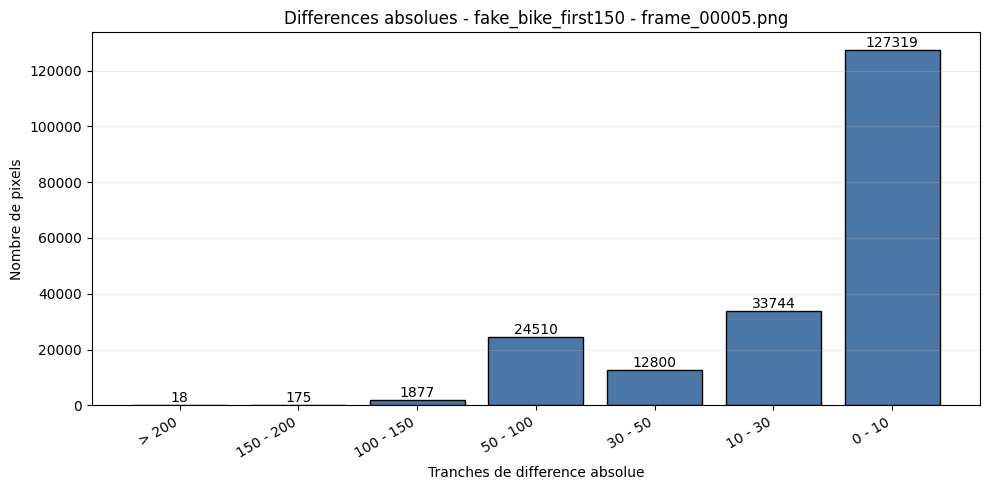

lvl:  4  initial error:  1735.9910025706936


 error improvement too small, level converged! it:  4  error:  894.8504973445818  lambda:  1.6
lvl:  3  initial error:  882.1497276509607


 error improvement too small, level converged! it:  3  error:  849.6094012847306  lambda:  109951162777.6
lvl:  2  initial error:  865.470842749449


 error improvement too small, level converged! it:  4  error:  843.995011472871  lambda:  0.1


[fake_bike_first150] frame 6 -> frame_00006.png | sum error = 181831648.00 | mean abs error = 17.9603 | valid pixels = 199377


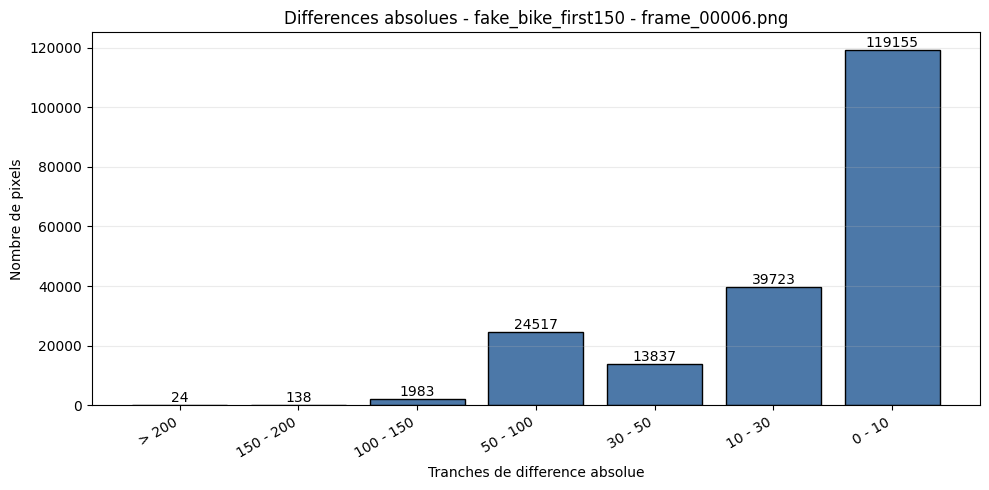

lvl:  4  initial error:  1810.6118251928017


 error improvement too small, level converged! it:  6  error:  889.8014735408783  lambda:  1759218604441.6
lvl:  3  initial error:  894.6338149402025


 error improvement too small, level converged! it:  5  error:  820.9289801315871  lambda:  0.0
lvl:  2  initial error:  899.3511389287793


 error improvement too small, level converged! it:  4  error:  833.5950640414546  lambda:  0.0


[fake_bike_first150] frame 7 -> frame_00007.png | sum error = 179169008.00 | mean abs error = 17.4725 | valid pixels = 202446


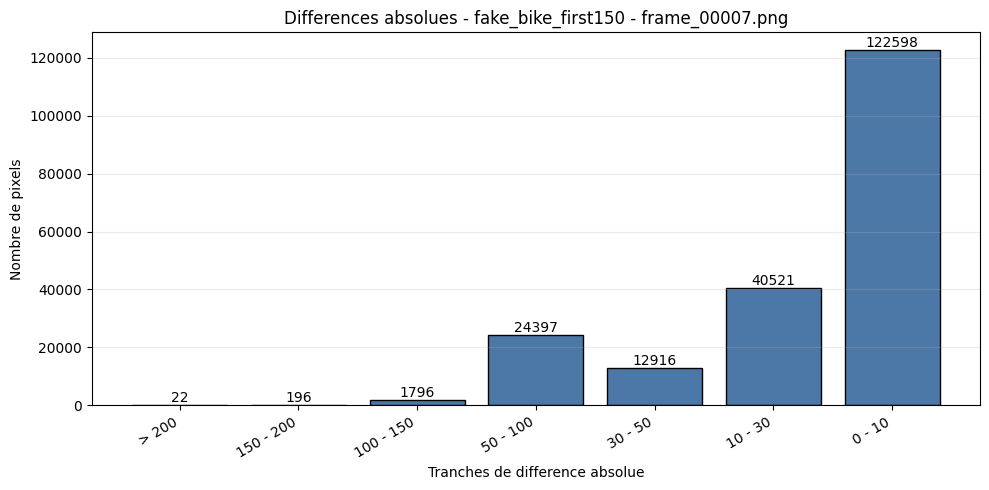

lvl:  4  initial error:  1784.4100257069404
 error improvement too small, level converged! it:  4  error:  896.3332675293277  lambda:  0.2


lvl:  3  initial error:  859.5499204840423


 error improvement too small, level converged! it:  5  error:  798.6127876124979  lambda:  27487790694.4
lvl:  2  initial error:  864.666006032866


 error improvement too small, level converged! it:  5  error:  807.1431481739894  lambda:  0.0


[fake_bike_first150] frame 8 -> frame_00008.png | sum error = 172599952.00 | mean abs error = 17.2365 | valid pixels = 203253


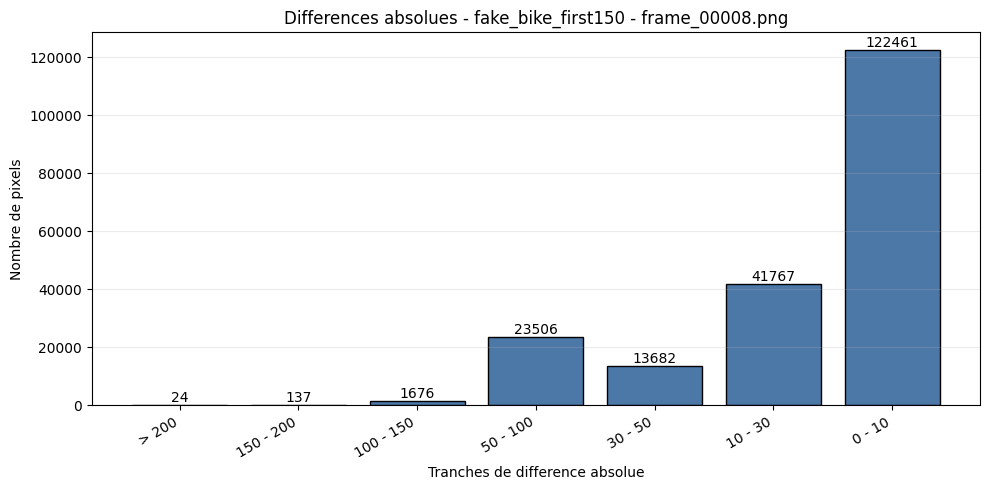

lvl:  4  initial error:  1745.7622107969144
 error improvement too small, level converged! it:  4  error:  873.550510960429  lambda:  0.8


lvl:  3  initial error:  793.5977484558655


 error improvement too small, level converged! it:  6  error:  744.3360474755997  lambda:  0.0
lvl:  2  initial error:  779.9823305610574


 error improvement too small, level converged! it:  6  error:  744.7838995016282  lambda:  0.0


[fake_bike_first150] frame 9 -> frame_00009.png | sum error = 162572288.00 | mean abs error = 16.1797 | valid pixels = 204813


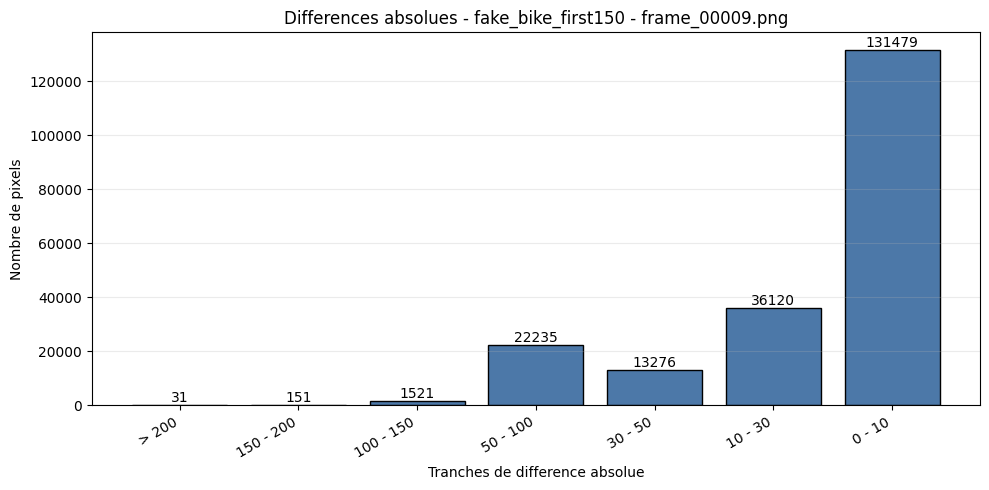

lvl:  4  initial error:  1600.5012853470428


 error improvement too small, level converged! it:  4  error:  822.4662175495995  lambda:  25.6
lvl:  3  initial error:  773.5192950531405


 error improvement too small, level converged! it:  5  error:  710.9494624593783  lambda:  6.4
lvl:  2  initial error:  717.6685641200548


 error improvement too small, level converged! it:  5  error:  692.9222131442162  lambda:  0.0


[fake_bike_first150] frame 10 -> frame_00010.png | sum error = 153240192.00 | mean abs error = 15.2782 | valid pixels = 206773


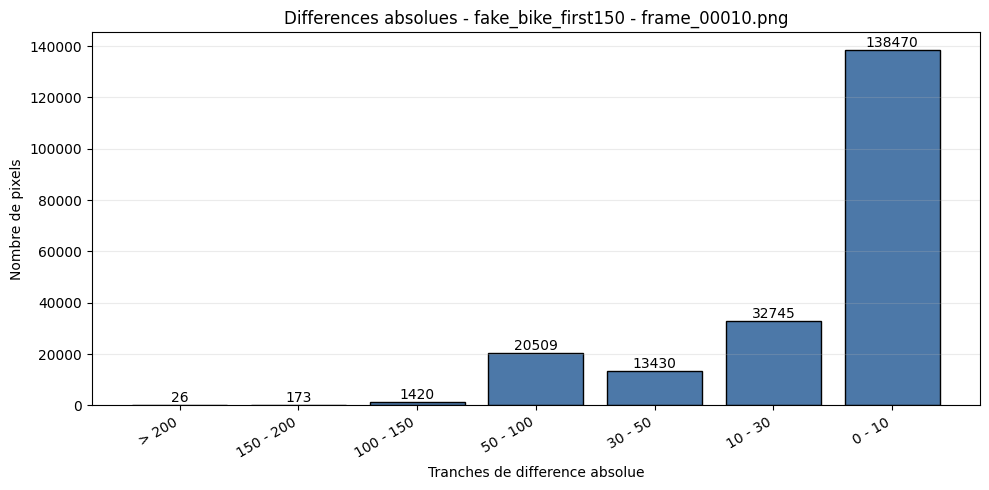

lvl:  4  initial error:  1565.019280205655


 error improvement too small, level converged! it:  7  error:  826.9880671557518  lambda:  1.6
lvl:  3  initial error:  774.2897949078402


update too small, level converged! it:  3  error:  684.1856216023122  lambda:  450359962737049.6
lvl:  2  initial error:  655.2656052439013


 error improvement too small, level converged! it:  8  error:  611.9795803757462  lambda:  0.0


[fake_bike_first150] frame 11 -> frame_00011.png | sum error = 141372128.00 | mean abs error = 14.4641 | valid pixels = 207905


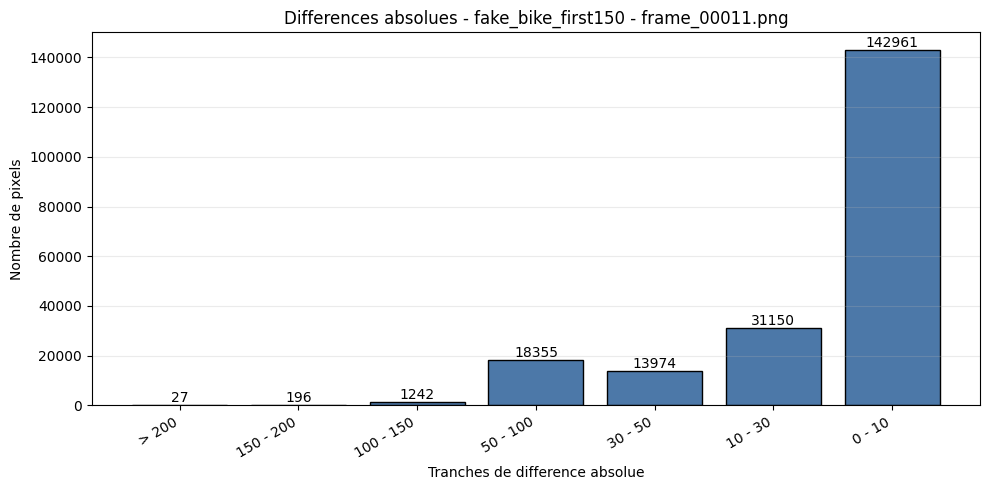

lvl:  4  initial error:  1413.4961439588683


 error improvement too small, level converged! it:  6  error:  746.7891765351925  lambda:  6.4
lvl:  3  initial error:  704.4689623847189


 error improvement too small, level converged! it:  3  error:  613.1398179127723  lambda:  25.6
lvl:  2  initial error:  596.8794330532844


update too small, level converged! it:  12  error:  539.0642012616051  lambda:  7036874417766.4


[fake_bike_first150] frame 12 -> frame_00012.png | sum error = 124020432.00 | mean abs error = 13.5307 | valid pixels = 207998


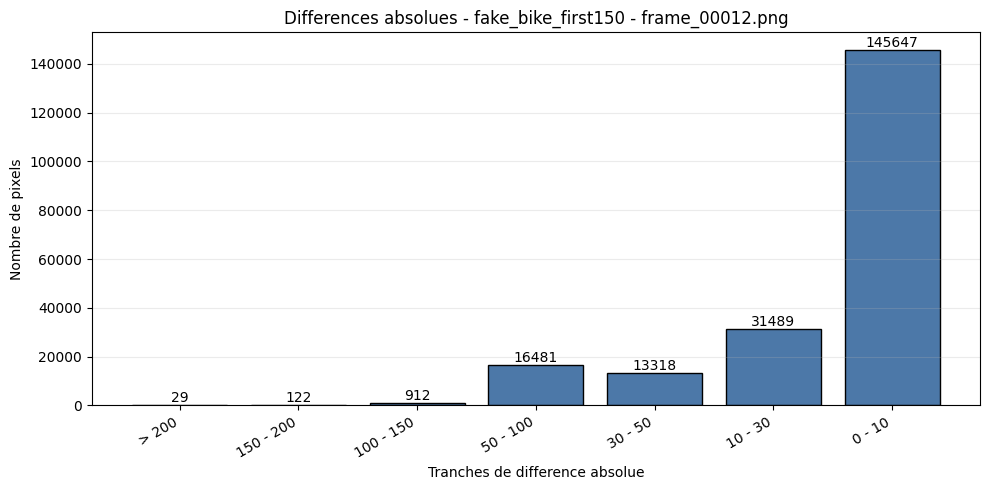

lvl:  4  initial error:  1299.4151670951148


 error improvement too small, level converged! it:  7  error:  761.8748582896476  lambda:  51.2
lvl:  3  initial error:  629.5995884240996


 error improvement too small, level converged! it:  7  error:  561.5548735087391  lambda:  0.1
lvl:  2  initial error:  586.6925536450808


 error improvement too small, level converged! it:  9  error:  550.3523413530271  lambda:  0.1


[fake_bike_first150] frame 13 -> frame_00013.png | sum error = 128716560.00 | mean abs error = 13.3013 | valid pixels = 210160


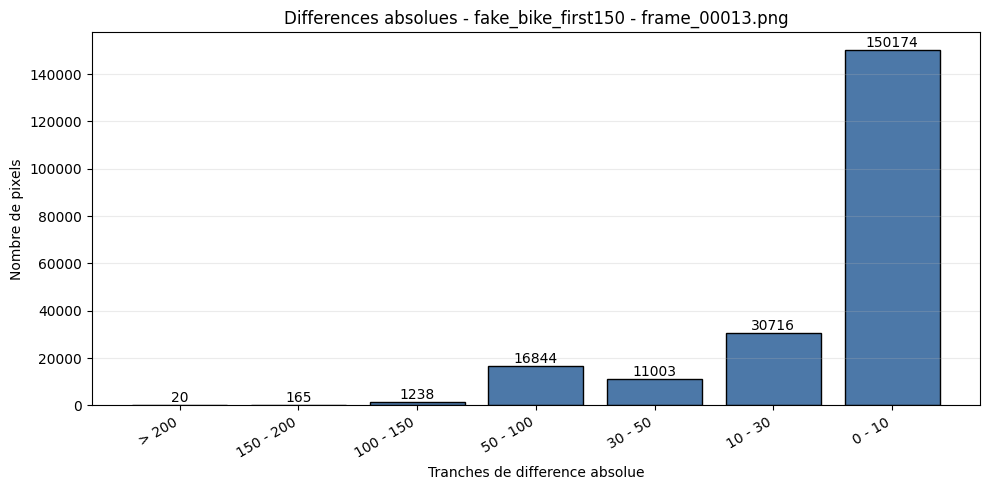

lvl:  4  initial error:  1330.1259640102821


update too small, level converged! it:  6  error:  725.6554213316854  lambda:  112589990684262.4
lvl:  3  initial error:  628.74430496821


 error improvement too small, level converged! it:  6  error:  550.44249404527  lambda:  0.2
lvl:  2  initial error:  557.8954820226841


 error improvement too small, level converged! it:  3  error:  548.8337017346902  lambda:  7036874417766.4


[fake_bike_first150] frame 14 -> frame_00014.png | sum error = 133203904.00 | mean abs error = 13.3465 | valid pixels = 208409


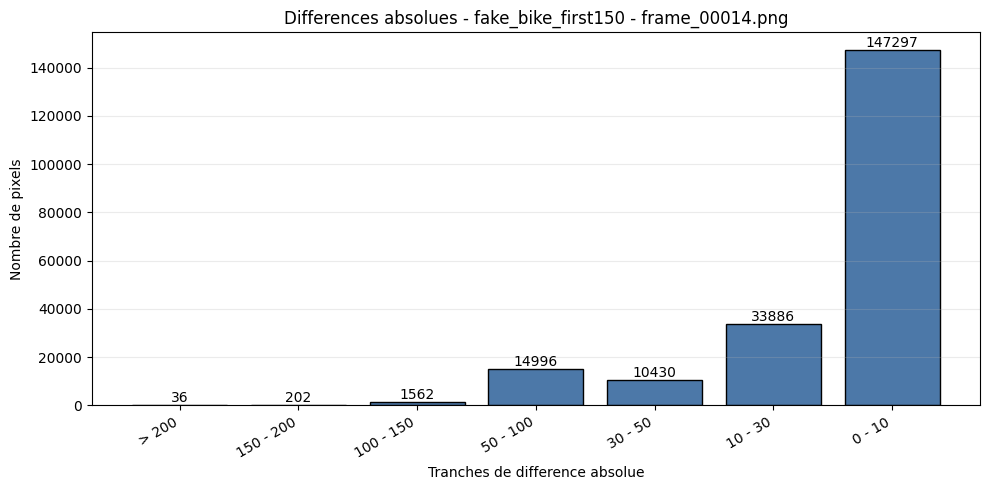

lvl:  4  initial error:  1468.069408740359


 error improvement too small, level converged! it:  5  error:  620.620879165547  lambda:  3.2
lvl:  3  initial error:  641.1739919364605


 error improvement too small, level converged! it:  2  error:  583.8886914775442  lambda:  12.8
lvl:  2  initial error:  626.7574338442652


 error improvement too small, level converged! it:  13  error:  584.4029856432111  lambda:  6.4


[fake_bike_first150] frame 15 -> frame_00015.png | sum error = 137883952.00 | mean abs error = 13.7013 | valid pixels = 207192


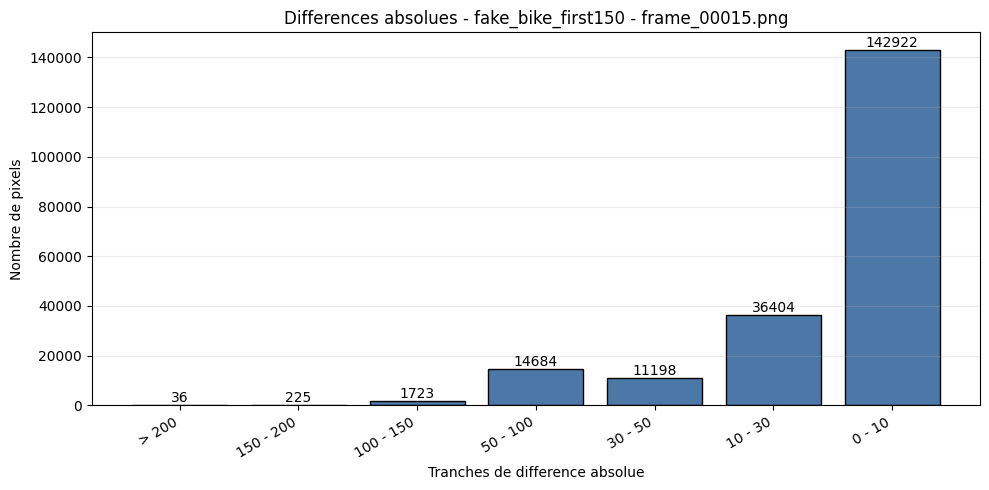

lvl:  4  initial error:  1584.087403598971


 error improvement too small, level converged! it:  6  error:  732.0537691309421  lambda:  6.4
lvl:  3  initial error:  684.4329828344074


 error improvement too small, level converged! it:  4  error:  621.8320012176683  lambda:  3.2
lvl:  2  initial error:  712.4103747826396


 error improvement too small, level converged! it:  8  error:  657.2933484028857  lambda:  439804651110.4


[fake_bike_first150] frame 16 -> frame_00016.png | sum error = 149928096.00 | mean abs error = 15.3451 | valid pixels = 210071


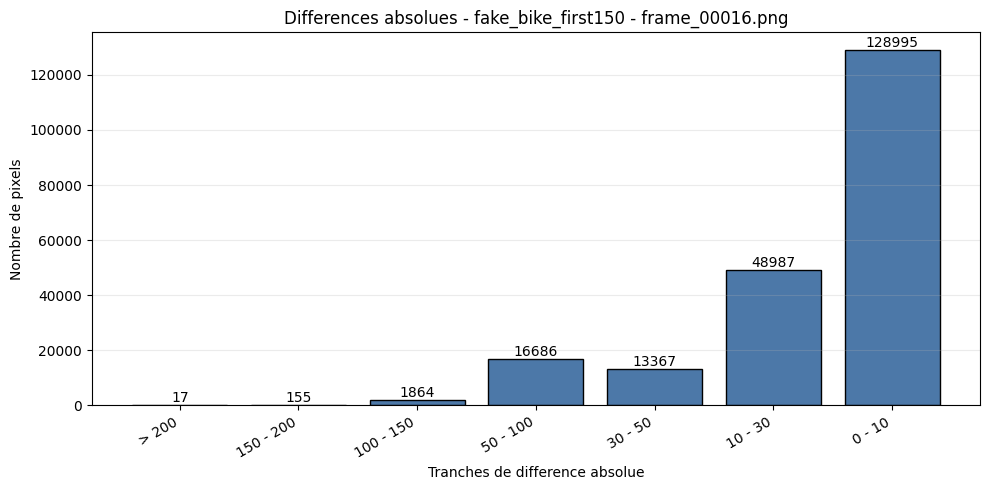

lvl:  4  initial error:  1443.6105398457578
 error improvement too small, level converged! it:  4  error:  681.9352454642475  lambda:  0.8


lvl:  3  initial error:  671.4619611059047


update too small, level converged! it:  4  error:  580.6248122249618  lambda:  450359962737049.6
lvl:  2  initial error:  648.4630409131532


 error improvement too small, level converged! it:  11  error:  579.0282910578725  lambda:  0.0


[fake_bike_first150] frame 17 -> frame_00017.png | sum error = 133584368.00 | mean abs error = 13.4340 | valid pixels = 209537


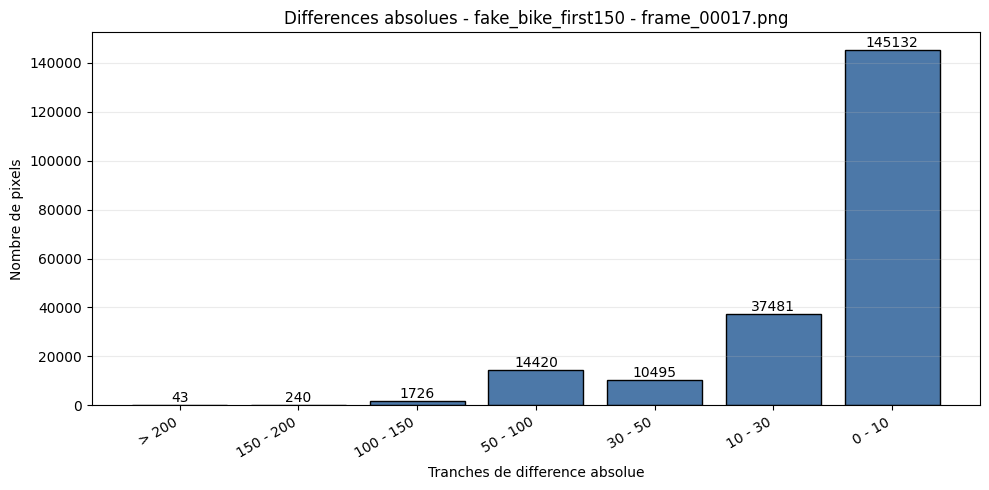

lvl:  4  initial error:  1480.7197943444723


 error improvement too small, level converged! it:  7  error:  655.1202987181025  lambda:  3.2
lvl:  3  initial error:  655.6312958312552


 error improvement too small, level converged! it:  3  error:  514.0279839554076  lambda:  0.4
lvl:  2  initial error:  579.1227960683387


 error improvement too small, level converged! it:  7  error:  544.3203849299658  lambda:  0.0


[fake_bike_first150] frame 18 -> frame_00018.png | sum error = 130240088.00 | mean abs error = 13.2135 | valid pixels = 209381


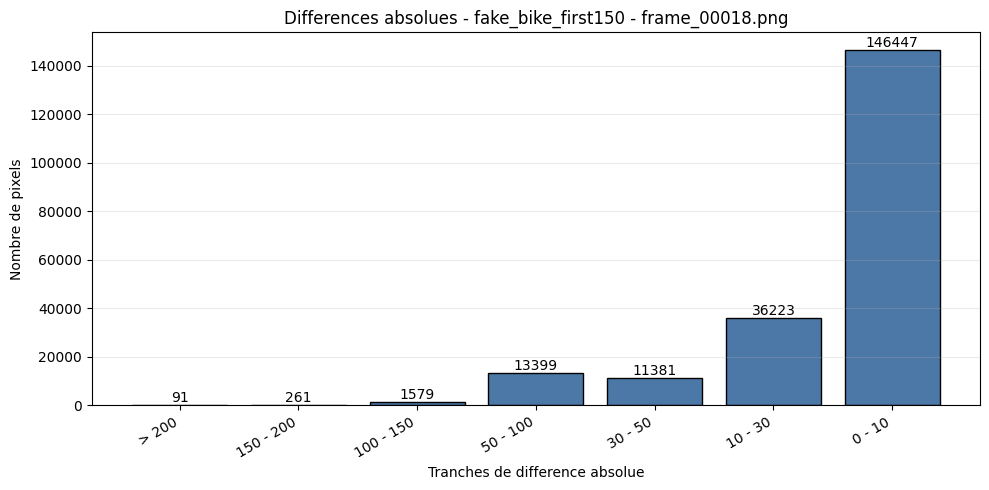

lvl:  4  initial error:  1588.9395886889454


 error improvement too small, level converged! it:  7  error:  636.4002204487267  lambda:  7036874417766.4
lvl:  3  initial error:  575.7125634708249


 error improvement too small, level converged! it:  4  error:  570.1851865938468  lambda:  0.2
lvl:  2  initial error:  571.5310931517189


 error improvement too small, level converged! it:  6  error:  515.1216332418836  lambda:  0.0


[fake_bike_first150] frame 19 -> frame_00019.png | sum error = 120365200.00 | mean abs error = 12.7508 | valid pixels = 208322


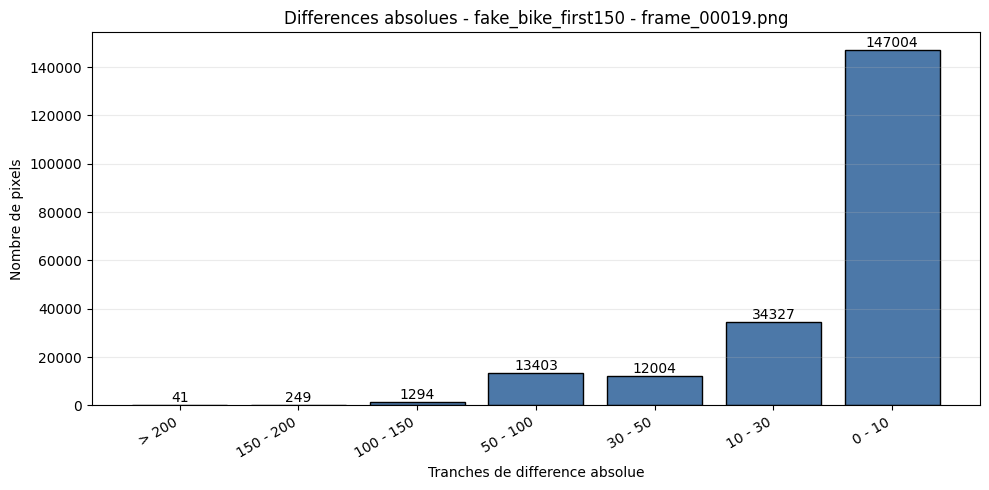

lvl:  4  initial error:  1807.1491002570683


 error improvement too small, level converged! it:  5  error:  678.3830507679228  lambda:  25.6
lvl:  3  initial error:  603.9368352827681


 error improvement too small, level converged! it:  2  error:  589.6764019608679  lambda:  0.0
lvl:  2  initial error:  568.7662747659323


 error improvement too small, level converged! it:  3  error:  552.8924903064344  lambda:  0.0


[fake_bike_first150] frame 20 -> frame_00020.png | sum error = 125071824.00 | mean abs error = 12.9598 | valid pixels = 204934


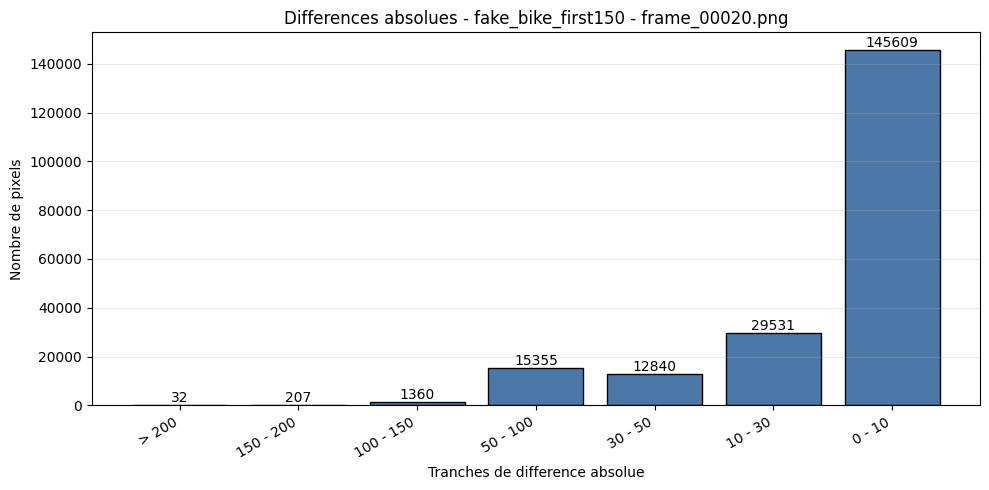

lvl:  4  initial error:  1997.6709511568117
 error improvement too small, level converged! it:  3  error:  718.2959166132525  lambda:  0.2


lvl:  3  initial error:  692.0187185419798


 error improvement too small, level converged! it:  8  error:  632.2388936015207  lambda:  204.8
lvl:  2  initial error:  651.0838988226969


 error improvement too small, level converged! it:  3  error:  640.6098464792844  lambda:  0.0


[fake_bike_first150] frame 21 -> frame_00021.png | sum error = 144745952.00 | mean abs error = 14.2962 | valid pixels = 205454


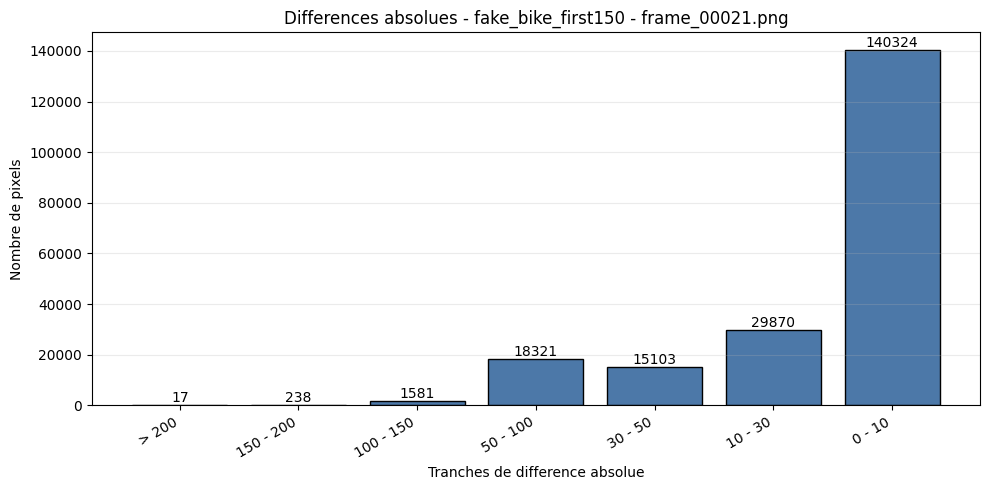

lvl:  4  initial error:  2088.817480719794


 error improvement too small, level converged! it:  8  error:  824.943324422551  lambda:  1.6
lvl:  3  initial error:  722.9638482835298


 error improvement too small, level converged! it:  7  error:  700.545341812231  lambda:  0.1
lvl:  2  initial error:  743.9152992220435


 error improvement too small, level converged! it:  5  error:  719.541313350875  lambda:  3.2


[fake_bike_first150] frame 22 -> frame_00022.png | sum error = 153977776.00 | mean abs error = 15.2723 | valid pixels = 204418


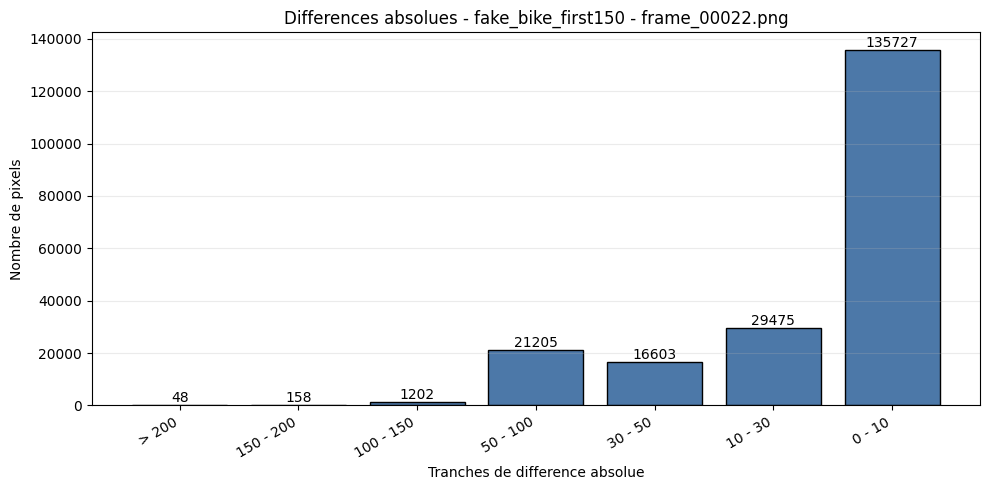

lvl:  4  initial error:  2059.4280205655514


 error improvement too small, level converged! it:  5  error:  856.8239958946768  lambda:  0.0
lvl:  3  initial error:  907.5236799247095


 error improvement too small, level converged! it:  6  error:  795.1194347620037  lambda:  7036874417766.4
lvl:  2  initial error:  806.778734045681


 error improvement too small, level converged! it:  8  error:  781.8928293836484  lambda:  0.0


[fake_bike_first150] frame 23 -> frame_00023.png | sum error = 171673664.00 | mean abs error = 16.4319 | valid pixels = 208831


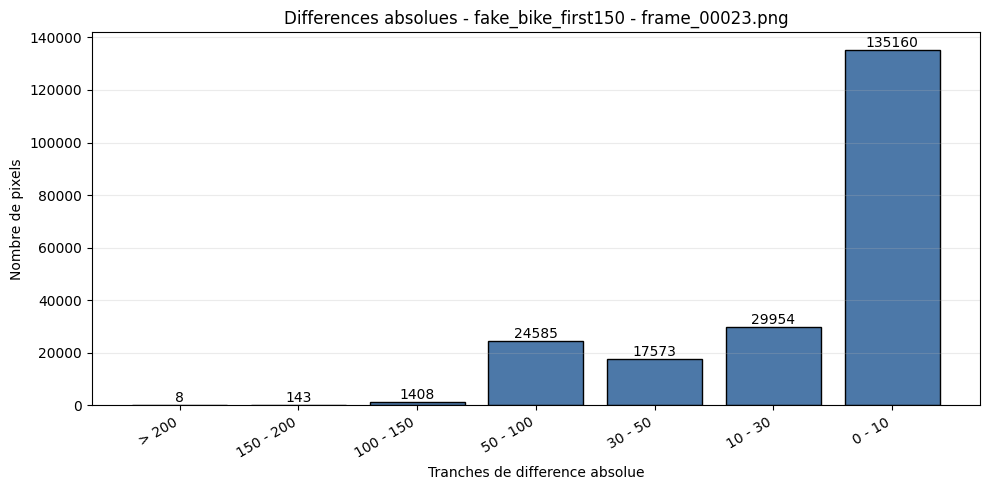

lvl:  4  initial error:  2225.3187660668373


 error improvement too small, level converged! it:  4  error:  959.390935755844  lambda:  3518437208883.2
lvl:  3  initial error:  843.646735282035


 error improvement too small, level converged! it:  5  error:  802.816159477896  lambda:  3518437208883.2
lvl:  2  initial error:  849.3475535979535


 error improvement too small, level converged! it:  3  error:  844.0386773989385  lambda:  0.0


[fake_bike_first150] frame 24 -> frame_00024.png | sum error = 186859760.00 | mean abs error = 17.4147 | valid pixels = 208917


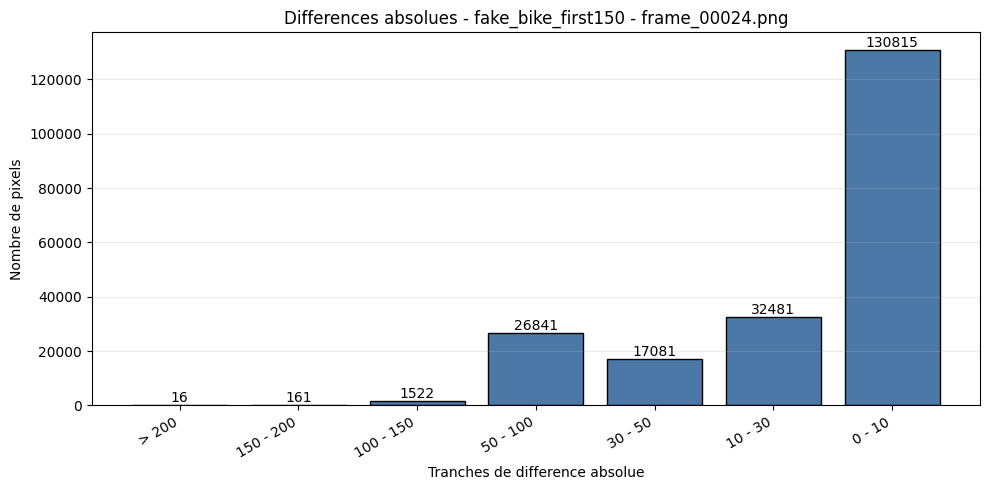

lvl:  4  initial error:  2325.2866323907447


 error improvement too small, level converged! it:  5  error:  976.9895590470759  lambda:  7036874417766.4
lvl:  3  initial error:  907.928379525021


 error improvement too small, level converged! it:  5  error:  878.1534570290866  lambda:  0.0
lvl:  2  initial error:  879.3243525142603


 error improvement too small, level converged! it:  4  error:  868.5218388037266  lambda:  0.0


[fake_bike_first150] frame 25 -> frame_00025.png | sum error = 193990048.00 | mean abs error = 17.9401 | valid pixels = 209164


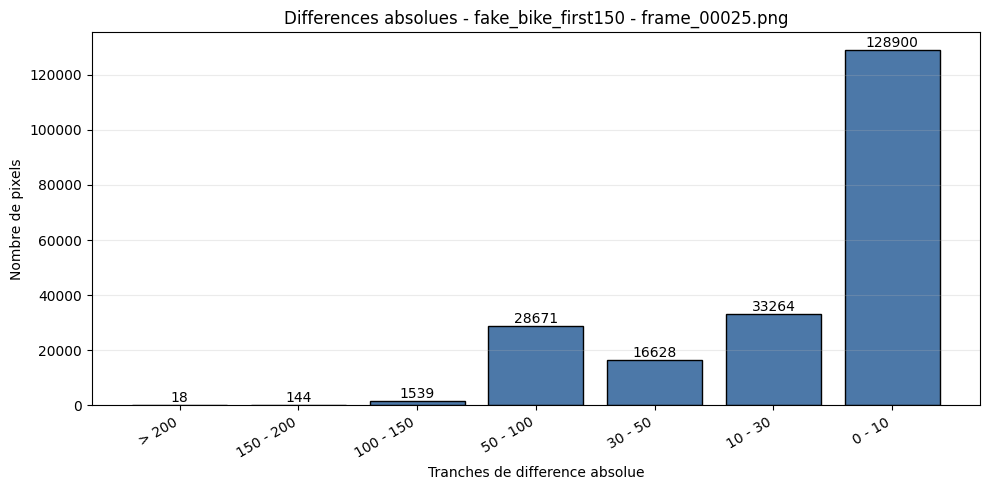

lvl:  4  initial error:  2411.2095115681227


 error improvement too small, level converged! it:  4  error:  977.2398191150951  lambda:  225179981368524.8
lvl:  3  initial error:  902.1351254619212


 error improvement too small, level converged! it:  6  error:  879.1192268324396  lambda:  0.0
lvl:  2  initial error:  899.2172865957345


 error improvement too small, level converged! it:  2  error:  893.6866996692303  lambda:  0.0


[fake_bike_first150] frame 26 -> frame_00026.png | sum error = 197812080.00 | mean abs error = 18.3546 | valid pixels = 208142


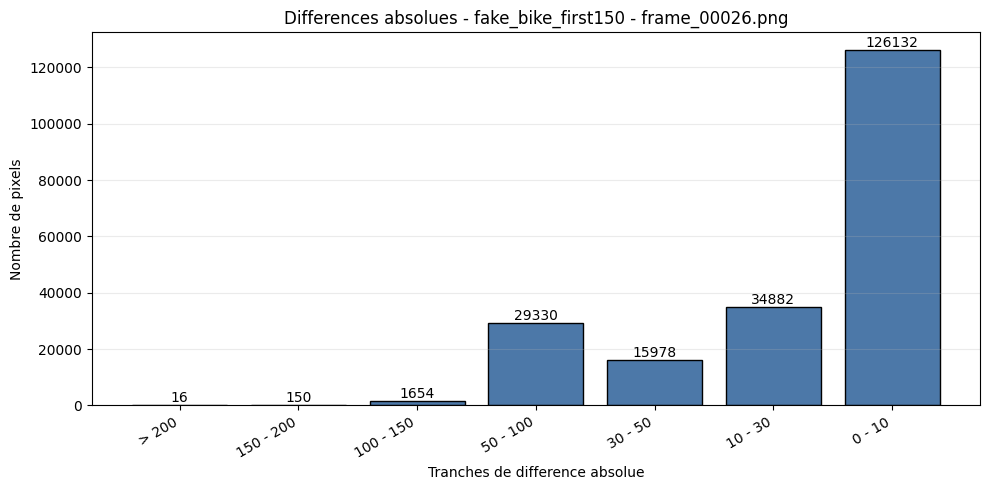

lvl:  4  initial error:  2308.357326478148


update too small, level converged! it:  5  error:  1002.3328747628634  lambda:  3602879701896397.0
lvl:  3  initial error:  962.2004854514424


 error improvement too small, level converged! it:  4  error:  866.7576769542384  lambda:  0.0
lvl:  2  initial error:  923.0996910207253


 error improvement too small, level converged! it:  3  error:  911.9357717891995  lambda:  6.4


[fake_bike_first150] frame 27 -> frame_00027.png | sum error = 197464256.00 | mean abs error = 18.2531 | valid pixels = 207636


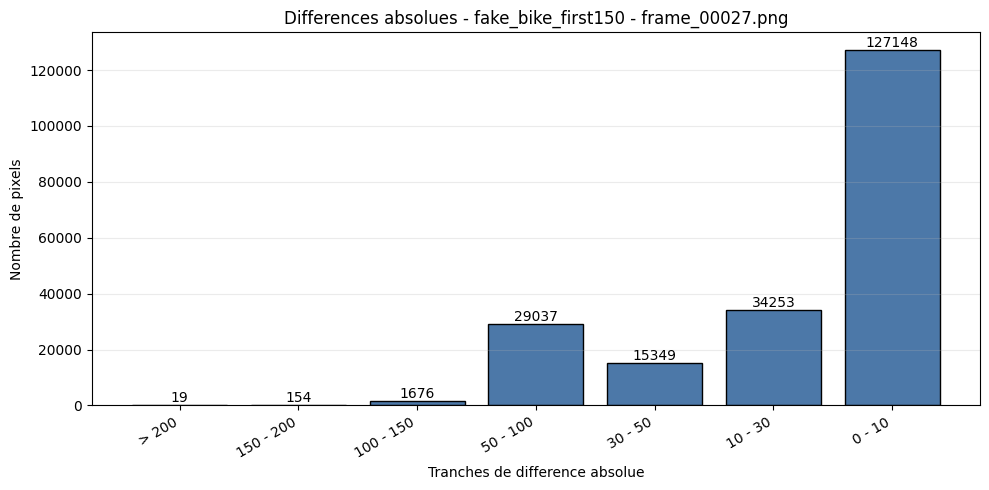

lvl:  4  initial error:  2167.638817480719


 error improvement too small, level converged! it:  4  error:  890.137244290192  lambda:  0.8
lvl:  3  initial error:  906.5684655804


 error improvement too small, level converged! it:  5  error:  834.7749347399904  lambda:  0.0
lvl:  2  initial error:  889.8936010469117


 error improvement too small, level converged! it:  3  error:  884.1631775984445  lambda:  0.0


[fake_bike_first150] frame 28 -> frame_00028.png | sum error = 193887136.00 | mean abs error = 18.0242 | valid pixels = 208206


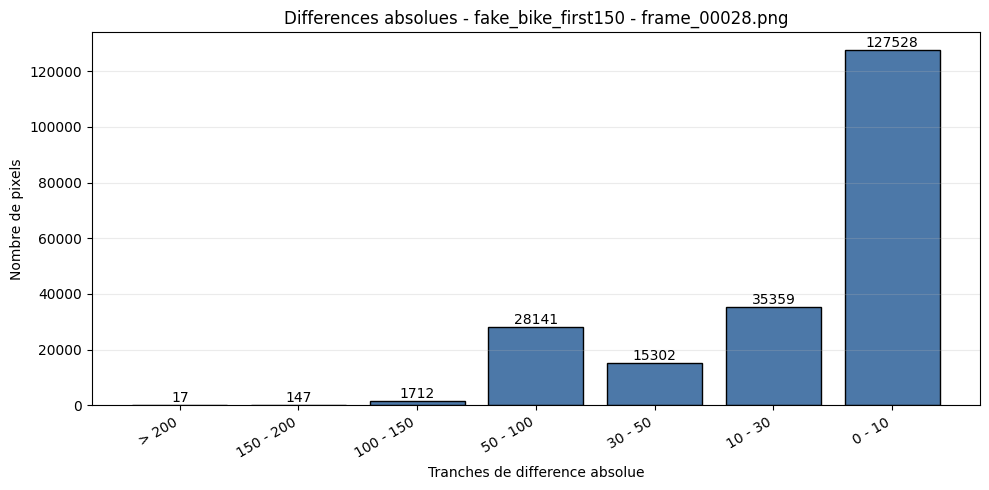

lvl:  4  initial error:  2092.3611825192797


 error improvement too small, level converged! it:  6  error:  881.7563735358053  lambda:  6.4
lvl:  3  initial error:  849.2815293287234


 error improvement too small, level converged! it:  4  error:  819.2371116911336  lambda:  12.8
lvl:  2  initial error:  835.703166746552


 error improvement too small, level converged! it:  6  error:  819.1585919572148  lambda:  0.0


[fake_bike_first150] frame 29 -> frame_00029.png | sum error = 180426912.00 | mean abs error = 17.0977 | valid pixels = 208489


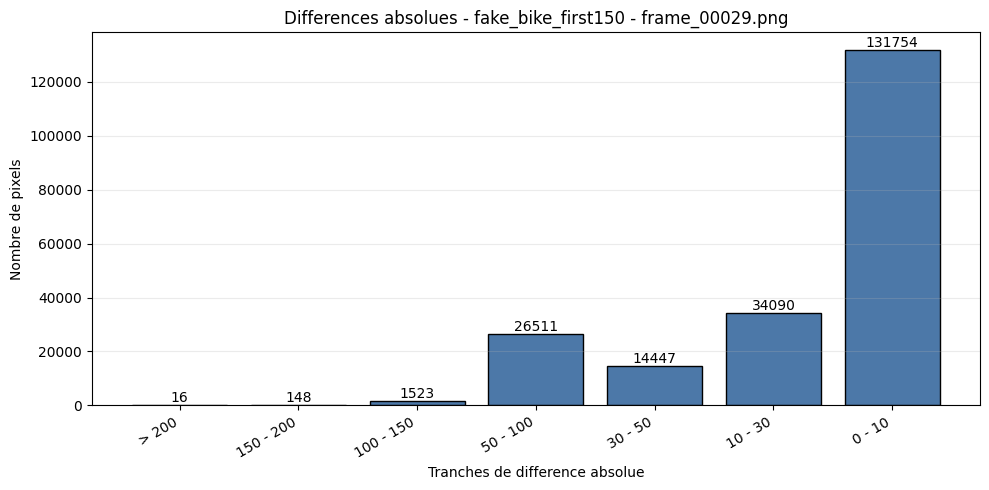

lvl:  4  initial error:  1953.4344473007707


update too small, level converged! it:  6  error:  789.4442377537039  lambda:  225179981368524.8
lvl:  3  initial error:  735.1699250207633


 error improvement too small, level converged! it:  2  error:  701.452406223455  lambda:  0.1


lvl:  2  initial error:  720.1067330178865


 error improvement too small, level converged! it:  3  error:  713.3526927413672  lambda:  0.0


[fake_bike_first150] frame 30 -> frame_00030.png | sum error = 161458352.00 | mean abs error = 15.6082 | valid pixels = 211042


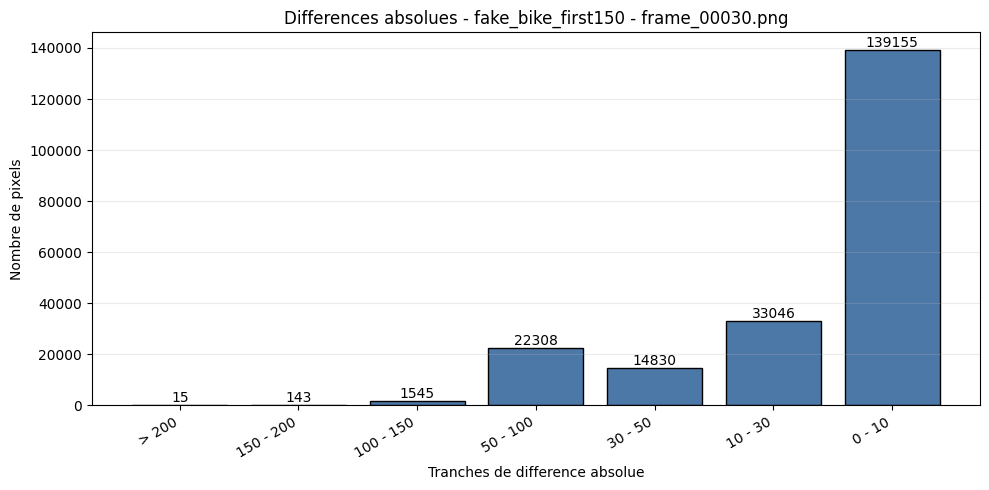

lvl:  4  initial error:  1737.356041131105


 error improvement too small, level converged! it:  7  error:  684.6994085835526  lambda:  0.8
lvl:  3  initial error:  584.5767966051196


 error improvement too small, level converged! it:  4  error:  542.7552788527196  lambda:  3.2
lvl:  2  initial error:  591.1880912068893


 error improvement too small, level converged! it:  5  error:  575.9396841607095  lambda:  0.0


[fake_bike_first150] frame 31 -> frame_00031.png | sum error = 128171128.00 | mean abs error = 12.9437 | valid pixels = 213931


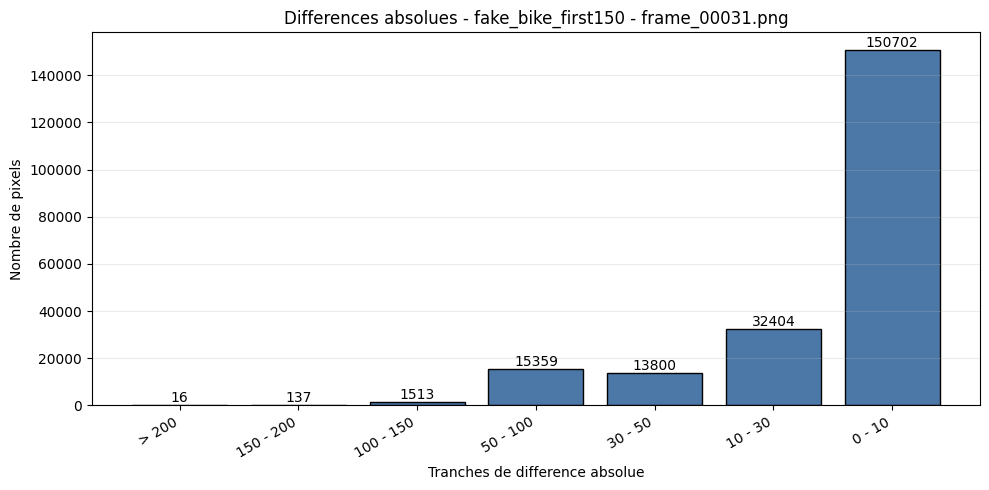

lvl:  4  initial error:  1490.0874035989714


 error improvement too small, level converged! it:  7  error:  624.662041375286  lambda:  3518437208883.2
lvl:  3  initial error:  537.8895984277154


 error improvement too small, level converged! it:  4  error:  470.6365858858735  lambda:  0.1
lvl:  2  initial error:  500.4353989150871


 error improvement too small, level converged! it:  3  error:  477.36325001530753  lambda:  0.0


[fake_bike_first150] frame 32 -> frame_00032.png | sum error = 111108600.00 | mean abs error = 11.5097 | valid pixels = 217204


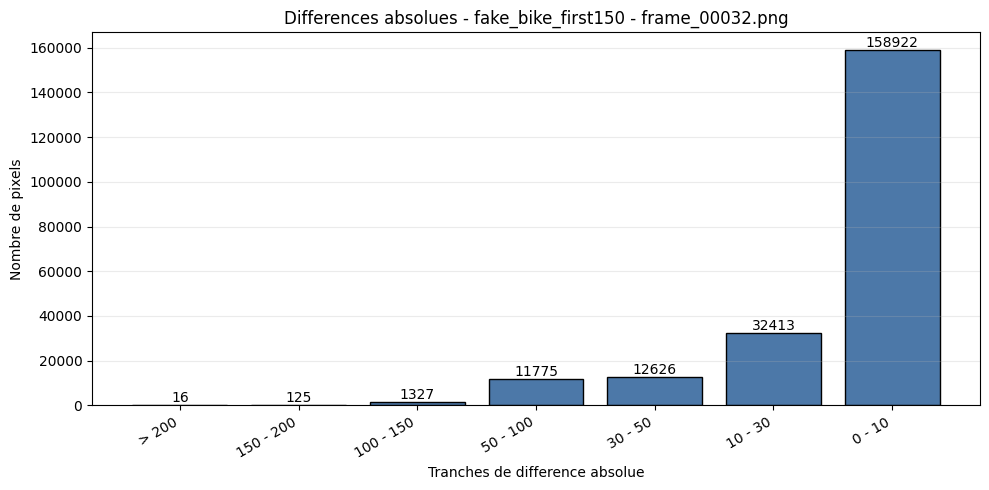

lvl:  4  initial error:  1259.7005141388167


 error improvement too small, level converged! it:  6  error:  570.1064658336944  lambda:  0.1
lvl:  3  initial error:  589.6018397316168


 error improvement too small, level converged! it:  8  error:  554.8243304500563  lambda:  0.0
lvl:  2  initial error:  565.6440613529752


 error improvement too small, level converged! it:  4  error:  554.1915843166987  lambda:  219902325555.2


[fake_bike_first150] frame 33 -> frame_00033.png | sum error = 132726296.00 | mean abs error = 12.9597 | valid pixels = 219569


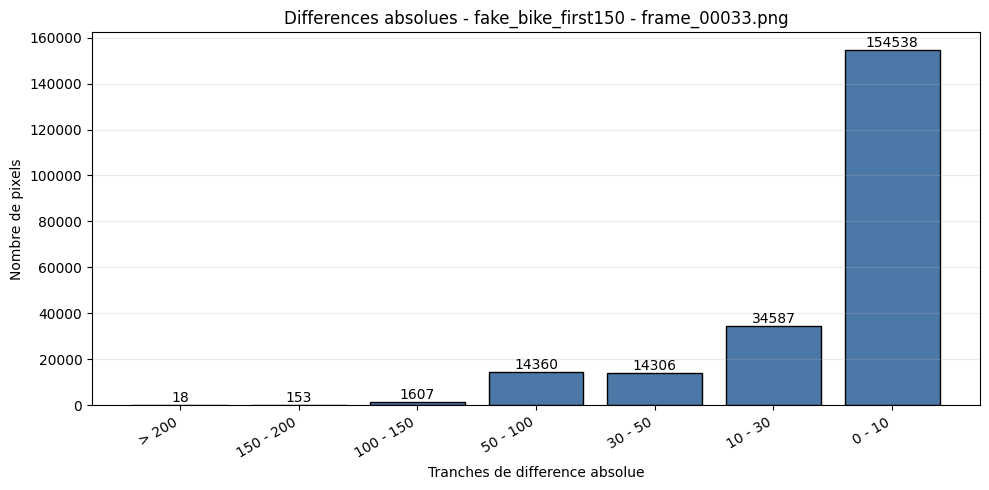

lvl:  4  initial error:  1283.8791773778917


 error improvement too small, level converged! it:  6  error:  673.8704636123473  lambda:  1.6
lvl:  3  initial error:  671.9977147039859


 error improvement too small, level converged! it:  7  error:  627.2189117046604  lambda:  0.0


lvl:  2  initial error:  701.2146646347829


 error improvement too small, level converged! it:  7  error:  669.3400395516742  lambda:  0.0


[fake_bike_first150] frame 34 -> frame_00034.png | sum error = 158472000.00 | mean abs error = 14.5619 | valid pixels = 220383


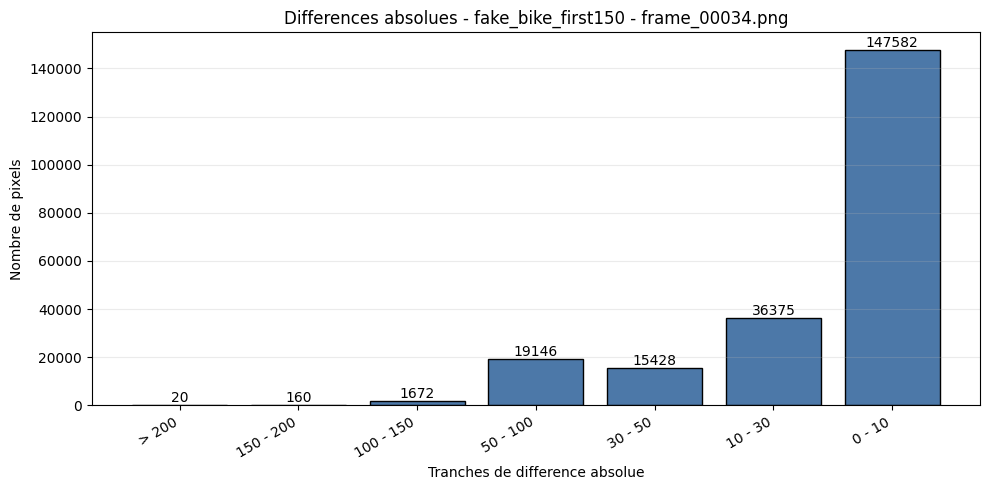

lvl:  4  initial error:  1328.924164524421


 error improvement too small, level converged! it:  4  error:  716.5147082535648  lambda:  0.0
lvl:  3  initial error:  723.6133399192876


update too small, level converged! it:  10  error:  675.8531940601436  lambda:  225179981368524.8


lvl:  2  initial error:  742.1491216368479


 error improvement too small, level converged! it:  10  error:  705.969488636871  lambda:  0.0


[fake_bike_first150] frame 35 -> frame_00035.png | sum error = 168985216.00 | mean abs error = 15.2931 | valid pixels = 220196


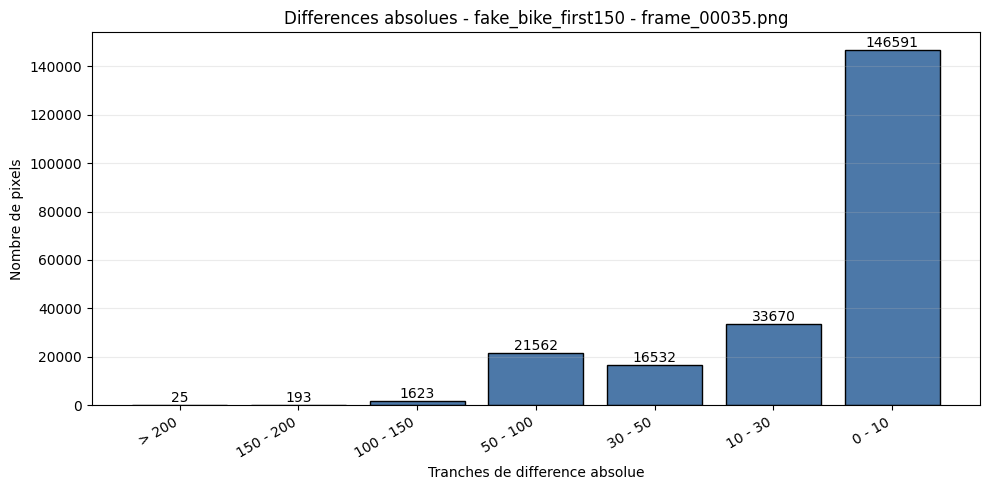

lvl:  4  initial error:  1356.773778920308


 error improvement too small, level converged! it:  3  error:  741.1116860276919  lambda:  439804651110.4
lvl:  3  initial error:  722.0533581453935


update too small, level converged! it:  2  error:  717.4576174614092  lambda:  56294995342131.2


lvl:  2  initial error:  749.1440297461781


 error improvement too small, level converged! it:  4  error:  728.432470059902  lambda:  0.0


[fake_bike_first150] frame 36 -> frame_00036.png | sum error = 175377152.00 | mean abs error = 15.5936 | valid pixels = 219854


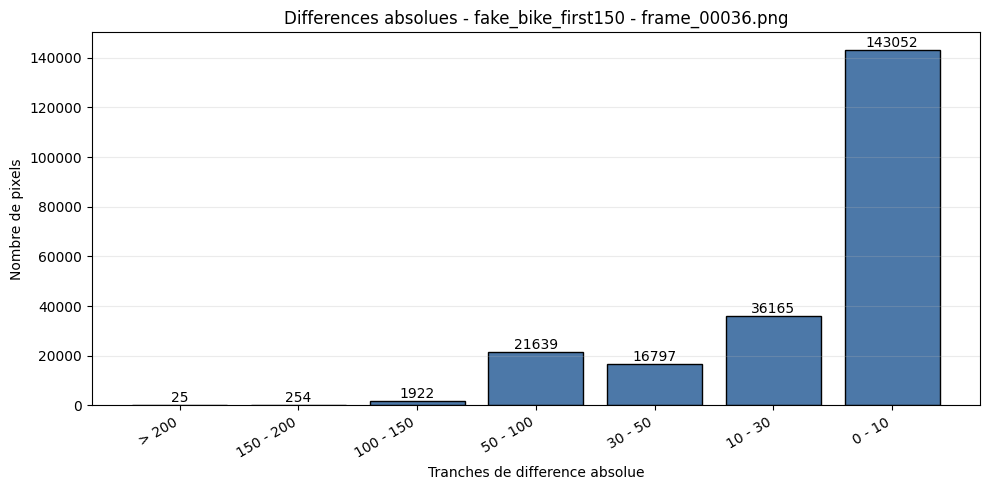

lvl:  4  initial error:  1372.6401028277633


 error improvement too small, level converged! it:  3  error:  737.5334868851986  lambda:  0.0
lvl:  3  initial error:  694.9092643569444


 error improvement too small, level converged! it:  6  error:  642.0527209772697  lambda:  0.0


lvl:  2  initial error:  725.5190356185436


 error improvement too small, level converged! it:  9  error:  706.0707557116422  lambda:  0.0


[fake_bike_first150] frame 37 -> frame_00037.png | sum error = 169338992.00 | mean abs error = 15.1749 | valid pixels = 218930


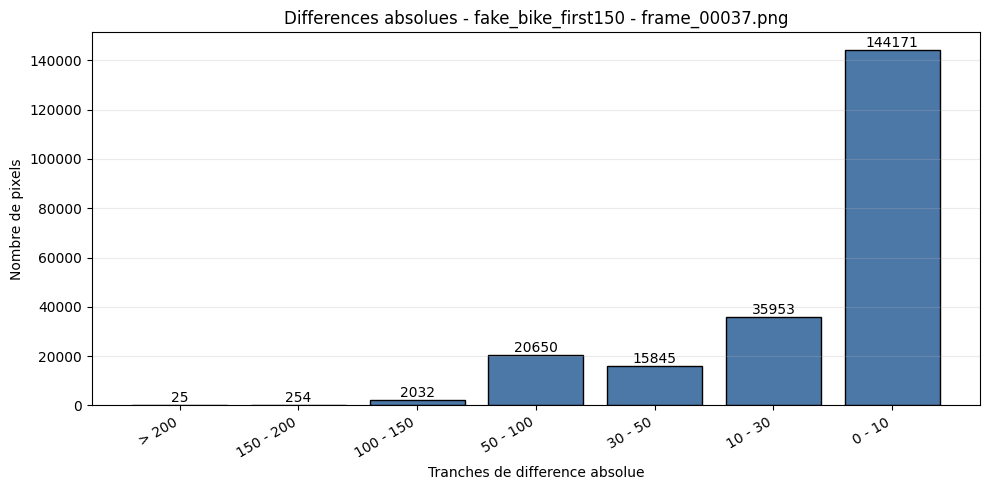

lvl:  4  initial error:  1517.260925449871


 error improvement too small, level converged! it:  4  error:  693.3711122239667  lambda:  0.1
lvl:  3  initial error:  676.9601025662615


 error improvement too small, level converged! it:  8  error:  625.6924994483895  lambda:  219902325555.2


lvl:  2  initial error:  655.5933283251808


 error improvement too small, level converged! it:  6  error:  638.2439744227189  lambda:  0.0


[fake_bike_first150] frame 38 -> frame_00038.png | sum error = 152120224.00 | mean abs error = 14.1213 | valid pixels = 217106


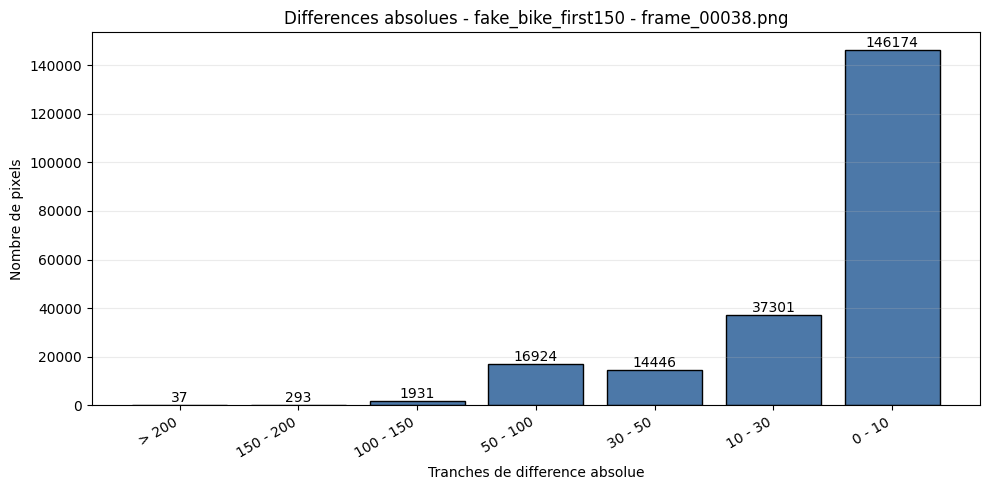

lvl:  4  initial error:  1788.2699228791769


 error improvement too small, level converged! it:  5  error:  607.5442660567447  lambda:  0.1
lvl:  3  initial error:  559.7186116487718


 error improvement too small, level converged! it:  3  error:  545.0926491257057  lambda:  0.0


lvl:  2  initial error:  572.2995689747061


 error improvement too small, level converged! it:  3  error:  553.8710330485831  lambda:  0.1


[fake_bike_first150] frame 39 -> frame_00039.png | sum error = 127056712.00 | mean abs error = 12.9463 | valid pixels = 213307


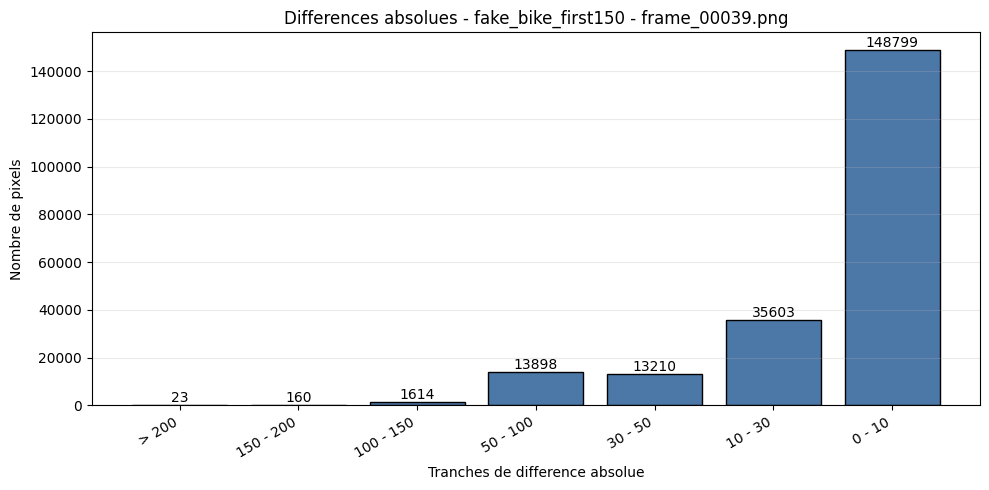

lvl:  4  initial error:  2020.3123393316193


 error improvement too small, level converged! it:  5  error:  579.2991920566426  lambda:  3518437208883.2
lvl:  3  initial error:  520.5694906187218


 error improvement too small, level converged! it:  4  error:  505.18865284571973  lambda:  0.4


lvl:  2  initial error:  496.89907608717806


 error improvement too small, level converged! it:  4  error:  480.9550951153414  lambda:  0.1


[fake_bike_first150] frame 40 -> frame_00040.png | sum error = 108088184.00 | mean abs error = 12.2084 | valid pixels = 210179


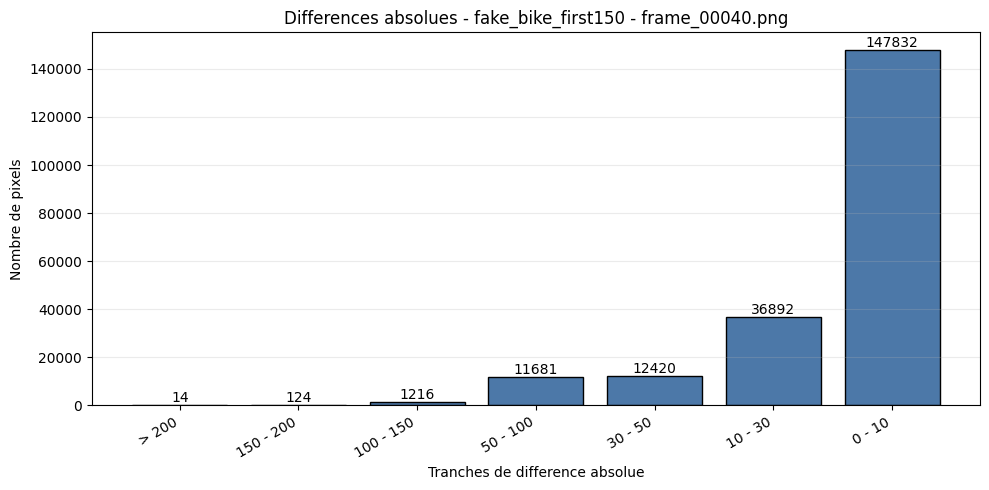

lvl:  4  initial error:  2251.0179948586115


 error improvement too small, level converged! it:  5  error:  651.3947082156651  lambda:  0.2
lvl:  3  initial error:  660.5256701099948


 error improvement too small, level converged! it:  5  error:  563.5204625716713  lambda:  0.1


lvl:  2  initial error:  549.7367658093148


 error improvement too small, level converged! it:  3  error:  540.0824536103271  lambda:  0.1


[fake_bike_first150] frame 41 -> frame_00041.png | sum error = 116181416.00 | mean abs error = 13.1763 | valid pixels = 207786


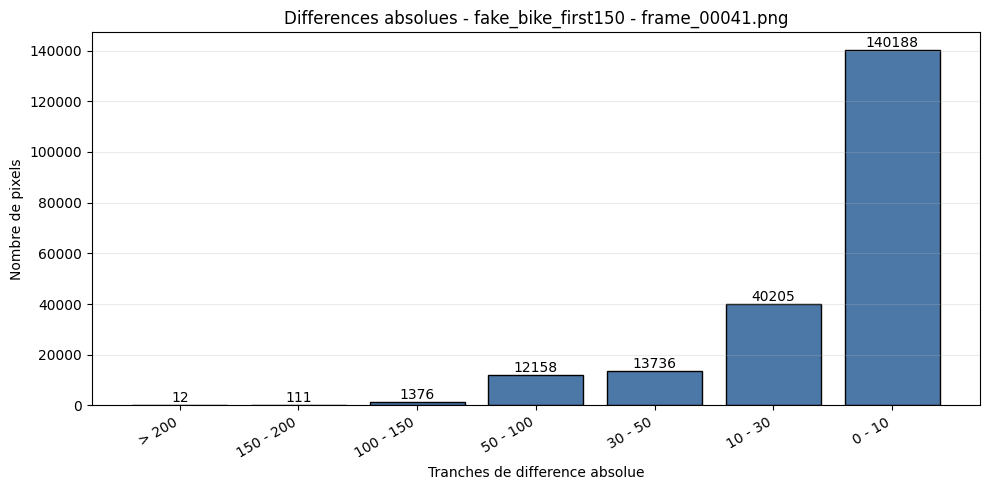

lvl:  4  initial error:  2409.9087403598965


 error improvement too small, level converged! it:  7  error:  812.0110835549858  lambda:  3.2
lvl:  3  initial error:  697.0786898482169


 error improvement too small, level converged! it:  3  error:  664.7214071401783  lambda:  0.0


lvl:  2  initial error:  688.0325773485258


 error improvement too small, level converged! it:  4  error:  669.2887410366825  lambda:  0.1


[fake_bike_first150] frame 42 -> frame_00042.png | sum error = 148084608.00 | mean abs error = 15.1431 | valid pixels = 208574


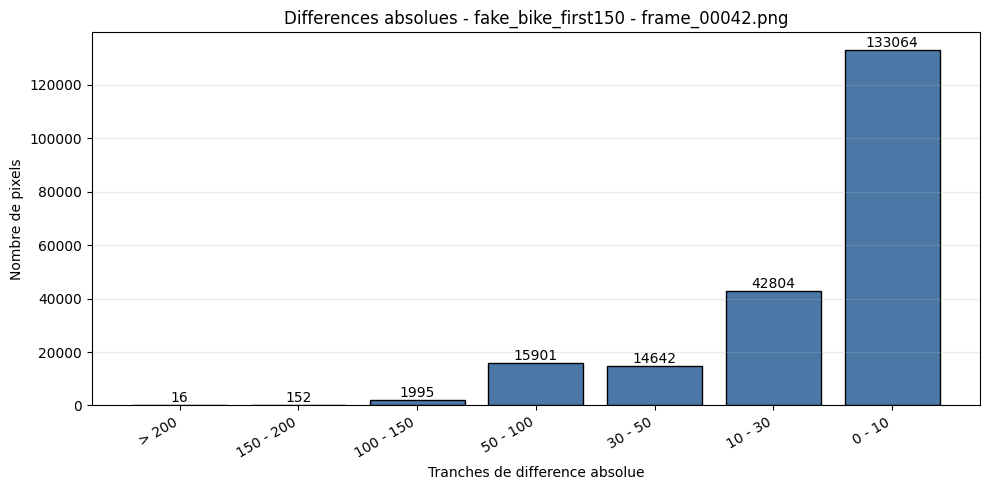

lvl:  4  initial error:  2429.628534704369


update too small, level converged! it:  6  error:  843.277357658577  lambda:  225179981368524.8
lvl:  3  initial error:  862.4716661945432


 error improvement too small, level converged! it:  4  error:  773.8761489792341  lambda:  0.2


lvl:  2  initial error:  788.1746490458306


 error improvement too small, level converged! it:  3  error:  777.5103176825081  lambda:  0.0


[fake_bike_first150] frame 43 -> frame_00043.png | sum error = 173499248.00 | mean abs error = 16.5884 | valid pixels = 208881


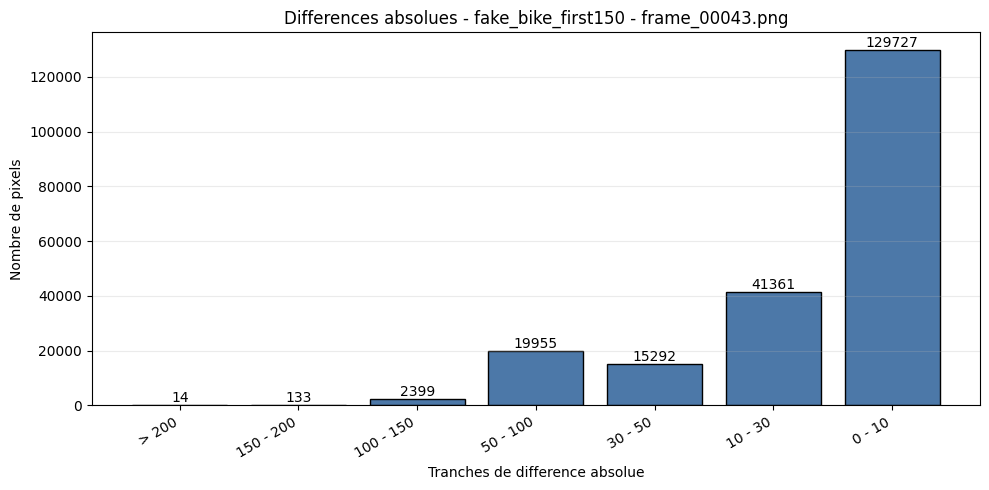

lvl:  4  initial error:  2447.7262210796907
 error improvement too small, level converged! it:  2  error:  936.6740185349537  lambda:  0.4
lvl:  3  initial error:  904.4345287709153


 error improvement too small, level converged! it:  3  error:  889.5290479245921  lambda:  0.2


lvl:  2  initial error:  880.1745090770696


 error improvement too small, level converged! it:  3  error:  874.9026163959861  lambda:  0.0


[fake_bike_first150] frame 44 -> frame_00044.png | sum error = 192559584.00 | mean abs error = 18.2621 | valid pixels = 208149


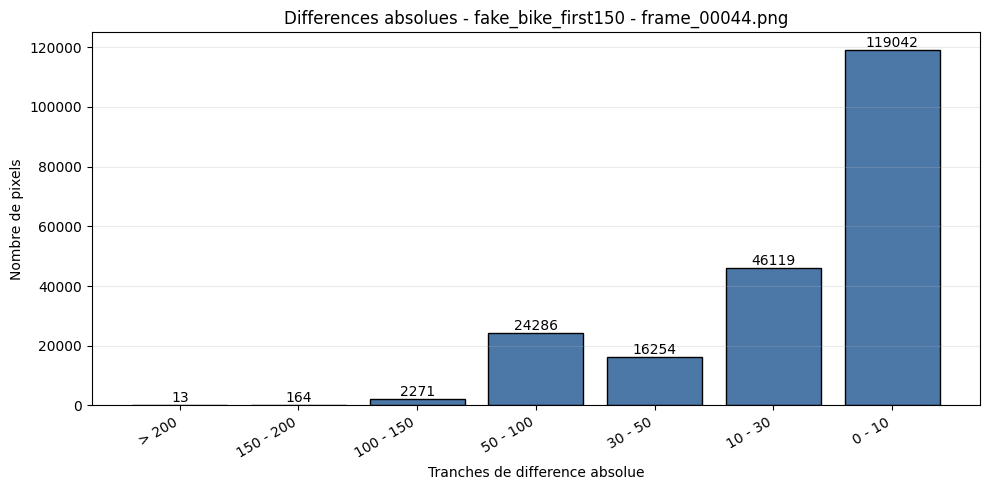

lvl:  4  initial error:  2571.394601542416


 error improvement too small, level converged! it:  4  error:  948.0019803163202  lambda:  6.4
lvl:  3  initial error:  942.8720290071938


 error improvement too small, level converged! it:  5  error:  903.9510900108634  lambda:  0.1


lvl:  2  initial error:  905.0157832989636


 error improvement too small, level converged! it:  2  error:  903.9243579394472  lambda:  0.2


[fake_bike_first150] frame 45 -> frame_00045.png | sum error = 197971200.00 | mean abs error = 18.9272 | valid pixels = 206725


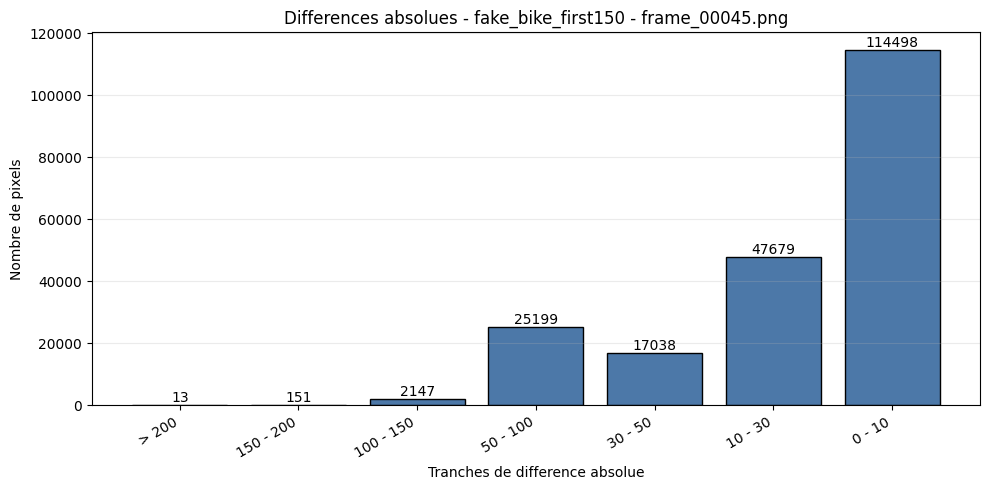

lvl:  4  initial error:  2738.9318766066826


 error improvement too small, level converged! it:  5  error:  925.8083893744839  lambda:  0.4
lvl:  3  initial error:  879.5463689440476


 error improvement too small, level converged! it:  2  error:  874.4935765066441  lambda:  0.0


lvl:  2  initial error:  895.7561392784677


 error improvement too small, level converged! it:  4  error:  889.5424471997325  lambda:  0.0


[fake_bike_first150] frame 46 -> frame_00046.png | sum error = 192324128.00 | mean abs error = 19.0790 | valid pixels = 204177


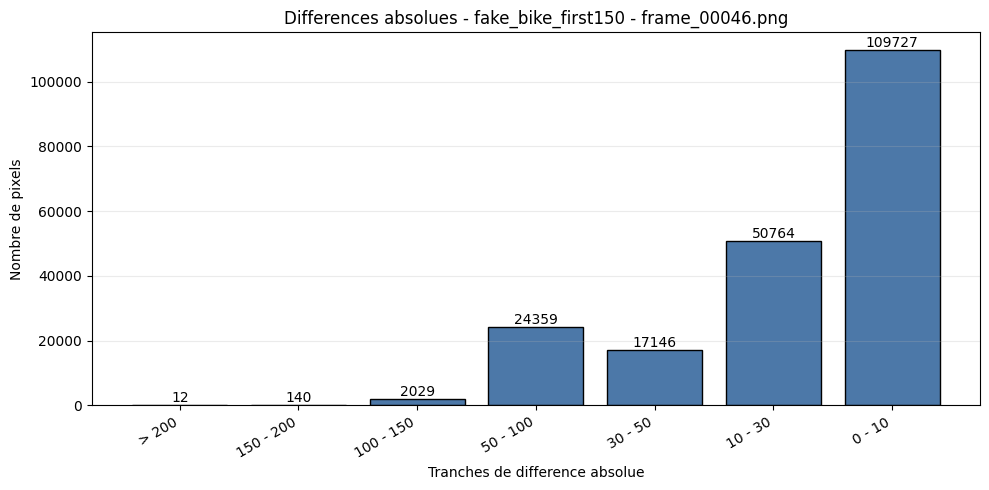

lvl:  4  initial error:  2780.561696658097


 error improvement too small, level converged! it:  5  error:  934.4149161188935  lambda:  0.1
lvl:  3  initial error:  918.1051532659179


 error improvement too small, level converged! it:  3  error:  874.3437748474395  lambda:  0.1


lvl:  2  initial error:  861.9018247202654


 error improvement too small, level converged! it:  3  error:  852.2831356227731  lambda:  0.1


[fake_bike_first150] frame 47 -> frame_00047.png | sum error = 181755824.00 | mean abs error = 18.6032 | valid pixels = 201682


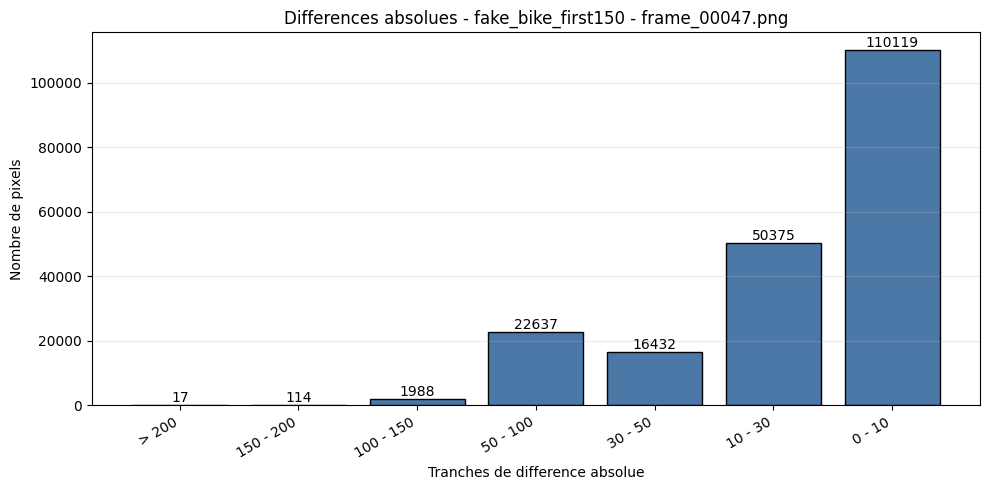

lvl:  4  initial error:  2788.7236503856034


 error improvement too small, level converged! it:  4  error:  756.2631238877254  lambda:  0.1
lvl:  3  initial error:  772.7358892245575


 error improvement too small, level converged! it:  5  error:  762.6609243630787  lambda:  0.1


lvl:  2  initial error:  787.7978270318303


 error improvement too small, level converged! it:  1  error:  787.7137291759848  lambda:  0.4


[fake_bike_first150] frame 48 -> frame_00048.png | sum error = 167287104.00 | mean abs error = 17.3965 | valid pixels = 201722


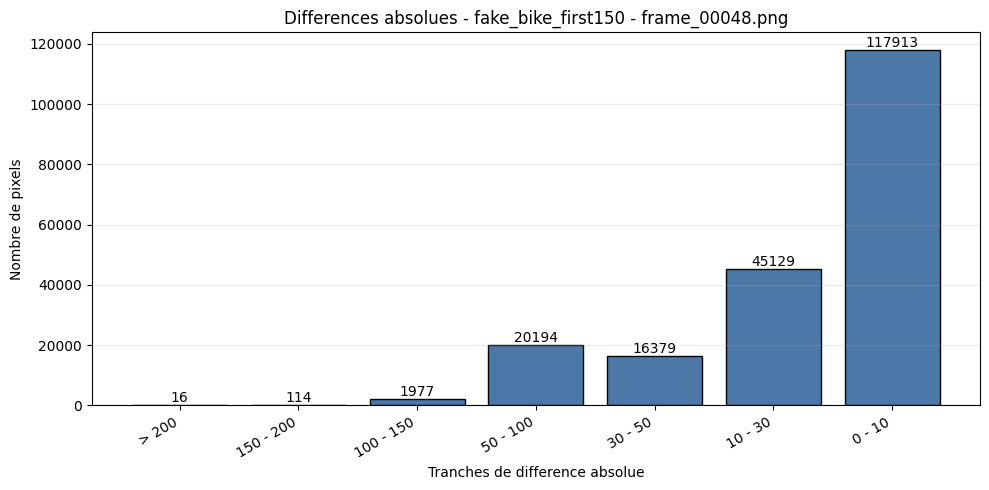

lvl:  4  initial error:  2673.1645244215933


 error improvement too small, level converged! it:  5  error:  719.9520477504908  lambda:  0.1
lvl:  3  initial error:  674.6990221861087


 error improvement too small, level converged! it:  4  error:  660.1124934658928  lambda:  7036874417766.4


lvl:  2  initial error:  662.312921742088


 error improvement too small, level converged! it:  4  error:  649.6025045849638  lambda:  0.0


[fake_bike_first150] frame 49 -> frame_00049.png | sum error = 139795872.00 | mean abs error = 15.4715 | valid pixels = 202202


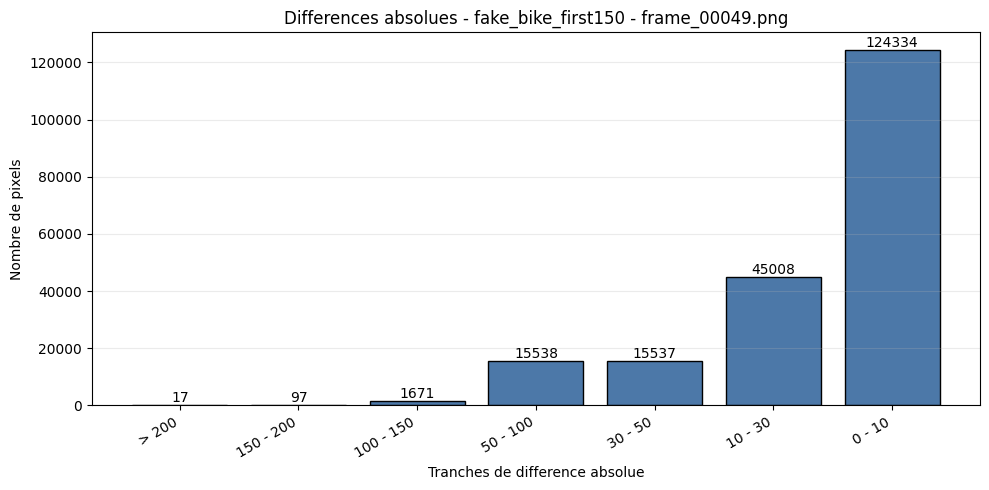

lvl:  4  initial error:  2587.2082262210793


update too small, level converged! it:  7  error:  655.2639443132565  lambda:  1801439850948198.5
lvl:  3  initial error:  604.2647856254358


 error improvement too small, level converged! it:  2  error:  585.8043086906249  lambda:  0.8


lvl:  2  initial error:  563.9683207571336


 error improvement too small, level converged! it:  2  error:  551.9815695470702  lambda:  0.8


[fake_bike_first150] frame 50 -> frame_00050.png | sum error = 118861952.00 | mean abs error = 13.9788 | valid pixels = 204728


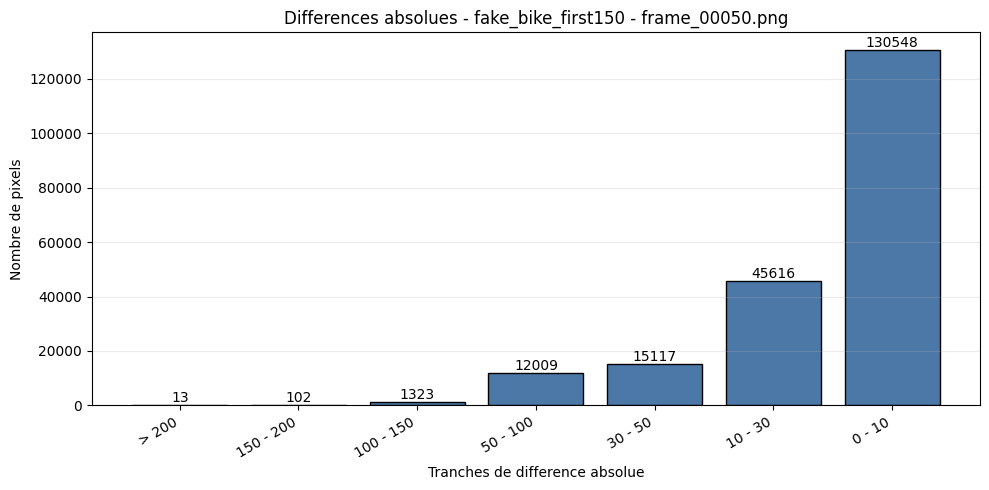

lvl:  4  initial error:  2515.0694087403594


 error improvement too small, level converged! it:  6  error:  624.6404987459284  lambda:  0.2
lvl:  3  initial error:  570.2063688206229


 error improvement too small, level converged! it:  2  error:  556.2357342088391  lambda:  3.2


lvl:  2  initial error:  530.6859223386698


 error improvement too small, level converged! it:  6  error:  512.8104720899581  lambda:  0.0


[fake_bike_first150] frame 51 -> frame_00051.png | sum error = 109467888.00 | mean abs error = 12.9316 | valid pixels = 207651


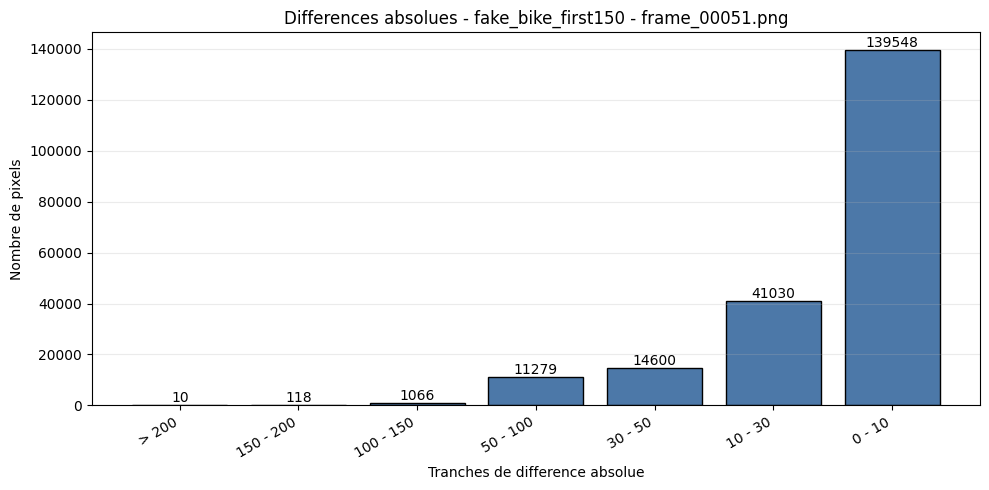

lvl:  4  initial error:  2430.484575835475


 error improvement too small, level converged! it:  6  error:  656.284836254877  lambda:  0.2
lvl:  3  initial error:  636.3475343330613


update too small, level converged! it:  5  error:  581.2740762050196  lambda:  28147497671065.6
lvl:  2  initial error:  574.8703688088937


 error improvement too small, level converged! it:  9  error:  549.6660302335362  lambda:  109951162777.6


[fake_bike_first150] frame 52 -> frame_00052.png | sum error = 121000704.00 | mean abs error = 13.4850 | valid pixels = 210392


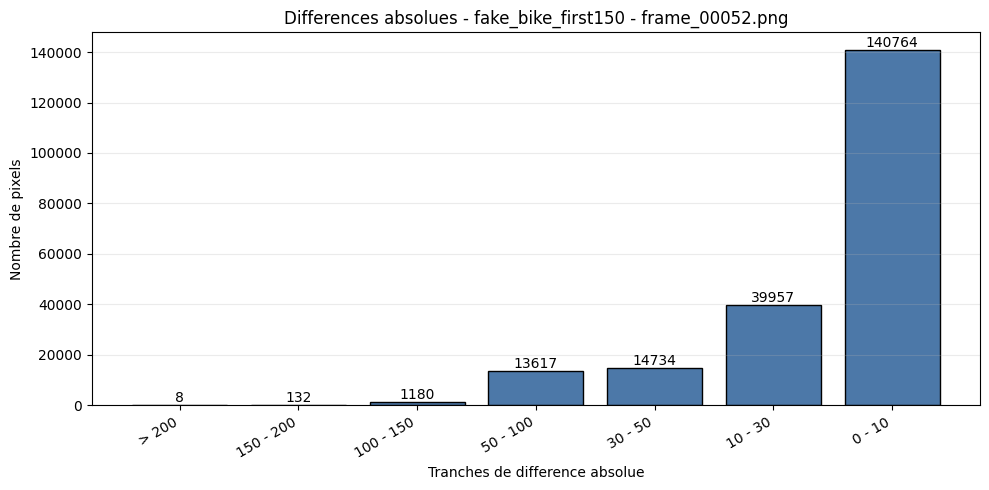

lvl:  4  initial error:  2394.740359897172


 error improvement too small, level converged! it:  5  error:  669.3579695053439  lambda:  7036874417766.4
lvl:  3  initial error:  690.3369457073622


 error improvement too small, level converged! it:  4  error:  646.6348052710041  lambda:  0.0
lvl:  2  initial error:  617.7134613199809


 error improvement too small, level converged! it:  6  error:  600.2773840439941  lambda:  0.0


[fake_bike_first150] frame 53 -> frame_00053.png | sum error = 133006744.00 | mean abs error = 13.9257 | valid pixels = 211257


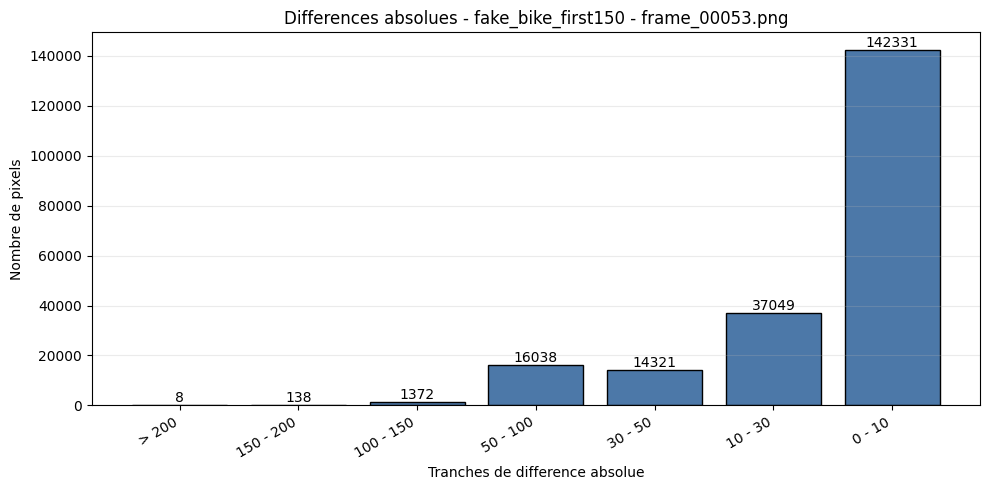

lvl:  4  initial error:  2353.782776349614


 error improvement too small, level converged! it:  6  error:  704.5583385192555  lambda:  1.6
lvl:  3  initial error:  711.8971694427894


 error improvement too small, level converged! it:  3  error:  672.047447027377  lambda:  7036874417766.4
lvl:  2  initial error:  629.2423852303709


 error improvement too small, level converged! it:  3  error:  618.0401574361899  lambda:  0.1


[fake_bike_first150] frame 54 -> frame_00054.png | sum error = 137125040.00 | mean abs error = 14.2742 | valid pixels = 209839


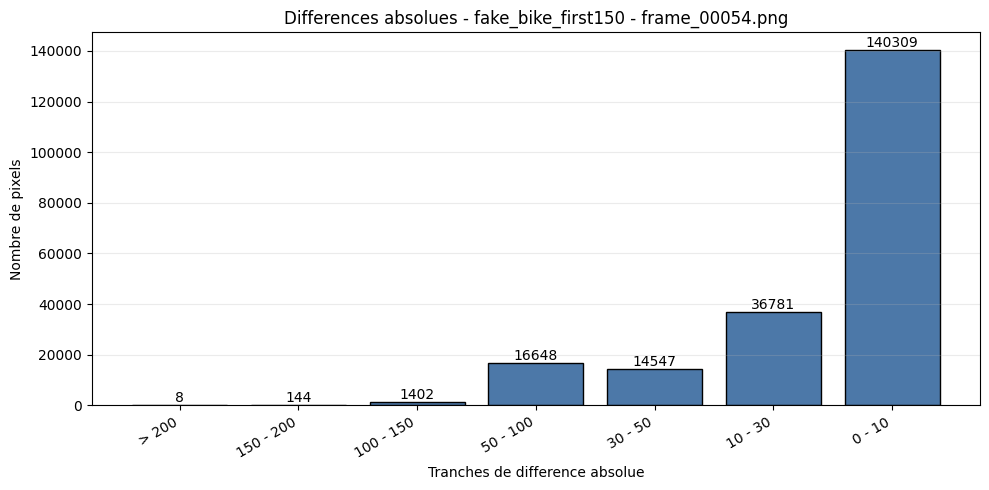

lvl:  4  initial error:  2501.029562982005


 error improvement too small, level converged! it:  5  error:  724.0983903352002  lambda:  1759218604441.6
lvl:  3  initial error:  656.5478294606253


 error improvement too small, level converged! it:  5  error:  641.2167865958653  lambda:  0.2


lvl:  2  initial error:  626.217092231208


 error improvement too small, level converged! it:  3  error:  615.2884780137409  lambda:  7036874417766.4


[fake_bike_first150] frame 55 -> frame_00055.png | sum error = 132558216.00 | mean abs error = 13.9505 | valid pixels = 206474


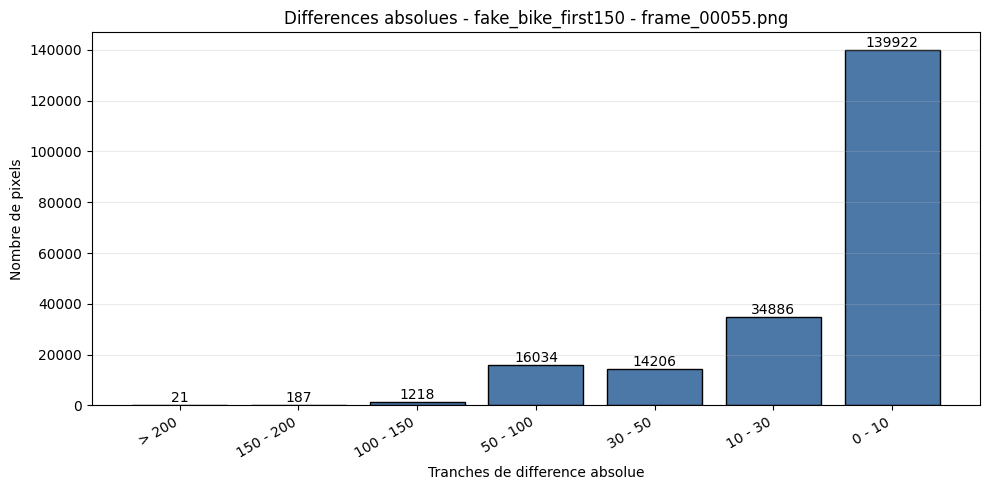

lvl:  4  initial error:  2690.795629820051


 error improvement too small, level converged! it:  5  error:  836.4033523091036  lambda:  0.1
lvl:  3  initial error:  740.2997783150751


 error improvement too small, level converged! it:  7  error:  678.0230441278488  lambda:  1759218604441.6


lvl:  2  initial error:  671.7461408440023


 error improvement too small, level converged! it:  5  error:  643.2860371102395  lambda:  0.8


[fake_bike_first150] frame 56 -> frame_00056.png | sum error = 137376928.00 | mean abs error = 14.5131 | valid pixels = 203049


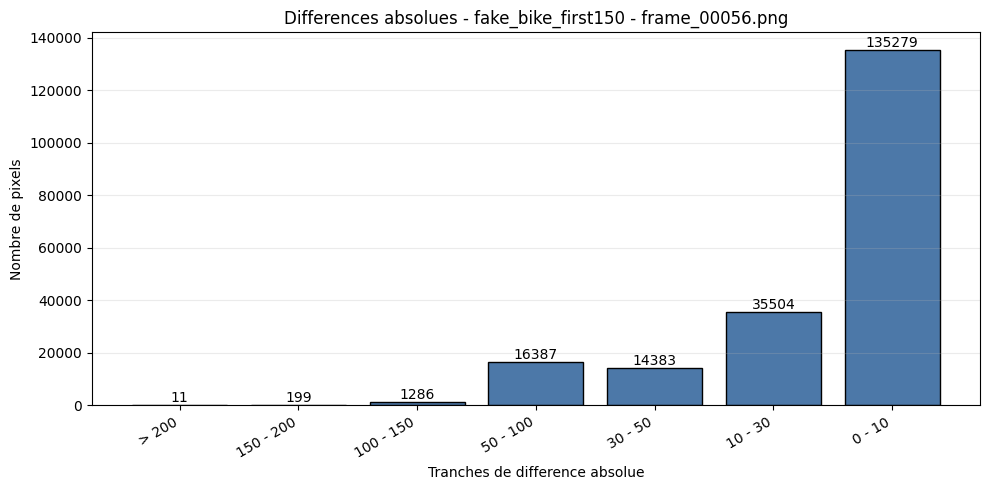

lvl:  4  initial error:  2776.2493573264783


update too small, level converged! it:  5  error:  837.6265846835123  lambda:  7205759403792794.0
lvl:  3  initial error:  721.8045370533115


 error improvement too small, level converged! it:  4  error:  692.5921146688844  lambda:  0.8


lvl:  2  initial error:  686.1297535467428


 error improvement too small, level converged! it:  4  error:  658.1963723414738  lambda:  6.4


[fake_bike_first150] frame 57 -> frame_00057.png | sum error = 138561520.00 | mean abs error = 14.6715 | valid pixels = 200593


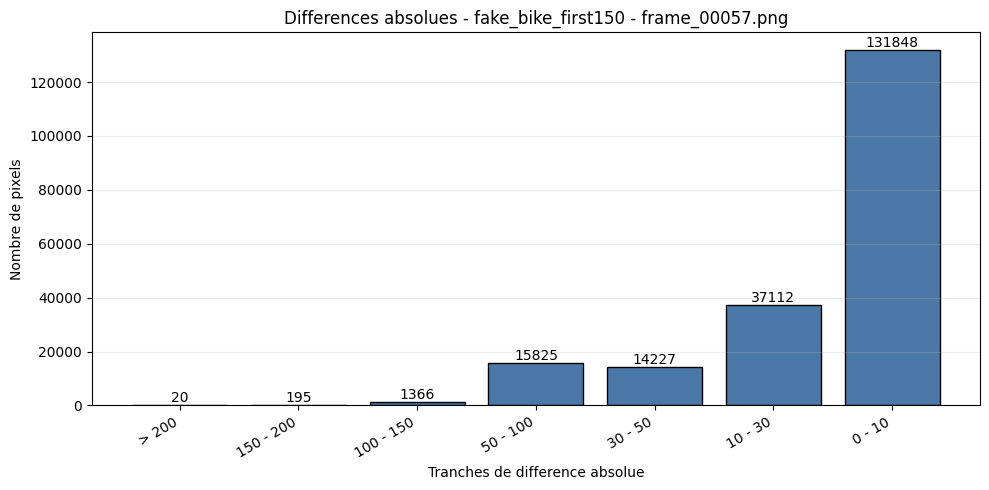

lvl:  4  initial error:  2921.2994858611823


 error improvement too small, level converged! it:  4  error:  840.791916590656  lambda:  0.2
lvl:  3  initial error:  738.9355705956574


 error improvement too small, level converged! it:  2  error:  711.040557135641  lambda:  0.0


lvl:  2  initial error:  693.0822867360565


 error improvement too small, level converged! it:  2  error:  681.677767790881  lambda:  0.1


[fake_bike_first150] frame 58 -> frame_00058.png | sum error = 142572768.00 | mean abs error = 14.9437 | valid pixels = 199600


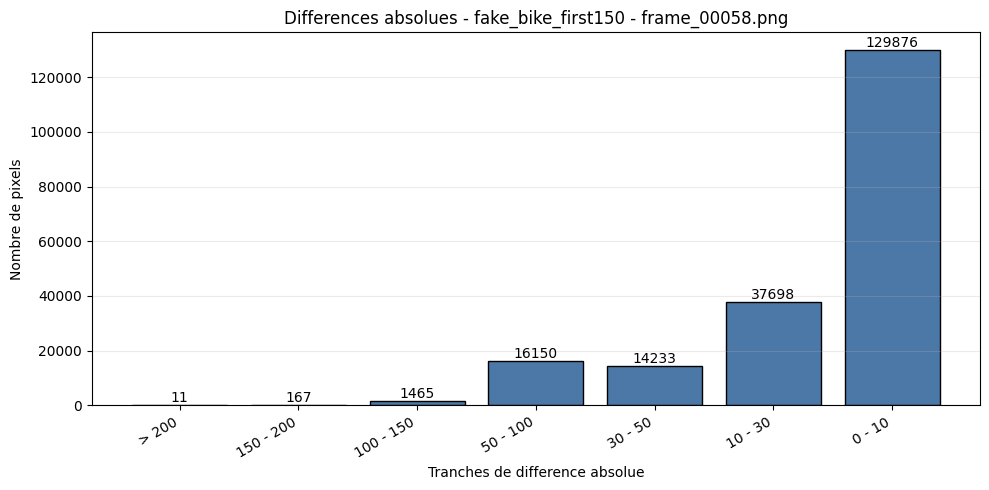

lvl:  4  initial error:  2981.787917737789


 error improvement too small, level converged! it:  8  error:  794.0258398081933  lambda:  0.1
lvl:  3  initial error:  782.8729274228749


 error improvement too small, level converged! it:  6  error:  739.0529350187879  lambda:  0.0


lvl:  2  initial error:  731.7223328438814


 error improvement too small, level converged! it:  2  error:  724.0848830421525  lambda:  0.0


[fake_bike_first150] frame 59 -> frame_00059.png | sum error = 150754384.00 | mean abs error = 15.3142 | valid pixels = 200139


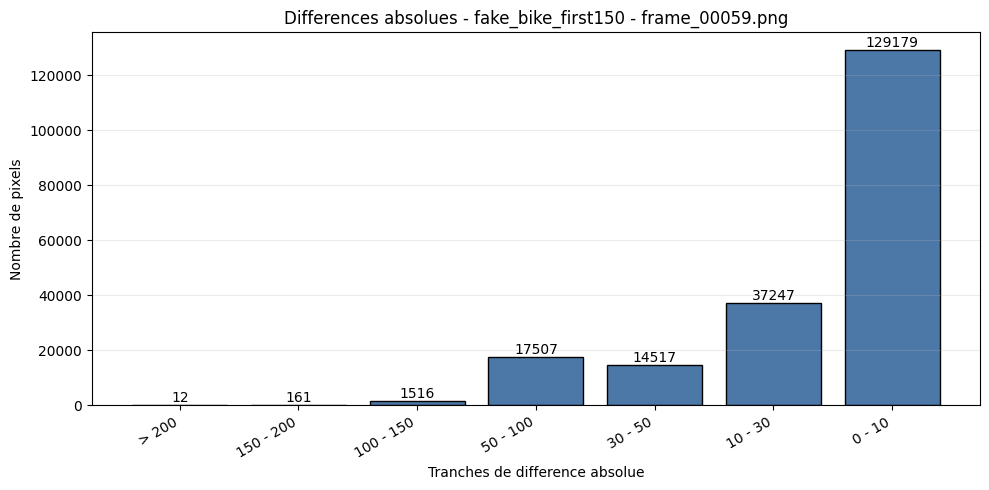

lvl:  4  initial error:  3093.6748071979428
 error improvement too small, level converged! it:  3  error:  868.5491396015283  lambda:  0.0


lvl:  3  initial error:  943.1303843398553


 error improvement too small, level converged! it:  5  error:  817.4641617670387  lambda:  0.4


lvl:  2  initial error:  832.2331516098325


 error improvement too small, level converged! it:  5  error:  783.7049302071025  lambda:  0.1


[fake_bike_first150] frame 60 -> frame_00060.png | sum error = 165008784.00 | mean abs error = 16.1133 | valid pixels = 203755


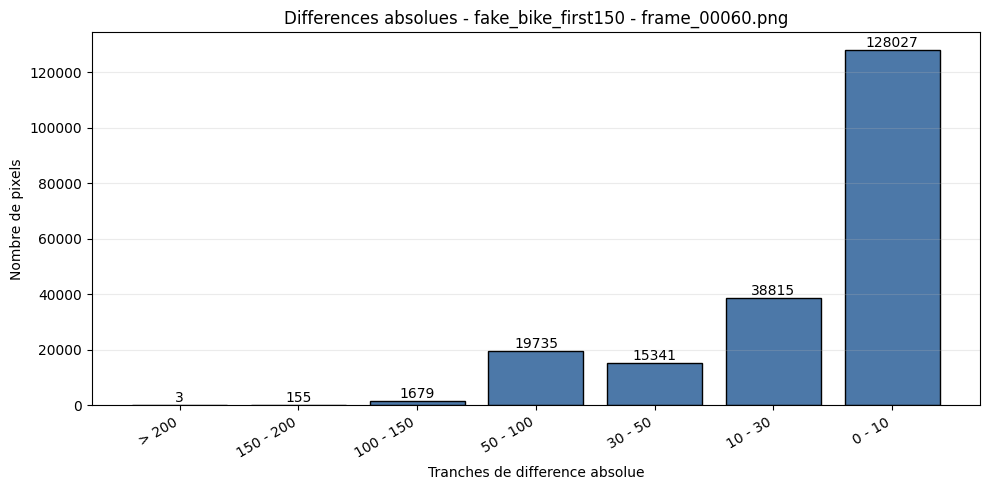

lvl:  4  initial error:  3069.502570694087


 error improvement too small, level converged! it:  5  error:  963.2500811810214  lambda:  0.1
lvl:  3  initial error:  850.9248544193597


 error improvement too small, level converged! it:  5  error:  806.7175796445526  lambda:  6.4


lvl:  2  initial error:  861.2823149430651


 error improvement too small, level converged! it:  4  error:  850.3480264332244  lambda:  0.0


[fake_bike_first150] frame 61 -> frame_00061.png | sum error = 180863920.00 | mean abs error = 17.0565 | valid pixels = 205992


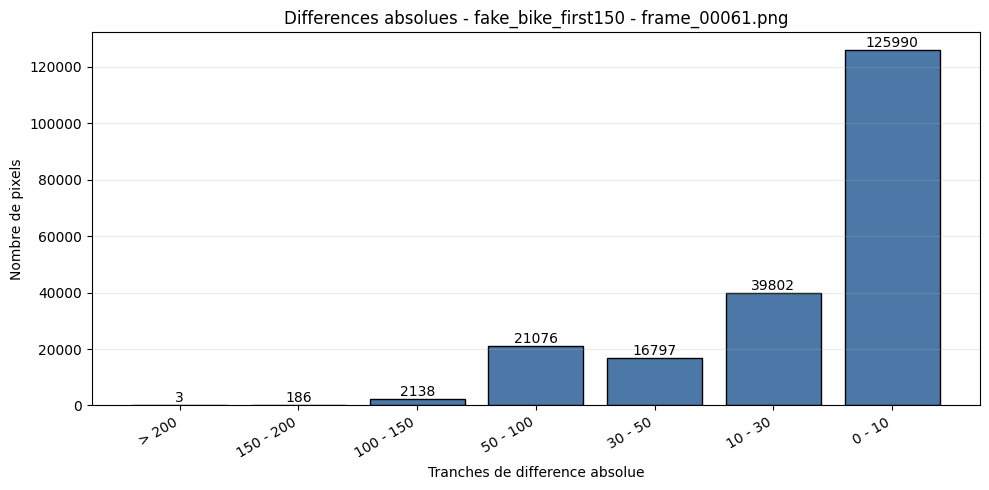

lvl:  4  initial error:  3152.3123393316196


 error improvement too small, level converged! it:  7  error:  969.6331527332725  lambda:  0.8
lvl:  3  initial error:  907.9492556561543


 error improvement too small, level converged! it:  3  error:  881.4982629837396  lambda:  0.1


lvl:  2  initial error:  929.7765605716805


 error improvement too small, level converged! it:  2  error:  920.1231232449458  lambda:  0.0


[fake_bike_first150] frame 62 -> frame_00062.png | sum error = 197518656.00 | mean abs error = 18.0750 | valid pixels = 207925


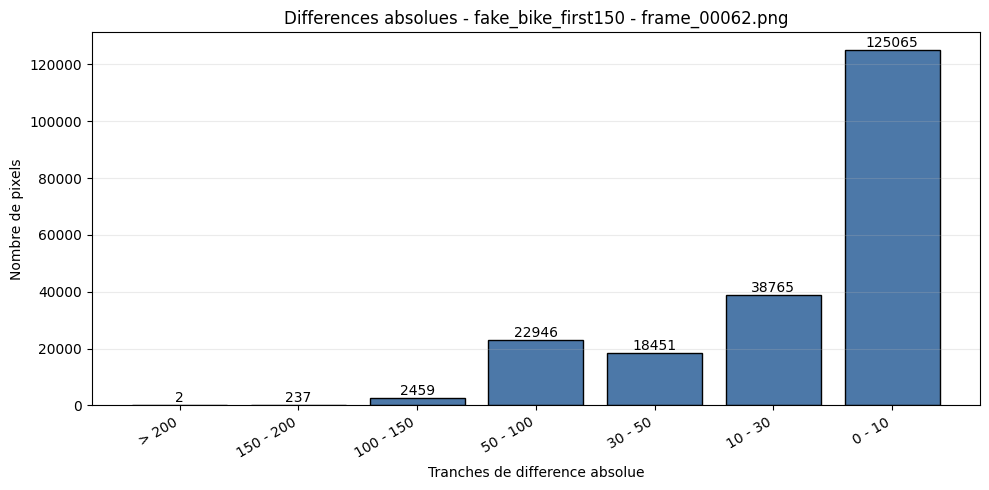

lvl:  4  initial error:  3148.7133676092544


 error improvement too small, level converged! it:  5  error:  1043.5473146006634  lambda:  1.6
lvl:  3  initial error:  1007.8529040527404


 error improvement too small, level converged! it:  6  error:  967.0249936217823  lambda:  0.0


lvl:  2  initial error:  1010.1869329027531


 error improvement too small, level converged! it:  2  error:  1005.6907883689368  lambda:  0.0


[fake_bike_first150] frame 63 -> frame_00063.png | sum error = 216269600.00 | mean abs error = 19.4601 | valid pixels = 208510


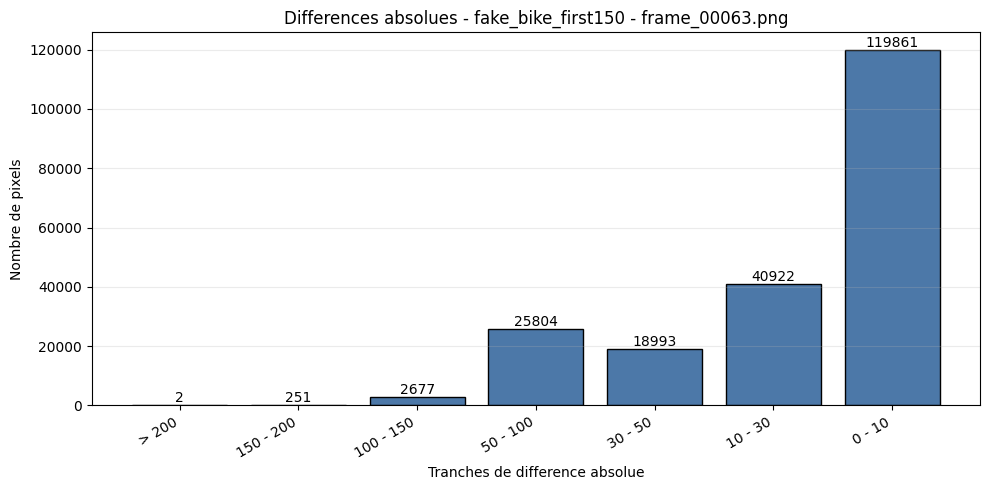

lvl:  4  initial error:  3215.8431876606683


 error improvement too small, level converged! it:  7  error:  1069.748607982372  lambda:  0.2
lvl:  3  initial error:  1008.3449279012


 error improvement too small, level converged! it:  2  error:  981.2007524100736  lambda:  1759218604441.6


lvl:  2  initial error:  1070.247644306264


 error improvement too small, level converged! it:  3  error:  1061.679494522794  lambda:  0.0


[fake_bike_first150] frame 64 -> frame_00064.png | sum error = 226645680.00 | mean abs error = 20.2765 | valid pixels = 208888


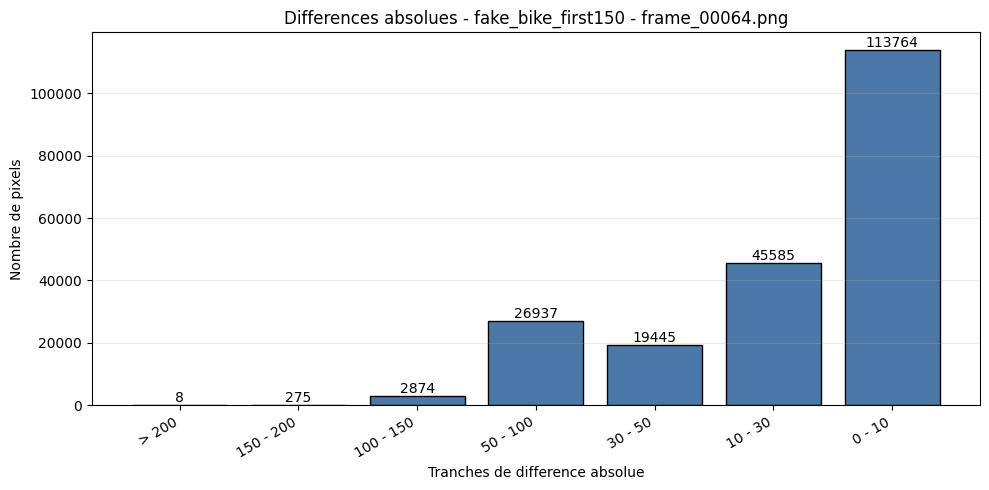

lvl:  4  initial error:  3251.4807197943446


 error improvement too small, level converged! it:  3  error:  1121.9563200025002  lambda:  14073748835532.8
lvl:  3  initial error:  1052.9297116585135


 error improvement too small, level converged! it:  4  error:  995.802789282104  lambda:  0.1


lvl:  2  initial error:  1096.4470980213575


 error improvement too small, level converged! it:  2  error:  1092.8180423342196  lambda:  0.0


[fake_bike_first150] frame 65 -> frame_00065.png | sum error = 231060160.00 | mean abs error = 20.9143 | valid pixels = 207588


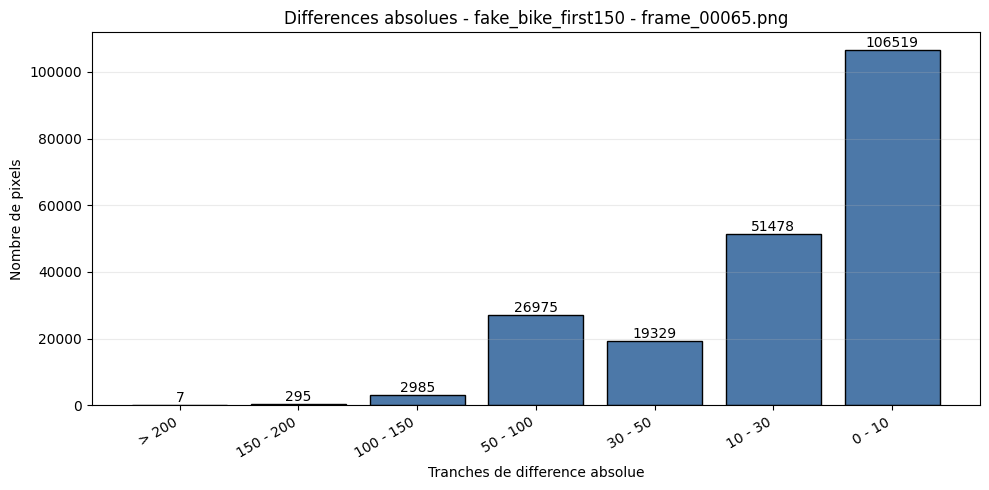

lvl:  4  initial error:  3252.8110539845757


 error improvement too small, level converged! it:  7  error:  1196.856720856791  lambda:  0.1
lvl:  3  initial error:  1232.6629433246173


 error improvement too small, level converged! it:  3  error:  1172.5991100620272  lambda:  0.4


lvl:  2  initial error:  1227.675392466806


 error improvement too small, level converged! it:  6  error:  1185.3962279829632  lambda:  56294995342131.2


[fake_bike_first150] frame 66 -> frame_00066.png | sum error = 255445024.00 | mean abs error = 22.4316 | valid pixels = 209601


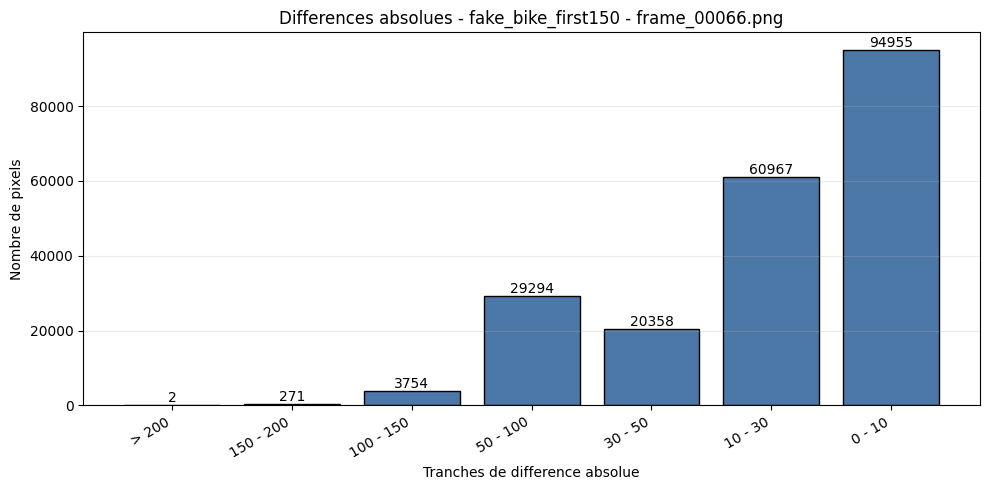

lvl:  4  initial error:  3295.7236503856043


 error improvement too small, level converged! it:  7  error:  1270.2897992254766  lambda:  0.1
lvl:  3  initial error:  1237.835855090287


 error improvement too small, level converged! it:  3  error:  1216.3598116821684  lambda:  28147497671065.6


lvl:  2  initial error:  1261.31789821208


 error improvement too small, level converged! it:  5  error:  1235.5846612126804  lambda:  1.6


[fake_bike_first150] frame 67 -> frame_00067.png | sum error = 268767264.00 | mean abs error = 23.3589 | valid pixels = 211362


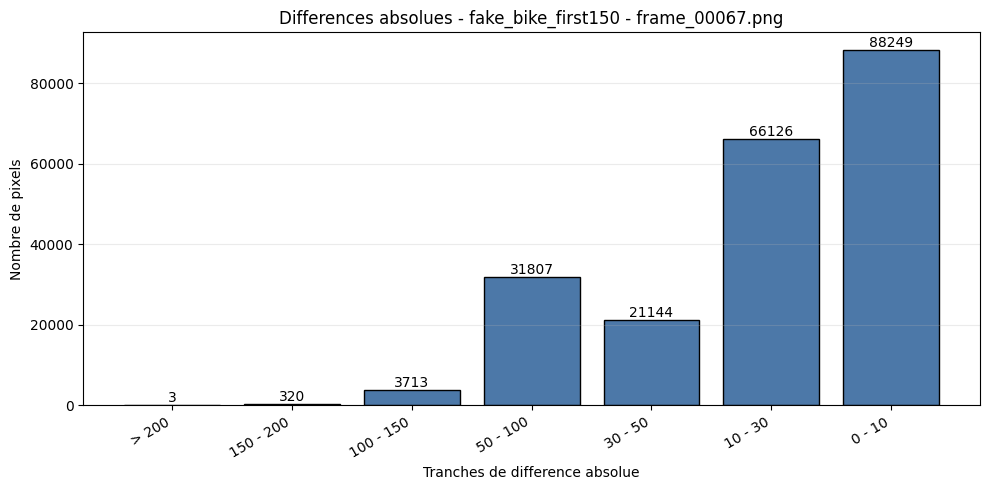

lvl:  4  initial error:  3141.340616966581


 error improvement too small, level converged! it:  7  error:  1192.3631531265717  lambda:  1.6
lvl:  3  initial error:  1208.488304851923


 error improvement too small, level converged! it:  2  error:  1206.4663364719727  lambda:  1759218604441.6


lvl:  2  initial error:  1285.8537678543762


 error improvement too small, level converged! it:  2  error:  1278.0503702690717  lambda:  0.0


[fake_bike_first150] frame 68 -> frame_00068.png | sum error = 282455040.00 | mean abs error = 24.0395 | valid pixels = 215322


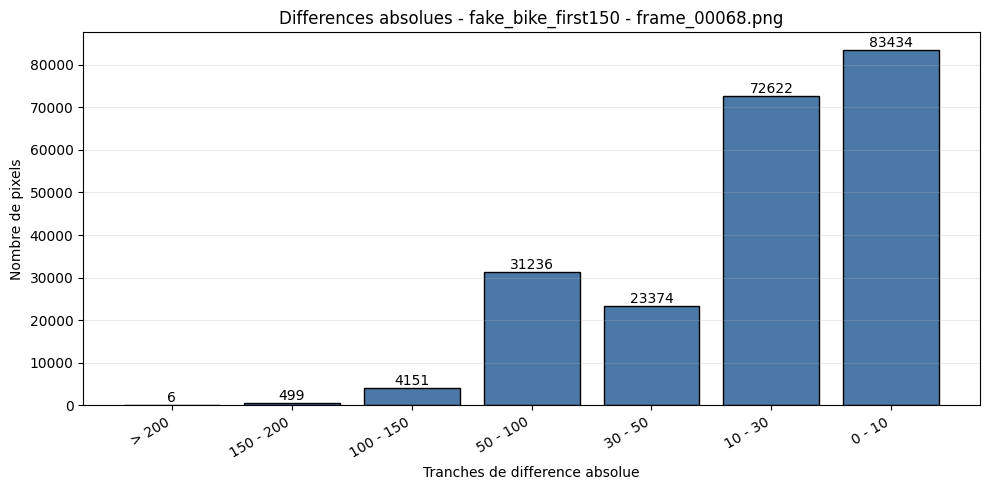

lvl:  4  initial error:  3207.924164524421


 error improvement too small, level converged! it:  3  error:  1246.8924002550577  lambda:  1.6
lvl:  3  initial error:  1270.9108474116604


 error improvement too small, level converged! it:  6  error:  1232.7203140230674  lambda:  0.0


lvl:  2  initial error:  1310.6172292061065


 error improvement too small, level converged! it:  4  error:  1303.061067080457  lambda:  0.0


[fake_bike_first150] frame 69 -> frame_00069.png | sum error = 290067200.00 | mean abs error = 24.8232 | valid pixels = 217460


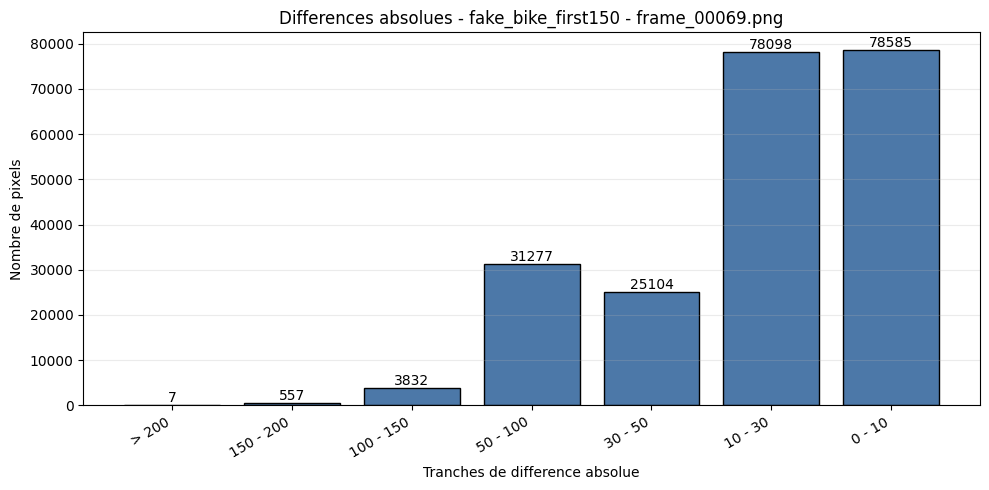

lvl:  4  initial error:  3078.6799485861184


 error improvement too small, level converged! it:  8  error:  1216.074837070319  lambda:  3.2
lvl:  3  initial error:  1252.3795059760268


 error improvement too small, level converged! it:  2  error:  1242.2688850885413  lambda:  0.1
lvl:  2  initial error:  1313.0672326176348


 error improvement too small, level converged! it:  2  error:  1308.241304447951  lambda:  0.0


[fake_bike_first150] frame 70 -> frame_00070.png | sum error = 296291744.00 | mean abs error = 25.4879 | valid pixels = 219085


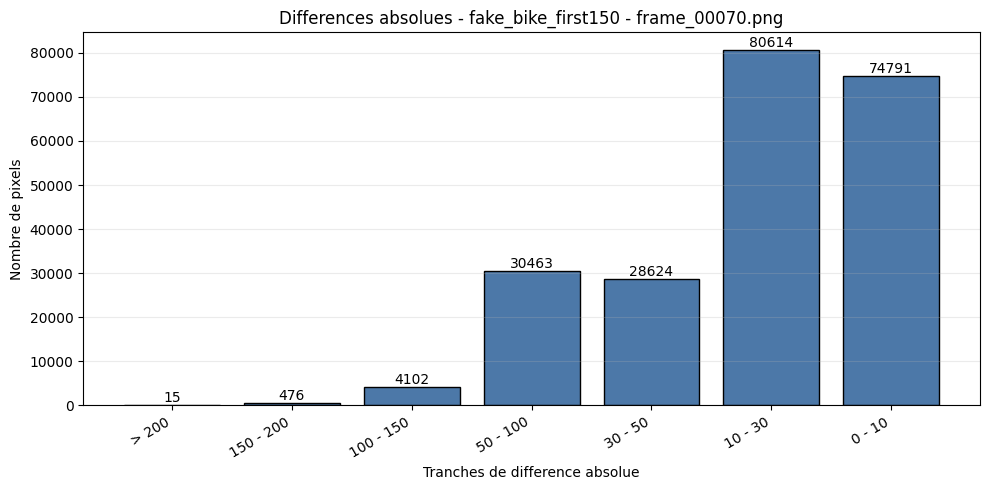

lvl:  4  initial error:  3092.0115681233933


 error improvement too small, level converged! it:  7  error:  1280.7403319754396  lambda:  0.2
lvl:  3  initial error:  1314.808004783114


 error improvement too small, level converged! it:  2  error:  1312.0264323167391  lambda:  0.2
lvl:  2  initial error:  1353.7295313167974


 error improvement too small, level converged! it:  2  error:  1341.4208020127253  lambda:  0.1


[fake_bike_first150] frame 71 -> frame_00071.png | sum error = 304085376.00 | mean abs error = 26.4636 | valid pixels = 219864


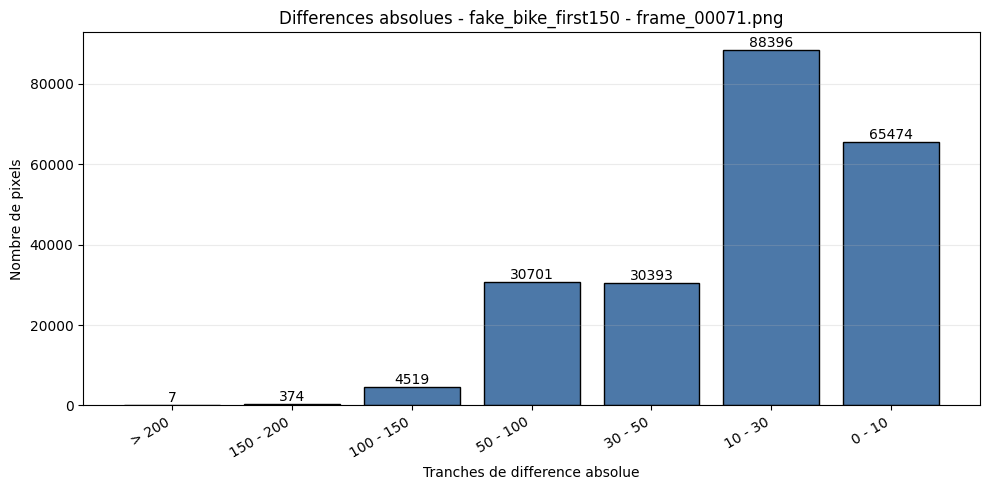

lvl:  4  initial error:  3088.456298200514
 error improvement too small, level converged! it:  4  error:  1514.0989536295945  lambda:  3.2
lvl:  3  initial error:  1462.6335567618262


 error improvement too small, level converged! it:  4  error:  1435.770441440005  lambda:  0.1
lvl:  2  initial error:  1451.833949737461


 error improvement too small, level converged! it:  4  error:  1409.4011766366261  lambda:  0.1


[fake_bike_first150] frame 72 -> frame_00072.png | sum error = 319422336.00 | mean abs error = 27.5362 | valid pixels = 220012


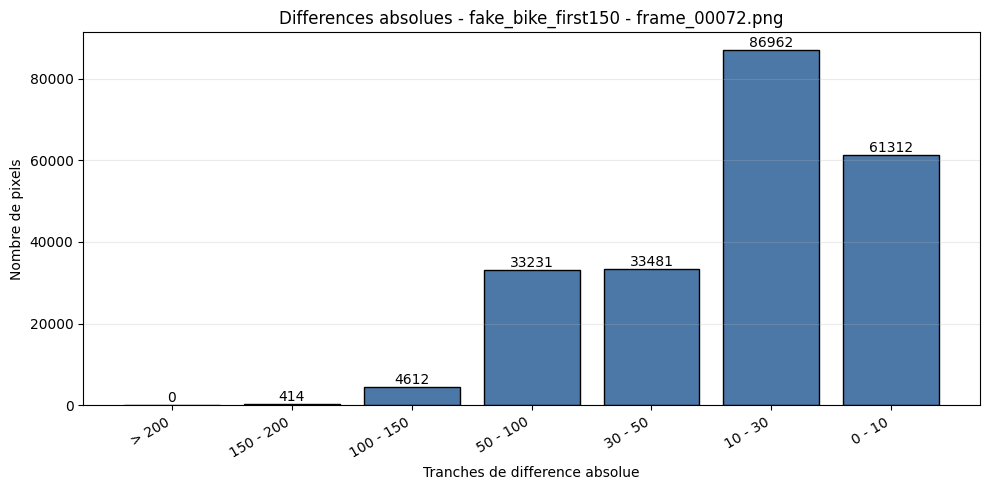

lvl:  4  initial error:  3175.344473007712
 error improvement too small, level converged! it:  5  error:  1541.7699549203403  lambda:  0.8


lvl:  3  initial error:  1544.6375787081554
 error improvement too small, level converged! it:  3  error:  1525.611165300024  lambda:  0.0


lvl:  2  initial error:  1596.3168635648458


 error improvement too small, level converged! it:  1  error:  1595.0937662779595  lambda:  0.0


[fake_bike_first150] frame 73 -> frame_00073.png | sum error = 363308032.00 | mean abs error = 29.2892 | valid pixels = 219198


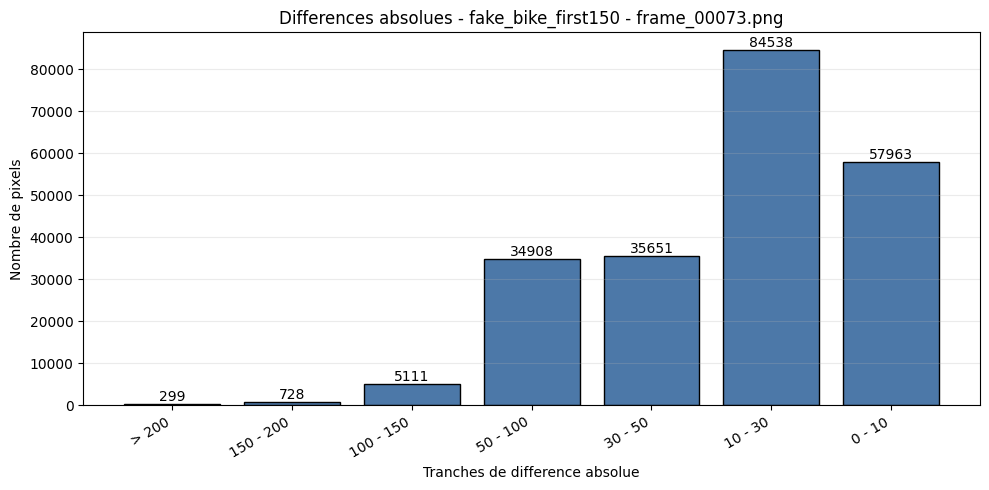

lvl:  4  initial error:  3513.6992287917737


 error improvement too small, level converged! it:  6  error:  1716.6701388272315  lambda:  3.2
lvl:  3  initial error:  1786.8216244272976


 error improvement too small, level converged! it:  6  error:  1735.7137573408625  lambda:  0.0
lvl:  2  initial error:  1763.9731045479355


 error improvement too small, level converged! it:  5  error:  1739.0216761394454  lambda:  0.1


[fake_bike_first150] frame 74 -> frame_00074.png | sum error = 391911072.00 | mean abs error = 31.6485 | valid pixels = 218418


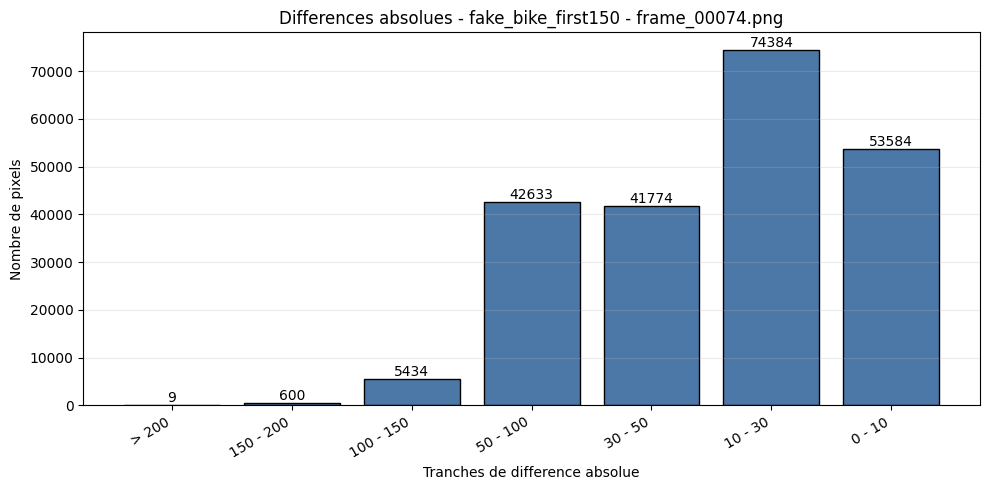

lvl:  4  initial error:  3613.4640102827757
 error improvement too small, level converged! it:  8  error:  1587.127934310488  lambda:  0.0


lvl:  3  initial error:  1636.2329606594803


 error improvement too small, level converged! it:  6  error:  1443.0563328678509  lambda:  0.0
lvl:  2  initial error:  1572.3082064664313


 error improvement too small, level converged! it:  2  error:  1566.6443611719217  lambda:  879609302220.8


[fake_bike_first150] frame 75 -> frame_00075.png | sum error = 344073152.00 | mean abs error = 29.7096 | valid pixels = 216042


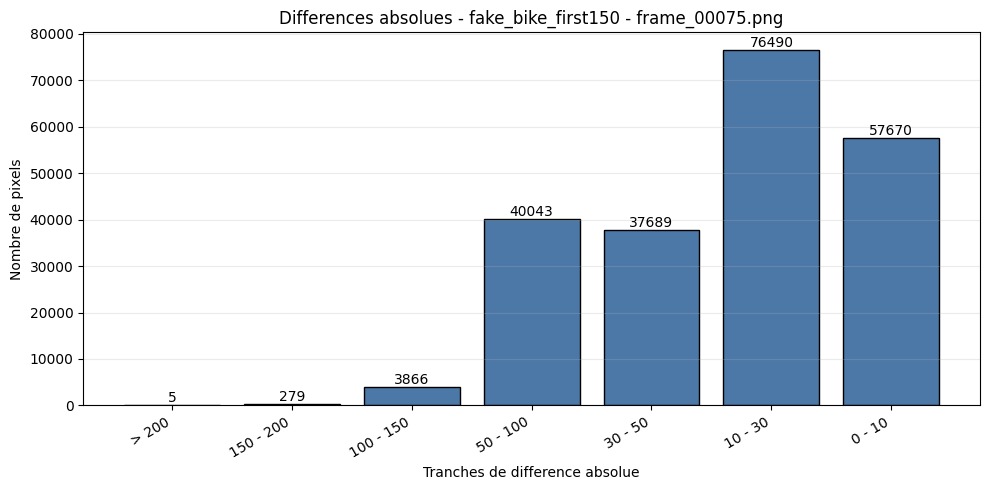

lvl:  4  initial error:  3988.0154241645237


 error improvement too small, level converged! it:  5  error:  1588.1059647660356  lambda:  225179981368524.8
lvl:  3  initial error:  1661.8513311233248


 error improvement too small, level converged! it:  6  error:  1512.2822136602504  lambda:  7036874417766.4
lvl:  2  initial error:  1658.6905234543844


 error improvement too small, level converged! it:  1  error:  1657.993304873236  lambda:  0.0


[fake_bike_first150] frame 76 -> frame_00076.png | sum error = 366270304.00 | mean abs error = 30.8001 | valid pixels = 215908


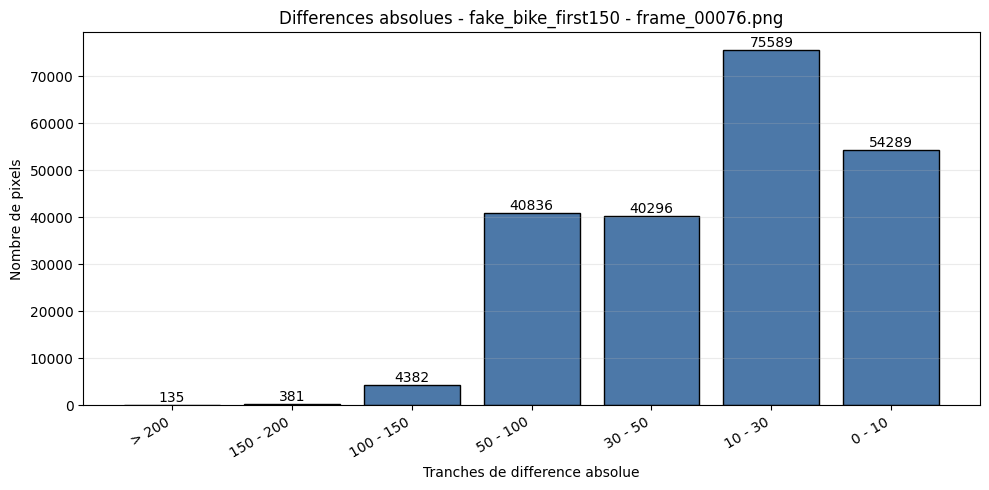

lvl:  4  initial error:  4053.721079691517
 error improvement too small, level converged! it:  3  error:  1858.368075524321  lambda:  0.2
lvl:  3  initial error:  1829.560075299847


 error improvement too small, level converged! it:  3  error:  1823.6117511855646  lambda:  429496729.6
lvl:  2  initial error:  1884.881674010469


 error improvement too small, level converged! it:  4  error:  1869.3563269191293  lambda:  0.0


[fake_bike_first150] frame 77 -> frame_00077.png | sum error = 433972448.00 | mean abs error = 33.9422 | valid pixels = 216534


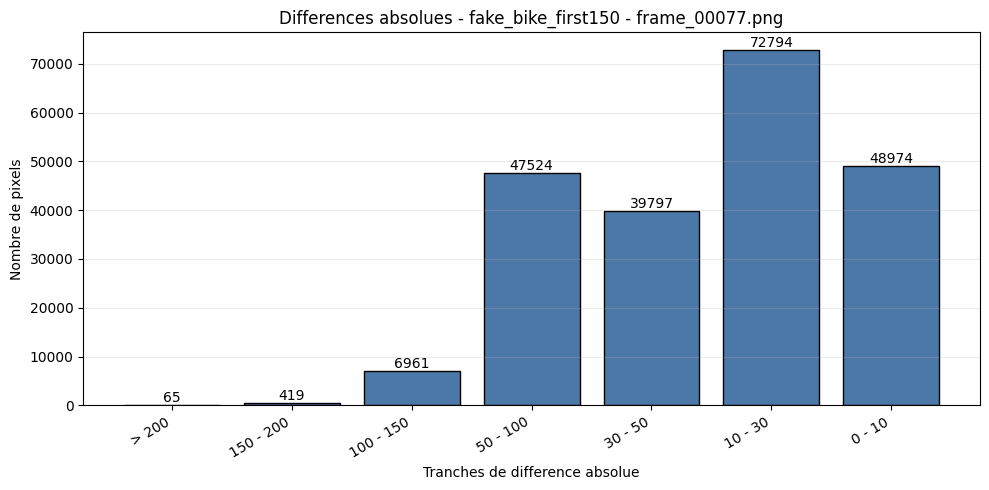

lvl:  4  initial error:  4103.951156812339
 error improvement too small, level converged! it:  4  error:  2211.2278887276166  lambda:  6.4
lvl:  3  initial error:  2271.708236374647


 error improvement too small, level converged! it:  10  error:  2101.1911752754286  lambda:  0.0
lvl:  2  initial error:  2167.5882656827625


 error improvement too small, level converged! it:  3  error:  2157.6289149876225  lambda:  0.0


[fake_bike_first150] frame 78 -> frame_00078.png | sum error = 506188736.00 | mean abs error = 36.3944 | valid pixels = 220383


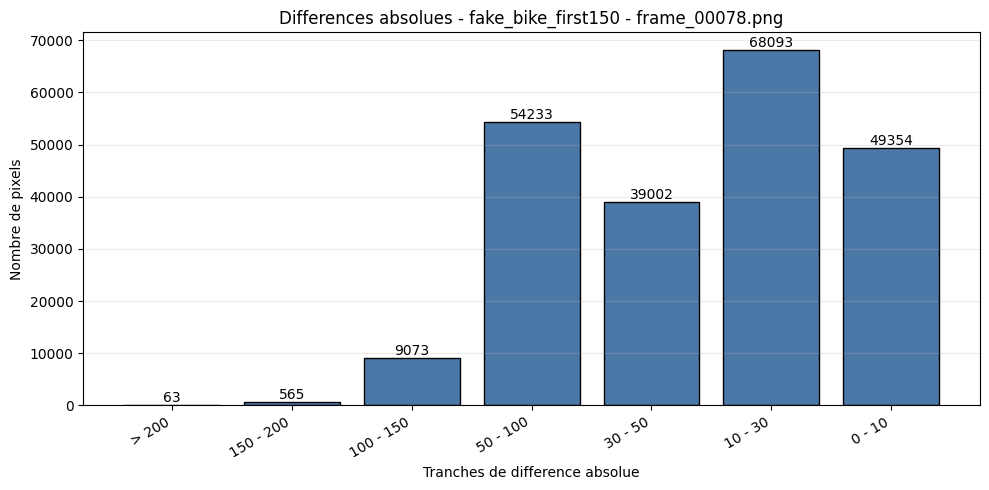

lvl:  4  initial error:  4438.285347043701


 error improvement too small, level converged! it:  7  error:  2003.486195164494  lambda:  112589990684262.4
lvl:  3  initial error:  2251.7433771415845


 error improvement too small, level converged! it:  2  error:  2219.8652274908686  lambda:  0.8
lvl:  2  initial error:  2467.171916256683


 error improvement too small, level converged! it:  6  error:  2192.0192976209655  lambda:  0.0


[fake_bike_first150] frame 79 -> frame_00079.png | sum error = 511143200.00 | mean abs error = 36.6490 | valid pixels = 220541


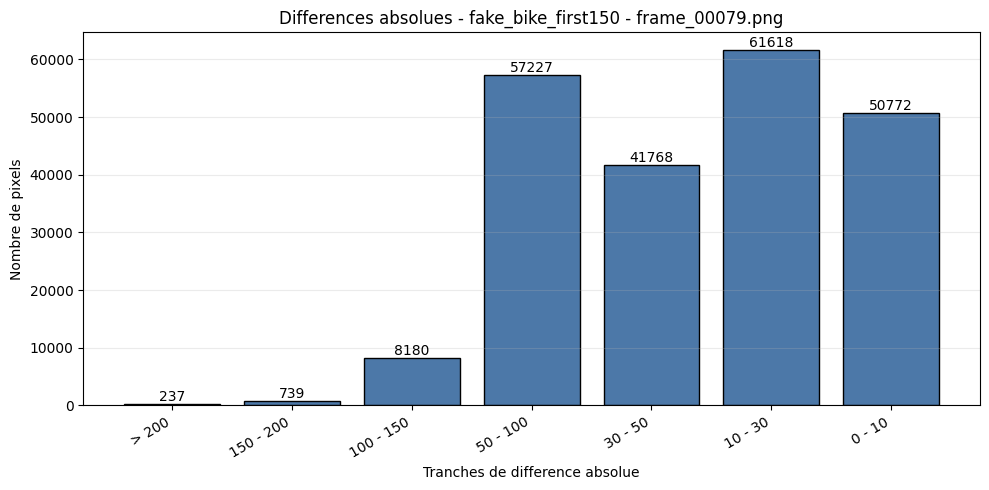

lvl:  4  initial error:  4524.041131105398
 error improvement too small, level converged! it:  4  error:  2354.613516704285  lambda:  0.0
lvl:  3  initial error:  2712.546297671059


update too small, level converged! it:  5  error:  2541.1016568122773  lambda:  7205759403792794.0
lvl:  2  initial error:  2534.135974391742


 error improvement too small, level converged! it:  4  error:  2494.308948406314  lambda:  0.0


[fake_bike_first150] frame 80 -> frame_00080.png | sum error = 586376000.00 | mean abs error = 39.4921 | valid pixels = 220541


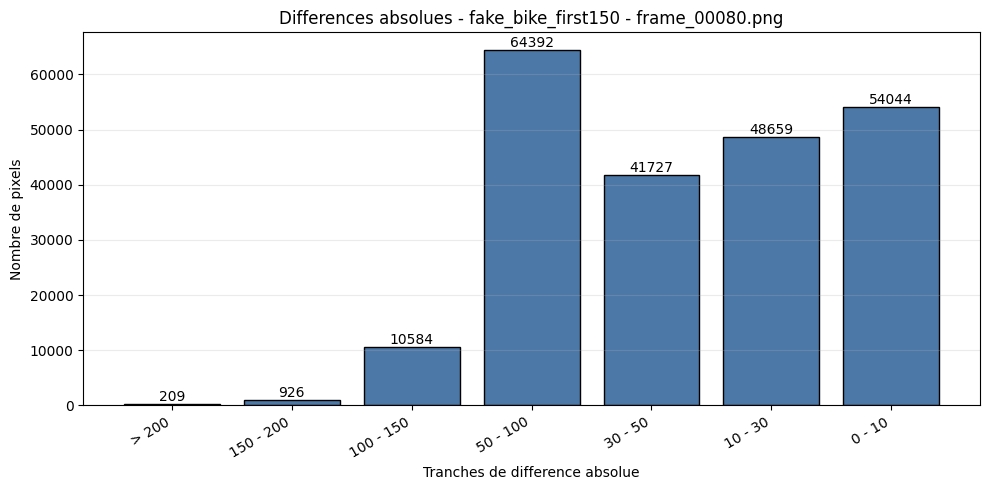

lvl:  4  initial error:  4458.921593830334


 error improvement too small, level converged! it:  5  error:  2825.407931772143  lambda:  7036874417766.4
lvl:  3  initial error:  2954.61332580704


 error improvement too small, level converged! it:  4  error:  2901.8466052739377  lambda:  0.4
lvl:  2  initial error:  2806.0451512670893


 error improvement too small, level converged! it:  4  error:  2684.272680645018  lambda:  0.0


[fake_bike_first150] frame 81 -> frame_00081.png | sum error = 657170048.00 | mean abs error = 42.1485 | valid pixels = 220541


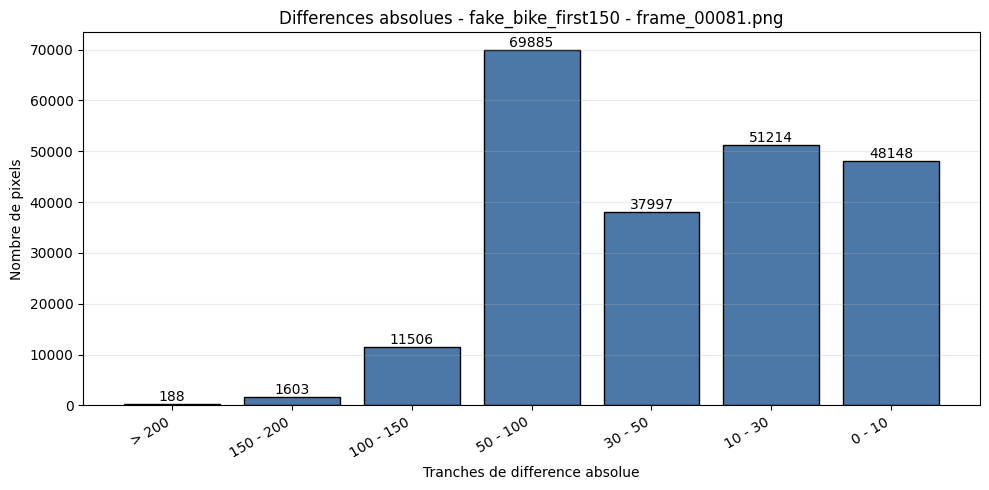

lvl:  4  initial error:  4380.841902313625


 error improvement too small, level converged! it:  13  error:  1756.9912688067193  lambda:  0.1
lvl:  3  initial error:  2490.13053873096


 error improvement too small, level converged! it:  7  error:  2351.3714443368585  lambda:  28147497671065.6
lvl:  2  initial error:  2439.999460741858


 error improvement too small, level converged! it:  4  error:  2395.896021776793  lambda:  0.0


[fake_bike_first150] frame 82 -> frame_00082.png | sum error = 572952192.00 | mean abs error = 38.3719 | valid pixels = 220541


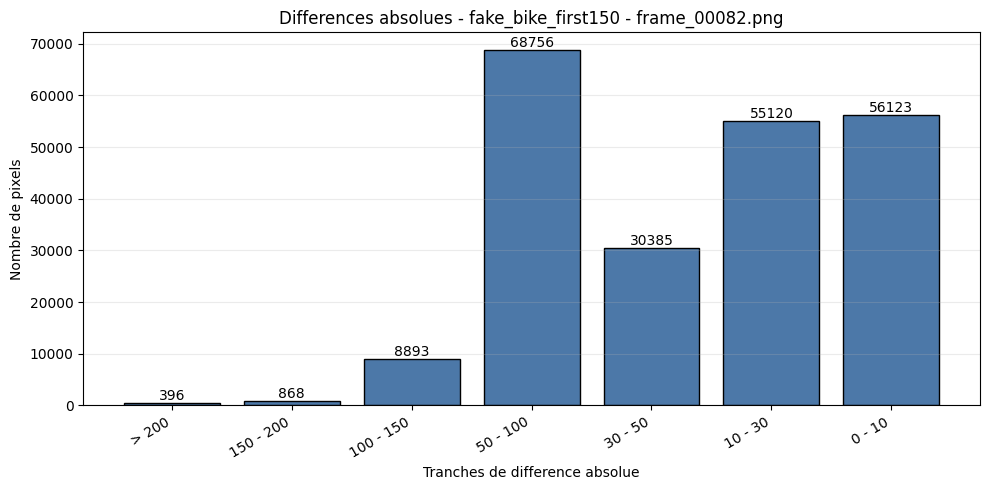

lvl:  4  initial error:  4306.343187660668


 error improvement too small, level converged! it:  7  error:  1773.543663685504  lambda:  14073748835532.8
lvl:  3  initial error:  2281.853700971233


 error improvement too small, level converged! it:  14  error:  2027.0333359689168  lambda:  0.0
lvl:  2  initial error:  2248.0865296234156


 error improvement too small, level converged! it:  13  error:  2142.311983434088  lambda:  0.0


[fake_bike_first150] frame 83 -> frame_00083.png | sum error = 502585984.00 | mean abs error = 36.0349 | valid pixels = 220541


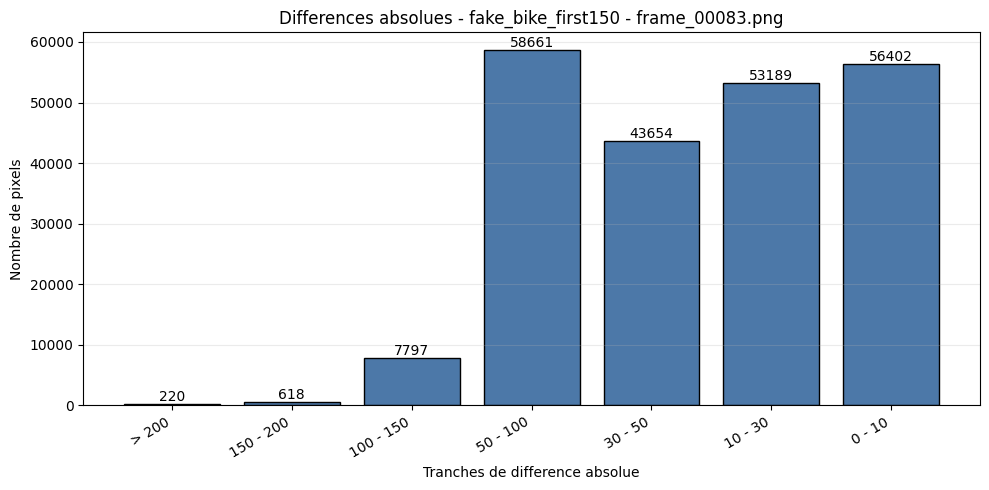

lvl:  4  initial error:  4111.377892030849


update too small, level converged! it:  6  error:  2063.3709278323245  lambda:  900719925474099.2
lvl:  3  initial error:  2318.522608231233


 error improvement too small, level converged! it:  25  error:  2034.0685742263938  lambda:  0.0
lvl:  2  initial error:  2095.773349465293


 error improvement too small, level converged! it:  5  error:  2071.3766583930637  lambda:  0.0


[fake_bike_first150] frame 84 -> frame_00084.png | sum error = 490231488.00 | mean abs error = 35.7710 | valid pixels = 220541


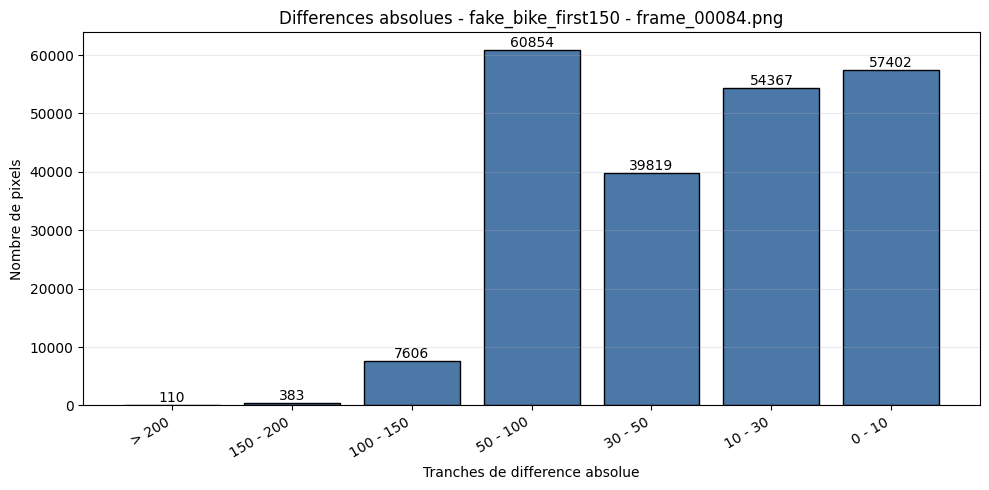

lvl:  4  initial error:  3863.907455012853


 error improvement too small, level converged! it:  11  error:  1684.170916226704  lambda:  0.0
lvl:  3  initial error:  2017.188145610173


 error improvement too small, level converged! it:  13  error:  1883.4069700533844  lambda:  0.0
lvl:  2  initial error:  1954.1570794648892


 error improvement too small, level converged! it:  9  error:  1906.2566747141675  lambda:  0.0


[fake_bike_first150] frame 85 -> frame_00085.png | sum error = 454057504.00 | mean abs error = 33.8317 | valid pixels = 220541


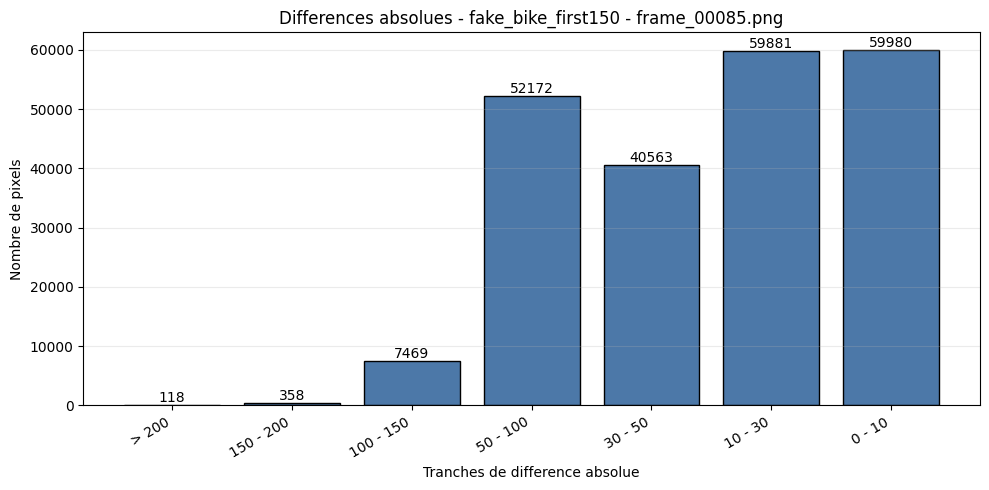

lvl:  4  initial error:  4116.753213367609


 error improvement too small, level converged! it:  8  error:  1505.2794821285374  lambda:  14073748835532.8
lvl:  3  initial error:  1983.8849494552353


 error improvement too small, level converged! it:  29  error:  1726.3507614157272  lambda:  0.0
lvl:  2  initial error:  1838.3561869060325


 error improvement too small, level converged! it:  5  error:  1802.5223547875348  lambda:  0.0


[fake_bike_first150] frame 86 -> frame_00086.png | sum error = 432150048.00 | mean abs error = 33.2899 | valid pixels = 220541


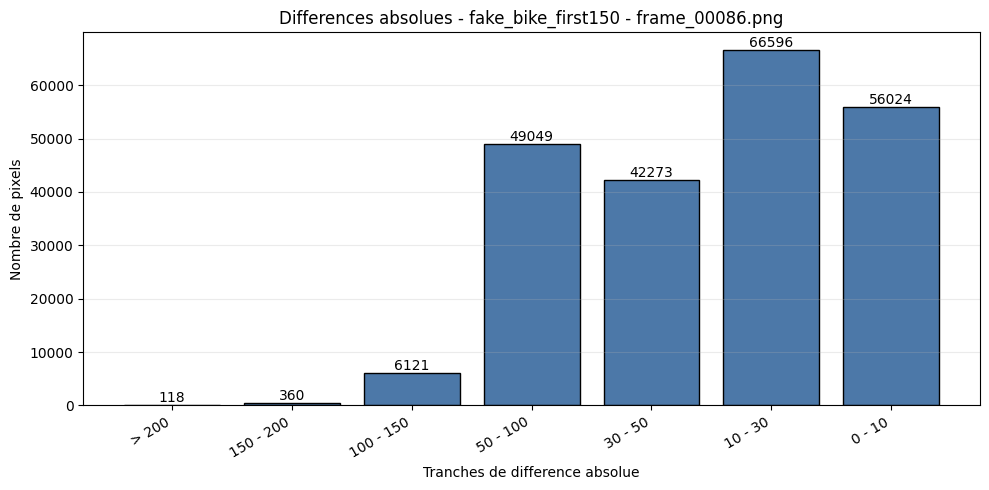

lvl:  4  initial error:  4313.906169665809


 error improvement too small, level converged! it:  7  error:  1526.5358180979135  lambda:  0.1
lvl:  3  initial error:  1826.024790699047


 error improvement too small, level converged! it:  3  error:  1790.7604469462099  lambda:  0.0
lvl:  2  initial error:  1863.5576277095247


 error improvement too small, level converged! it:  6  error:  1806.3096995218987  lambda:  0.0


[fake_bike_first150] frame 87 -> frame_00087.png | sum error = 442561280.00 | mean abs error = 34.0376 | valid pixels = 220541


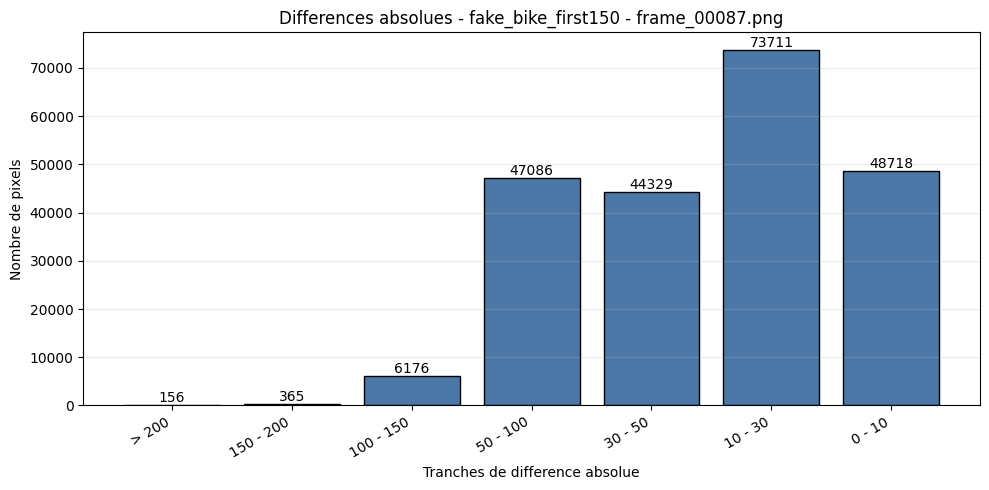

lvl:  4  initial error:  4293.658097686374


 error improvement too small, level converged! it:  5  error:  1625.9614611430748  lambda:  0.0
lvl:  3  initial error:  2090.869738916971


 error improvement too small, level converged! it:  6  error:  1857.5513831399333  lambda:  0.0


lvl:  2  initial error:  1984.7844389968543


 error improvement too small, level converged! it:  15  error:  1923.2672218131734  lambda:  0.0


[fake_bike_first150] frame 88 -> frame_00088.png | sum error = 451980704.00 | mean abs error = 34.0883 | valid pixels = 220541


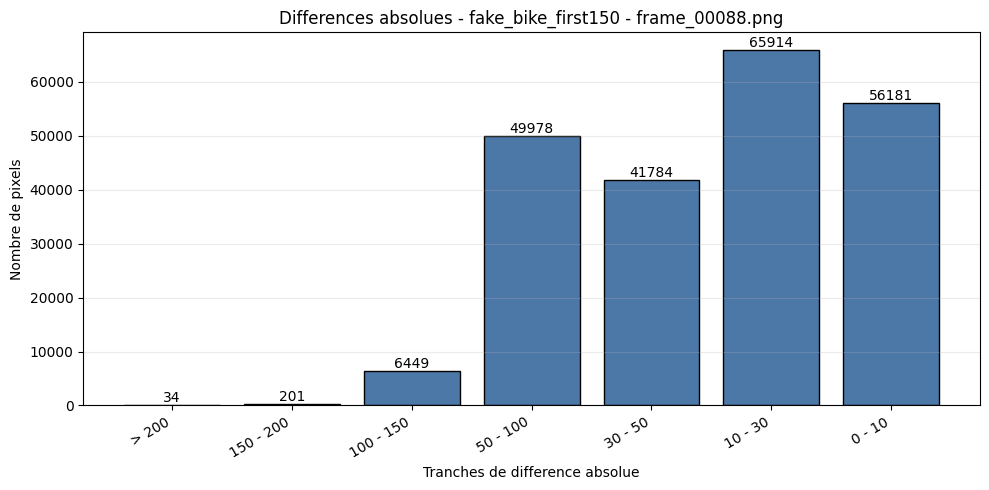

lvl:  4  initial error:  4355.053984575835


 error improvement too small, level converged! it:  5  error:  1569.473233165618  lambda:  0.2
lvl:  3  initial error:  1912.827100850733


 error improvement too small, level converged! it:  2  error:  1834.703402169545  lambda:  0.8


lvl:  2  initial error:  1849.9901573745492


 error improvement too small, level converged! it:  7  error:  1786.896913753168  lambda:  0.0


[fake_bike_first150] frame 89 -> frame_00089.png | sum error = 424864256.00 | mean abs error = 33.2556 | valid pixels = 220541


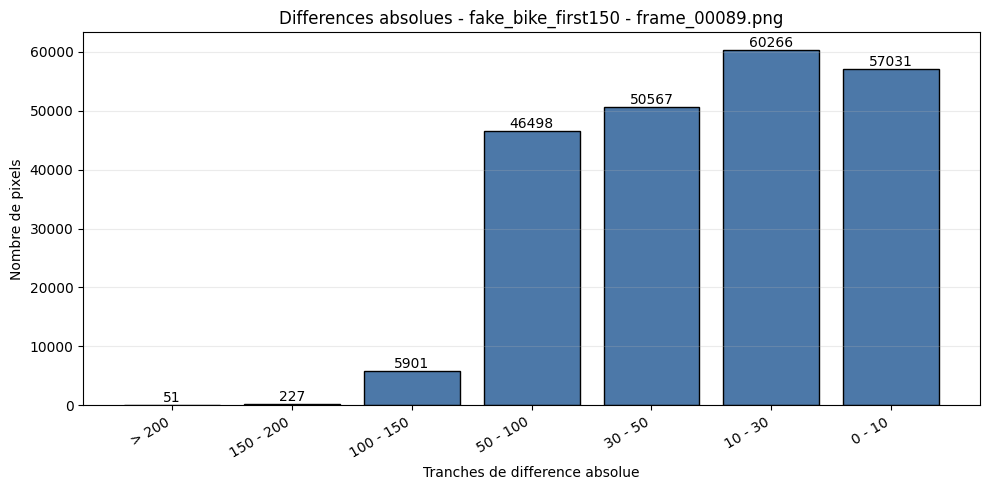

lvl:  4  initial error:  4331.987146529563


update too small, level converged! it:  3  error:  1619.3359961138472  lambda:  7205759403792794.0
lvl:  3  initial error:  1872.3837844136804


 error improvement too small, level converged! it:  15  error:  1765.3092360435905  lambda:  0.0


lvl:  2  initial error:  1778.852921042801


 error improvement too small, level converged! it:  3  error:  1750.5706475106335  lambda:  0.0


[fake_bike_first150] frame 90 -> frame_00090.png | sum error = 424150400.00 | mean abs error = 32.8735 | valid pixels = 219915


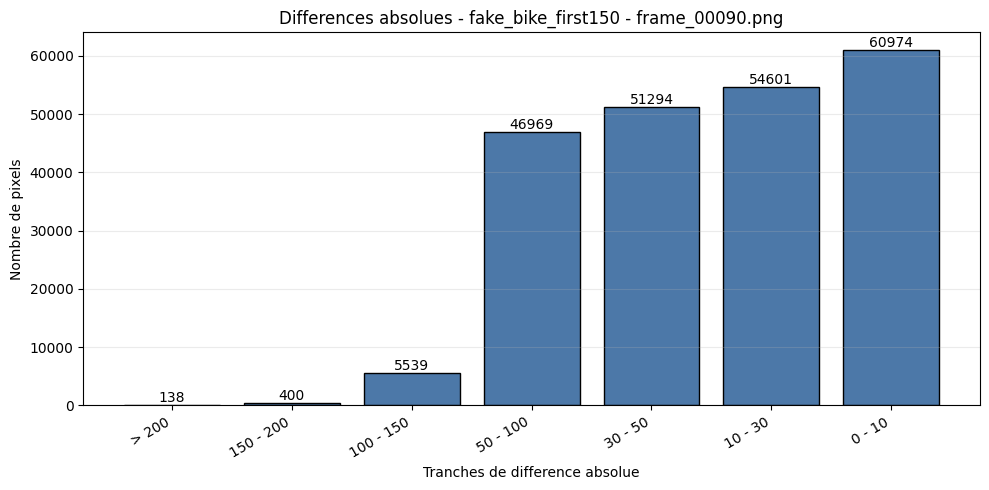

lvl:  4  initial error:  4263.811053984576


 error improvement too small, level converged! it:  5  error:  1961.1177728970638  lambda:  1.6
lvl:  3  initial error:  2123.0064384133098


 error improvement too small, level converged! it:  15  error:  1709.1185515090551  lambda:  0.0


lvl:  2  initial error:  1828.457354978314


 error improvement too small, level converged! it:  13  error:  1731.6011990160991  lambda:  0.0


[fake_bike_first150] frame 91 -> frame_00091.png | sum error = 407980288.00 | mean abs error = 32.6676 | valid pixels = 220110


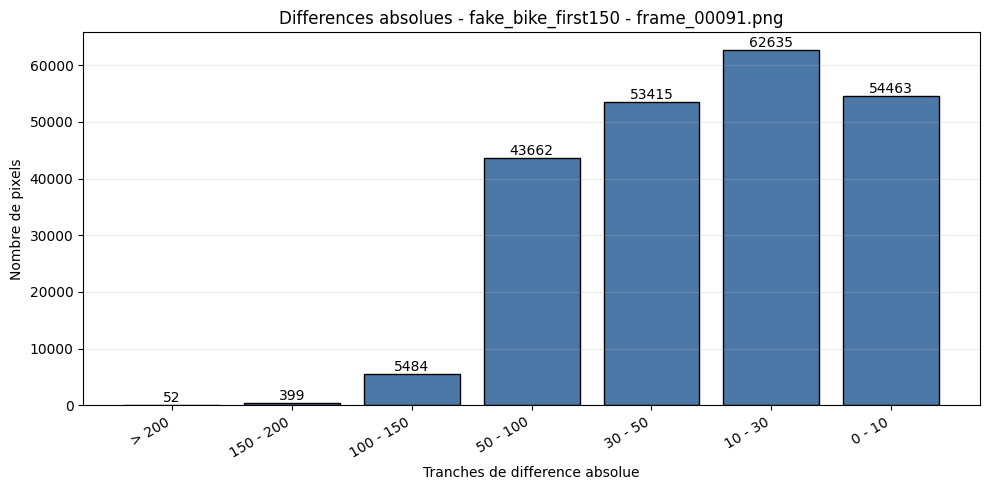

lvl:  4  initial error:  4330.605398457583


 error improvement too small, level converged! it:  7  error:  1654.490184525241  lambda:  7036874417766.4
lvl:  3  initial error:  2026.6348411760143


 error improvement too small, level converged! it:  16  error:  1683.1052544902368  lambda:  0.0


lvl:  2  initial error:  1735.4786052692477


 error improvement too small, level converged! it:  4  error:  1707.6577572218582  lambda:  0.0


[fake_bike_first150] frame 92 -> frame_00092.png | sum error = 408623552.00 | mean abs error = 33.1407 | valid pixels = 220541


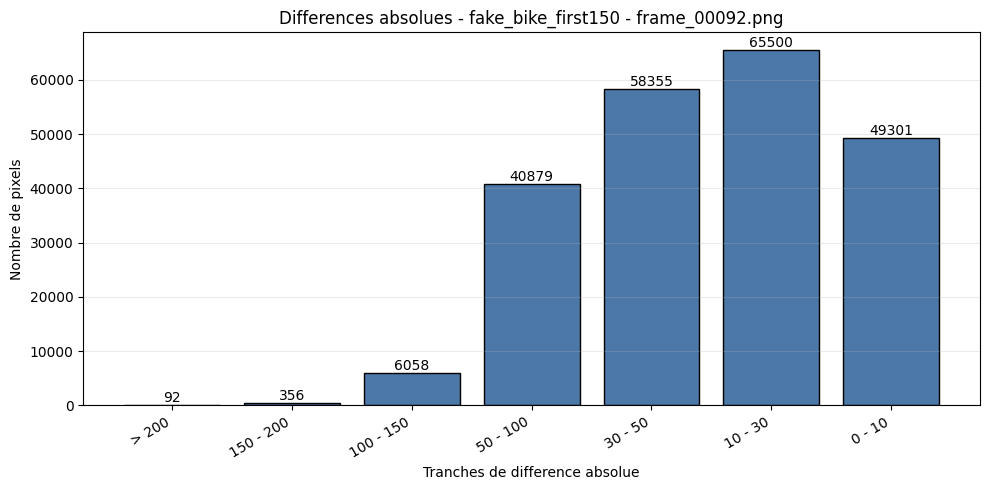

lvl:  4  initial error:  4484.299485861182


 error improvement too small, level converged! it:  8  error:  1516.4619386262173  lambda:  879609302220.8
lvl:  3  initial error:  1804.911778741925


 error improvement too small, level converged! it:  13  error:  1634.1597029188  lambda:  0.0


lvl:  2  initial error:  1744.243882343377


 error improvement too small, level converged! it:  6  error:  1669.635612238694  lambda:  0.0


[fake_bike_first150] frame 93 -> frame_00093.png | sum error = 403120928.00 | mean abs error = 32.8577 | valid pixels = 220541


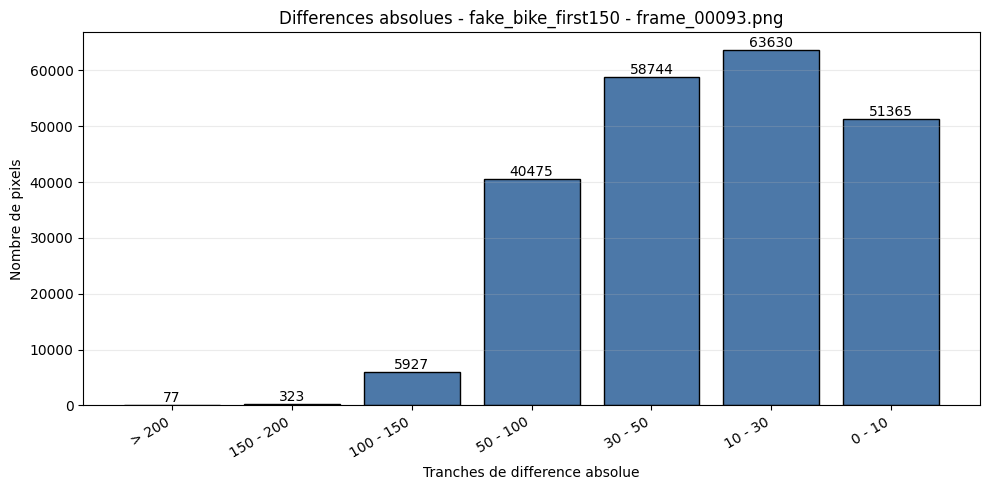

lvl:  4  initial error:  4641.750642673521


 error improvement too small, level converged! it:  6  error:  1427.1651301794964  lambda:  0.0
lvl:  3  initial error:  1670.6055730949176


 error improvement too small, level converged! it:  3  error:  1588.7426148306215  lambda:  0.0


lvl:  2  initial error:  1726.219075041204


 error improvement too small, level converged! it:  5  error:  1663.0095915537725  lambda:  0.0


[fake_bike_first150] frame 94 -> frame_00094.png | sum error = 386808288.00 | mean abs error = 31.6449 | valid pixels = 220541


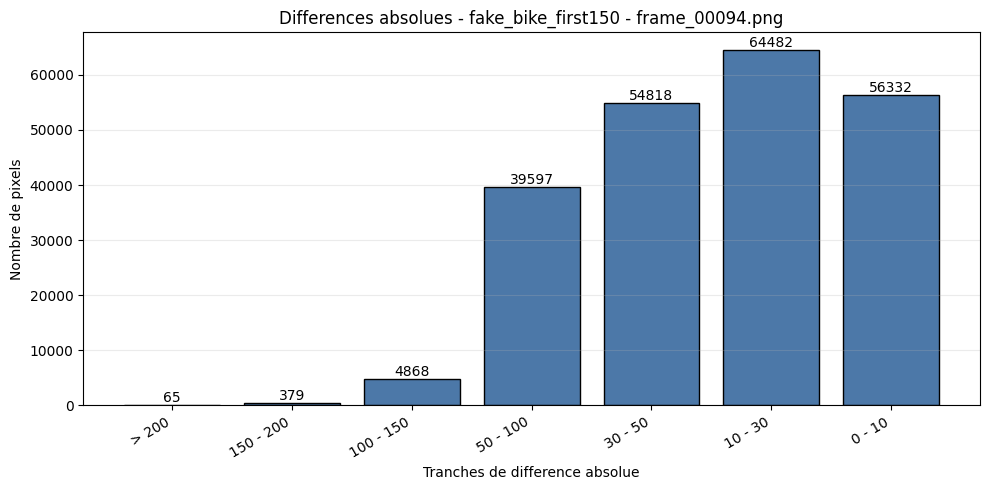

lvl:  4  initial error:  4802.3650385604105


 error improvement too small, level converged! it:  5  error:  1608.1422087952017  lambda:  0.1
lvl:  3  initial error:  1782.4546300903974


 error improvement too small, level converged! it:  6  error:  1617.5093141523403  lambda:  0.0


lvl:  2  initial error:  1603.7872977805062


 error improvement too small, level converged! it:  2  error:  1599.9329778023498  lambda:  0.0


[fake_bike_first150] frame 95 -> frame_00095.png | sum error = 378984288.00 | mean abs error = 31.8215 | valid pixels = 219380


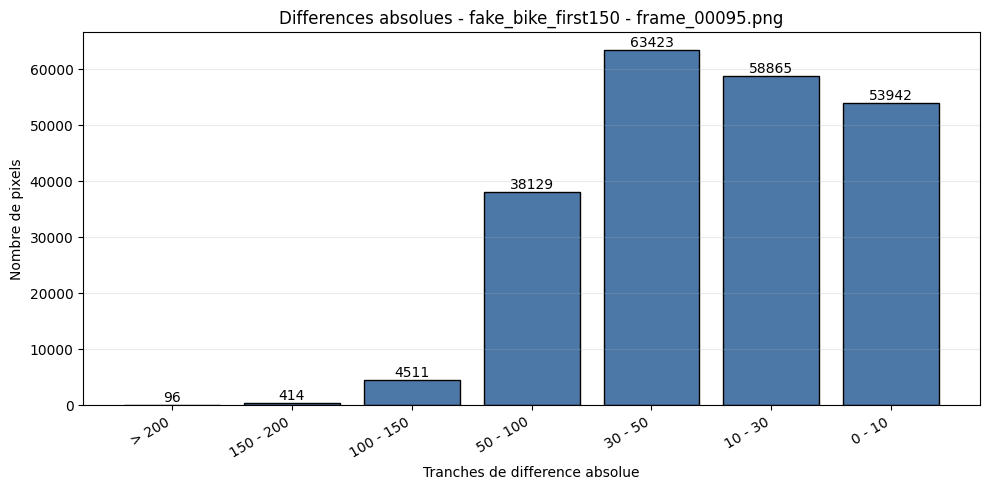

lvl:  4  initial error:  4692.659383033419
 error improvement too small, level converged! it:  4  error:  1837.7667563364034  lambda:  6.4
lvl:  3  initial error:  1828.9808373163892


 error improvement too small, level converged! it:  3  error:  1804.6053963462396  lambda:  0.0
lvl:  2  initial error:  1914.5581697347452


 error improvement too small, level converged! it:  3  error:  1894.3582804813202  lambda:  0.1


[fake_bike_first150] frame 96 -> frame_00096.png | sum error = 440613152.00 | mean abs error = 34.1080 | valid pixels = 219122


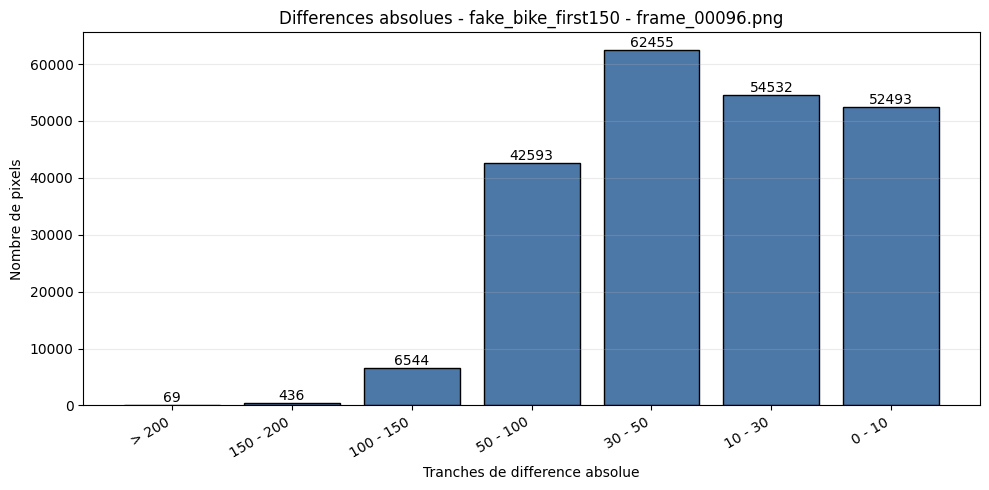

lvl:  4  initial error:  4427.899742930591


 error improvement too small, level converged! it:  4  error:  1860.035859855667  lambda:  0.2
lvl:  3  initial error:  1898.848559558034


 error improvement too small, level converged! it:  7  error:  1773.8422439469507  lambda:  0.0


lvl:  2  initial error:  2056.0091927966587


 error improvement too small, level converged! it:  19  error:  1827.3288040151297  lambda:  0.0


[fake_bike_first150] frame 97 -> frame_00097.png | sum error = 420494624.00 | mean abs error = 33.1955 | valid pixels = 219308


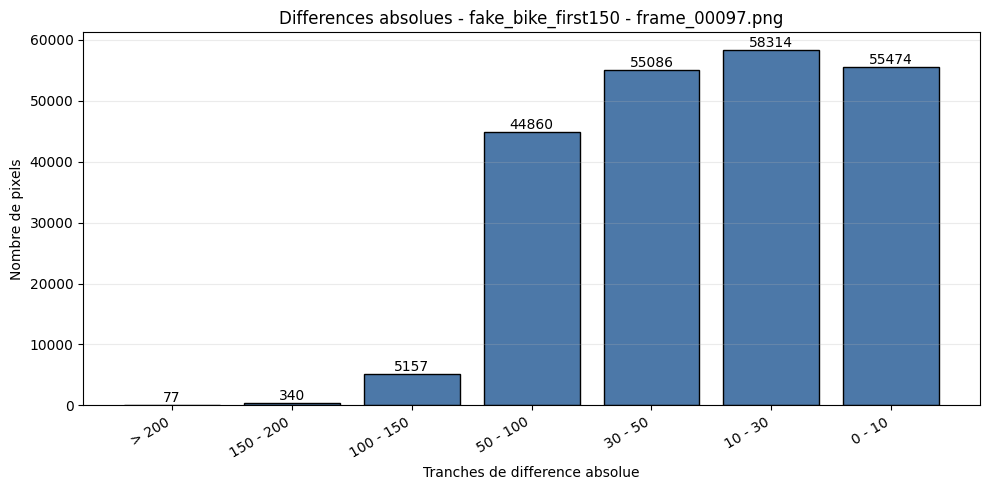

lvl:  4  initial error:  4528.023136246786


 error improvement too small, level converged! it:  5  error:  1672.570977307446  lambda:  0.2
lvl:  3  initial error:  2165.9060295571458


 error improvement too small, level converged! it:  22  error:  1791.0529246924007  lambda:  0.0
lvl:  2  initial error:  1911.5286689644313


 error improvement too small, level converged! it:  16  error:  1823.7600540339697  lambda:  0.0


[fake_bike_first150] frame 98 -> frame_00098.png | sum error = 435172224.00 | mean abs error = 34.5035 | valid pixels = 220541


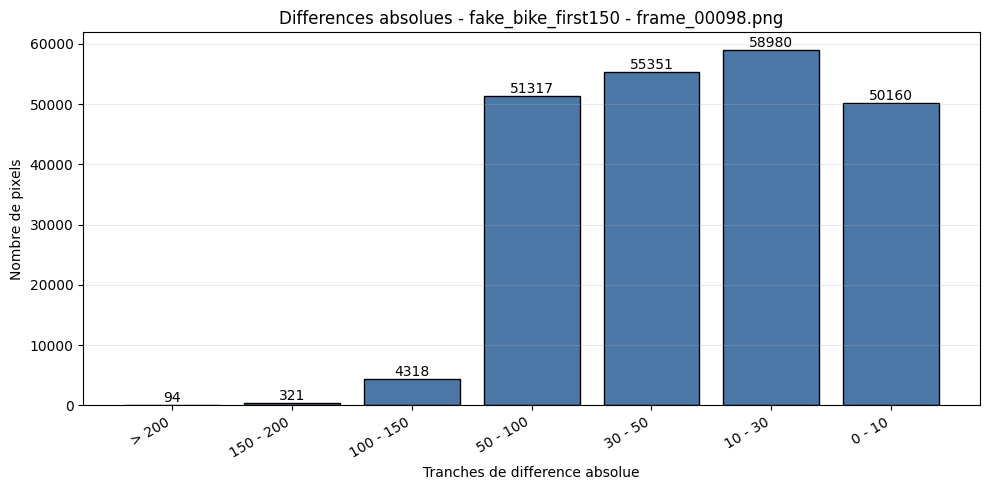

lvl:  4  initial error:  4380.368894601542


update too small, level converged! it:  4  error:  1679.9919886102282  lambda:  3602879701896397.0
lvl:  3  initial error:  1811.0864365047514


 error improvement too small, level converged! it:  8  error:  1638.7110871404554  lambda:  0.0
lvl:  2  initial error:  1729.7379343792102


 error improvement too small, level converged! it:  4  error:  1707.2591471052467  lambda:  0.0


[fake_bike_first150] frame 99 -> frame_00099.png | sum error = 400215392.00 | mean abs error = 32.9365 | valid pixels = 220541


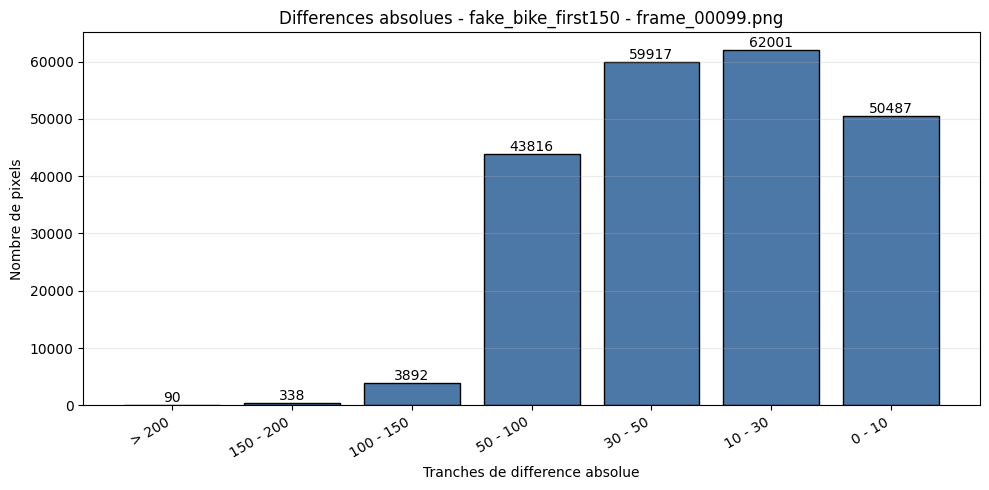

lvl:  4  initial error:  4121.804627249357


 error improvement too small, level converged! it:  5  error:  1610.357957368116  lambda:  6.4
lvl:  3  initial error:  1816.0933852810124


 error improvement too small, level converged! it:  8  error:  1693.6285579131375  lambda:  0.0


lvl:  2  initial error:  1749.765162960619


 error improvement too small, level converged! it:  3  error:  1735.1934604625415  lambda:  0.0


[fake_bike_first150] frame 100 -> frame_00100.png | sum error = 411790176.00 | mean abs error = 32.9621 | valid pixels = 218704


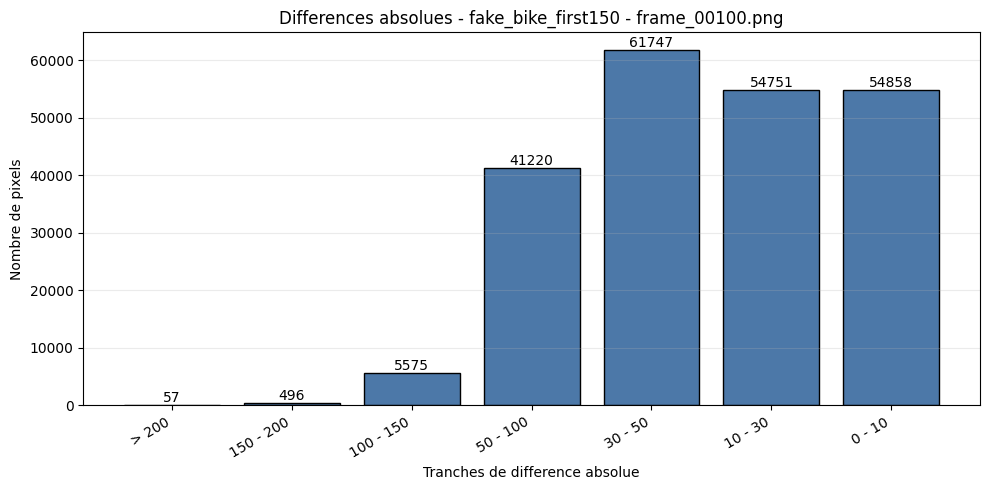

lvl:  4  initial error:  4295.177377892031


 error improvement too small, level converged! it:  5  error:  1871.0013465899915  lambda:  28147497671065.6
lvl:  3  initial error:  2126.5816893056553


 error improvement too small, level converged! it:  4  error:  2080.0176344000374  lambda:  0.0


lvl:  2  initial error:  2157.009293689612


 error improvement too small, level converged! it:  12  error:  2092.07429321299  lambda:  0.0


[fake_bike_first150] frame 101 -> frame_00101.png | sum error = 489221120.00 | mean abs error = 36.8580 | valid pixels = 218102


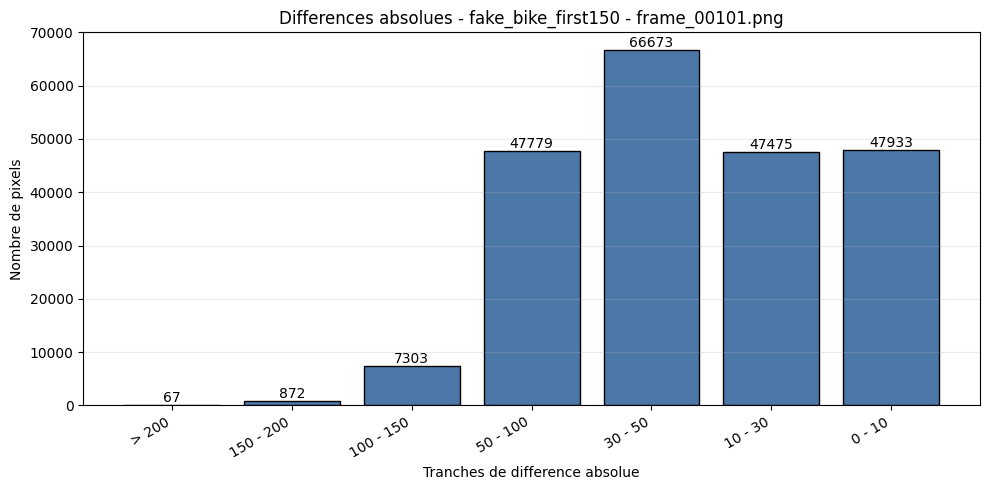

lvl:  4  initial error:  4379.668380462725


 error improvement too small, level converged! it:  5  error:  1768.1541327975926  lambda:  0.2
lvl:  3  initial error:  2179.6401688854867


 error improvement too small, level converged! it:  8  error:  2033.3339593092617  lambda:  0.0


lvl:  2  initial error:  2071.580148267357


 error improvement too small, level converged! it:  6  error:  2052.4892850867973  lambda:  0.0


[fake_bike_first150] frame 102 -> frame_00102.png | sum error = 475887808.00 | mean abs error = 36.3198 | valid pixels = 217400


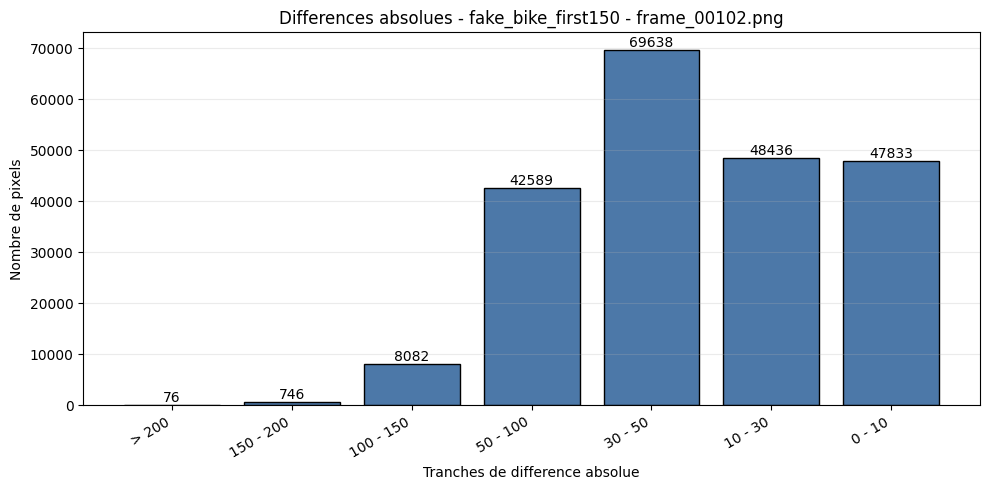

lvl:  4  initial error:  4379.06940874036


 error improvement too small, level converged! it:  4  error:  2043.1610726756676  lambda:  102.4
lvl:  3  initial error:  2154.655877963956


 error improvement too small, level converged! it:  10  error:  1928.3767191549832  lambda:  0.0


lvl:  2  initial error:  1981.3362599855543


 error improvement too small, level converged! it:  6  error:  1947.7853395897234  lambda:  0.0


[fake_bike_first150] frame 103 -> frame_00103.png | sum error = 461768576.00 | mean abs error = 35.8201 | valid pixels = 219049


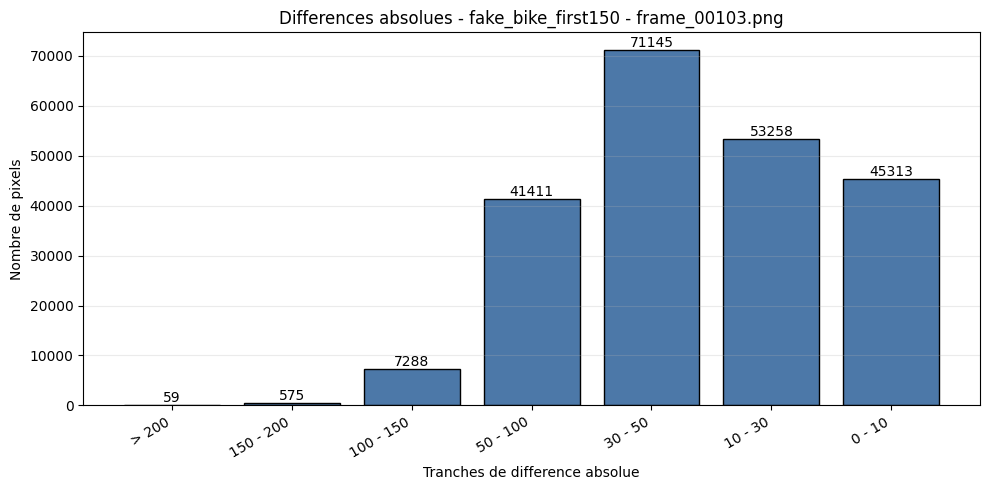

lvl:  4  initial error:  4210.595115681234


 error improvement too small, level converged! it:  15  error:  1837.3077245662116  lambda:  0.0
lvl:  3  initial error:  1868.5603085051778


 error improvement too small, level converged! it:  12  error:  1624.9047972084745  lambda:  0.0


lvl:  2  initial error:  1700.1210939714865


 error improvement too small, level converged! it:  7  error:  1670.7193147876765  lambda:  0.0


[fake_bike_first150] frame 104 -> frame_00104.png | sum error = 401339616.00 | mean abs error = 32.7294 | valid pixels = 219814


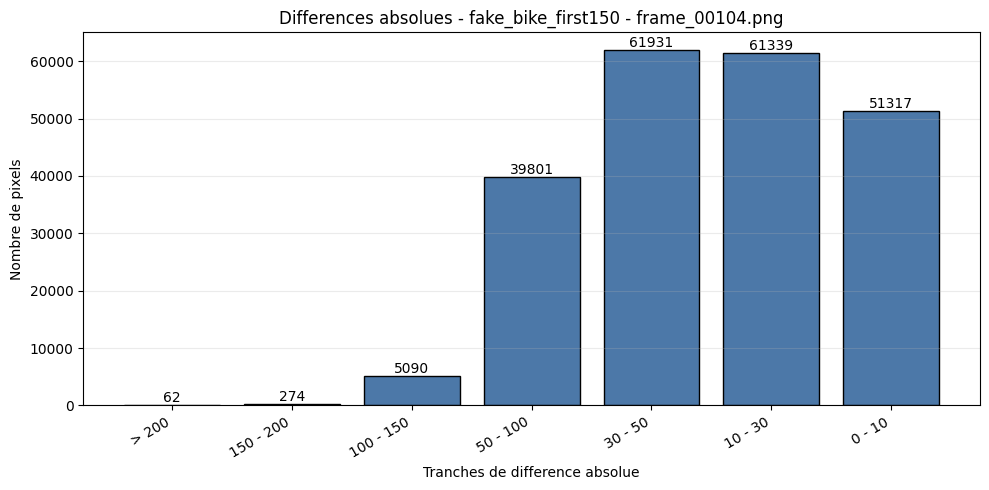

lvl:  4  initial error:  3862.3727506426735


 error improvement too small, level converged! it:  10  error:  1795.3988197771862  lambda:  28147497671065.6
lvl:  3  initial error:  1830.5883676384442


 error improvement too small, level converged! it:  19  error:  1532.5472377256035  lambda:  0.0


lvl:  2  initial error:  1646.1280825938873


 error improvement too small, level converged! it:  4  error:  1623.3985971832205  lambda:  0.0


[fake_bike_first150] frame 105 -> frame_00105.png | sum error = 382519168.00 | mean abs error = 31.5617 | valid pixels = 220541


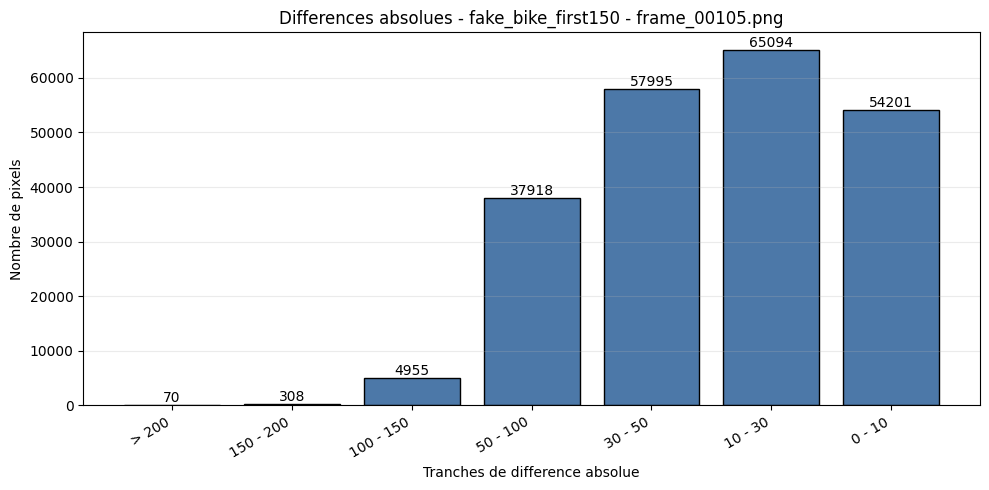

lvl:  4  initial error:  3932.512853470437


 error improvement too small, level converged! it:  6  error:  1779.2555385253236  lambda:  0.1
lvl:  3  initial error:  1626.6682063306785


 error improvement too small, level converged! it:  4  error:  1570.6775590036473  lambda:  0.0


lvl:  2  initial error:  1675.5285659094025


 error improvement too small, level converged! it:  7  error:  1604.695747513437  lambda:  0.0


[fake_bike_first150] frame 106 -> frame_00106.png | sum error = 385591328.00 | mean abs error = 31.2660 | valid pixels = 220541


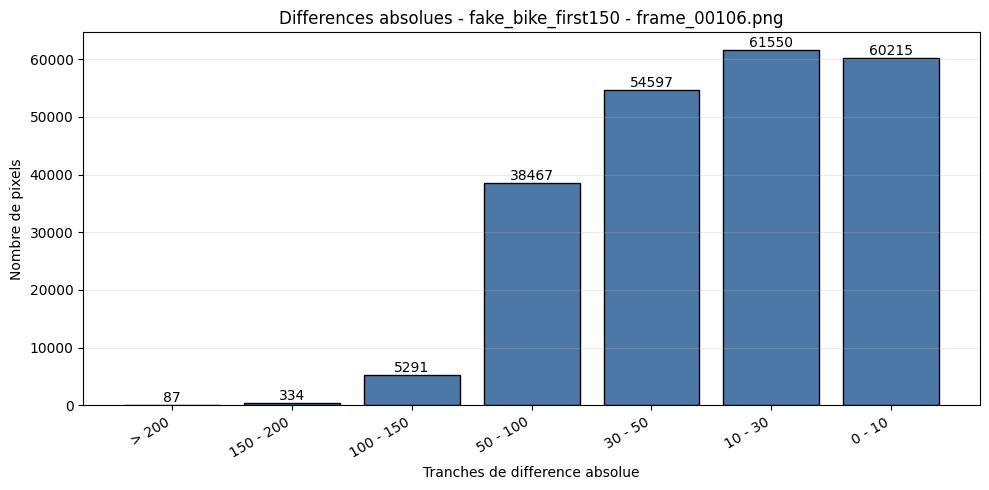

lvl:  4  initial error:  3940.9511568123394


update too small, level converged! it:  5  error:  1940.3260004572858  lambda:  3602879701896397.0
lvl:  3  initial error:  1827.832472190513


 error improvement too small, level converged! it:  15  error:  1620.121829162055  lambda:  0.0


lvl:  2  initial error:  1717.653216898063


 error improvement too small, level converged! it:  3  error:  1696.0260726262184  lambda:  0.0


[fake_bike_first150] frame 107 -> frame_00107.png | sum error = 409638272.00 | mean abs error = 32.5632 | valid pixels = 220541


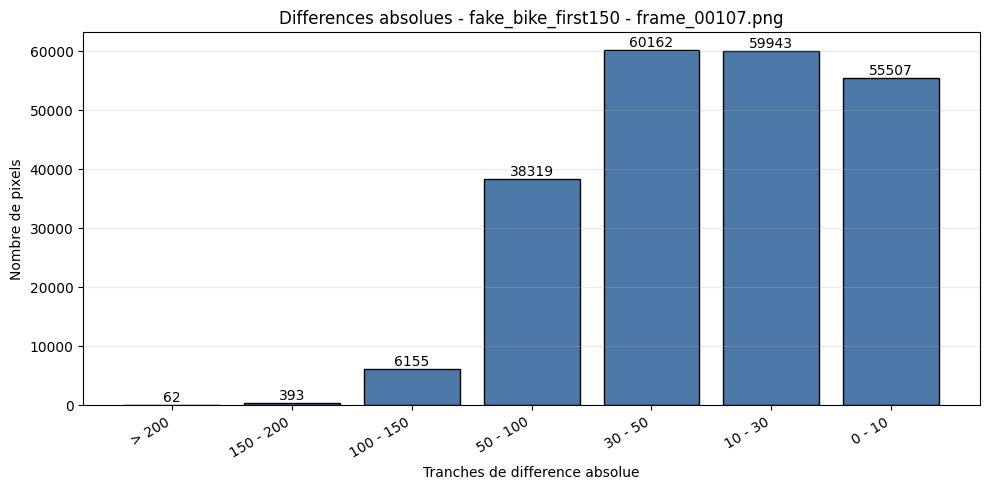

lvl:  4  initial error:  4126.501285347043


 error improvement too small, level converged! it:  6  error:  1947.6895027921835  lambda:  0.8
lvl:  3  initial error:  1942.2969972742203


 error improvement too small, level converged! it:  10  error:  1774.2643811485843  lambda:  0.0


lvl:  2  initial error:  1863.2520242182711


 error improvement too small, level converged! it:  2  error:  1854.3667238733779  lambda:  0.0


[fake_bike_first150] frame 108 -> frame_00108.png | sum error = 441845408.00 | mean abs error = 34.0950 | valid pixels = 220409


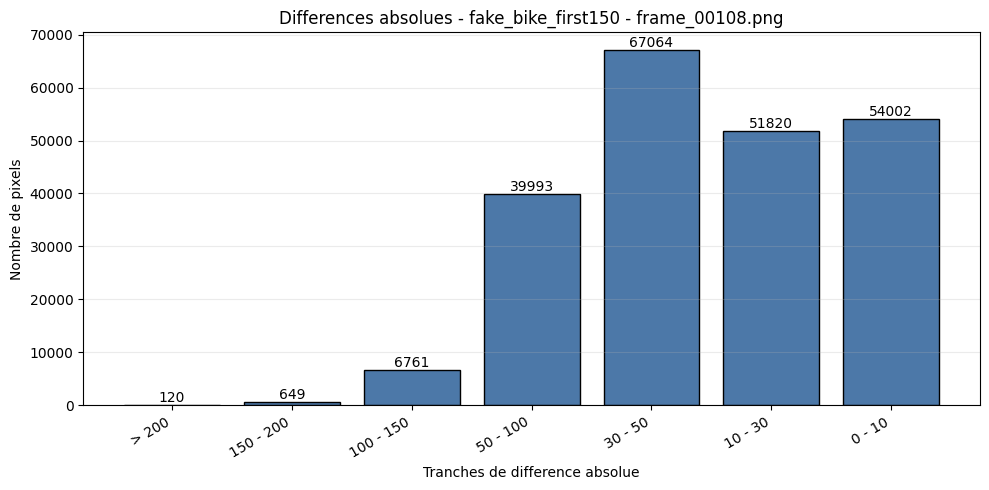

lvl:  4  initial error:  4159.66323907455
 error improvement too small, level converged! it:  3  error:  1838.641663420714  lambda:  0.0


lvl:  3  initial error:  2231.023221857401


 error improvement too small, level converged! it:  6  error:  1919.2257620387547  lambda:  0.0


lvl:  2  initial error:  1989.7518774029677


 error improvement too small, level converged! it:  3  error:  1950.78328710743  lambda:  0.0


[fake_bike_first150] frame 109 -> frame_00109.png | sum error = 462216096.00 | mean abs error = 35.7020 | valid pixels = 220200


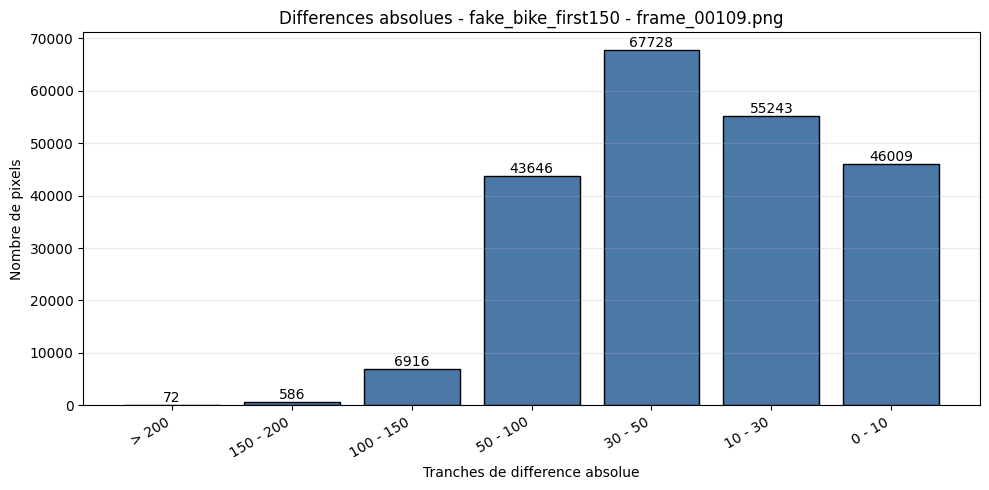

lvl:  4  initial error:  3926.892030848329


 error improvement too small, level converged! it:  4  error:  1748.300056523987  lambda:  28147497671065.6
lvl:  3  initial error:  2023.4368643053726


 error improvement too small, level converged! it:  6  error:  1863.4926494672634  lambda:  0.0


lvl:  2  initial error:  1986.259425125237


 error improvement too small, level converged! it:  5  error:  1953.8946691681524  lambda:  0.4


[fake_bike_first150] frame 110 -> frame_00110.png | sum error = 459464640.00 | mean abs error = 35.2899 | valid pixels = 220106


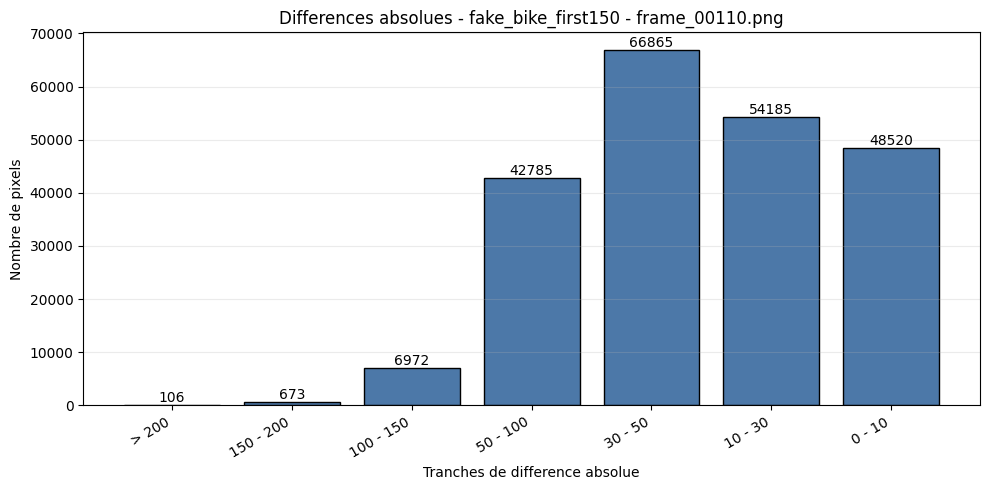

lvl:  4  initial error:  3945.547557840617


 error improvement too small, level converged! it:  4  error:  1740.2965650285103  lambda:  0.0
lvl:  3  initial error:  2074.6665495820175


 error improvement too small, level converged! it:  11  error:  1748.214347670826  lambda:  0.0


lvl:  2  initial error:  1857.1197554068658


 error improvement too small, level converged! it:  3  error:  1840.8715720554771  lambda:  219902325555.2


[fake_bike_first150] frame 111 -> frame_00111.png | sum error = 428570400.00 | mean abs error = 33.7751 | valid pixels = 220541


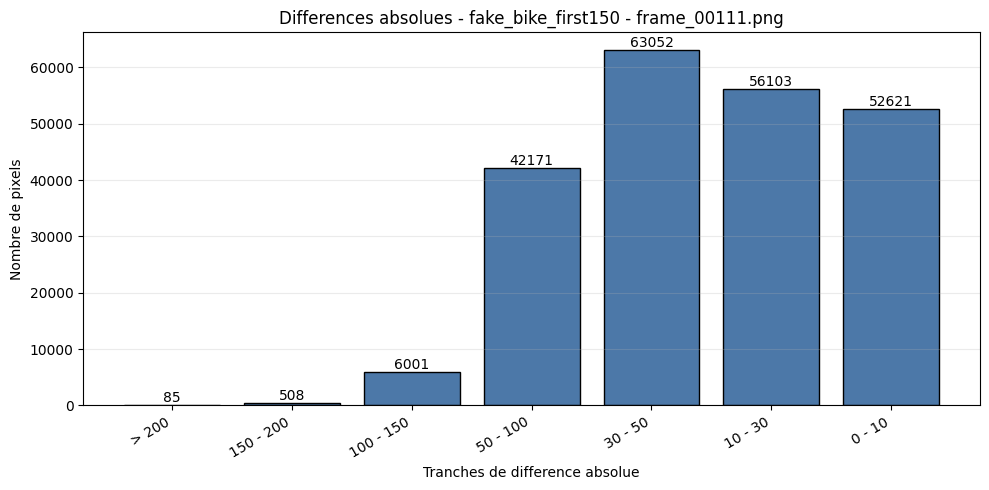

lvl:  4  initial error:  3696.964010282776


 error improvement too small, level converged! it:  6  error:  1678.8093166251906  lambda:  0.1
lvl:  3  initial error:  2036.2270185848054


 error improvement too small, level converged! it:  11  error:  1854.1520330835888  lambda:  0.0


lvl:  2  initial error:  1924.527181825127


 error improvement too small, level converged! it:  9  error:  1854.7448365023802  lambda:  0.0


[fake_bike_first150] frame 112 -> frame_00112.png | sum error = 442039776.00 | mean abs error = 34.0653 | valid pixels = 220541


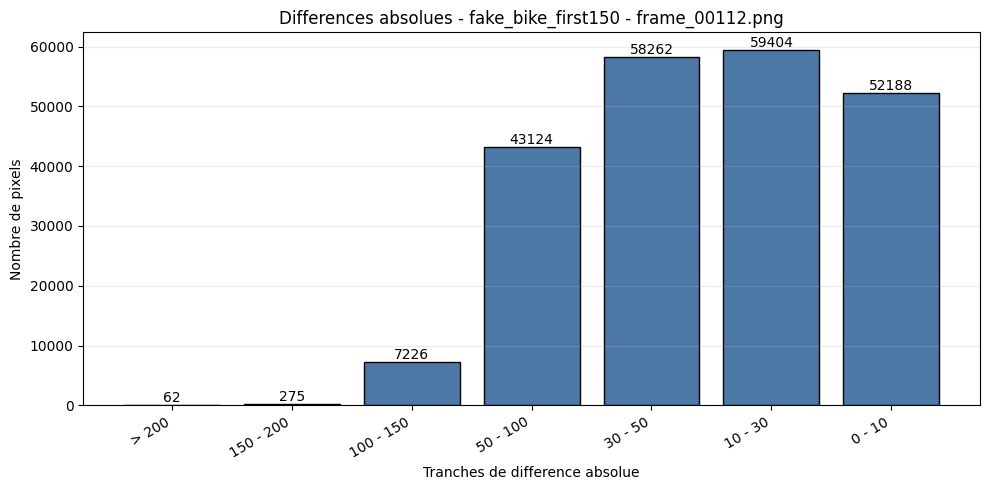

lvl:  4  initial error:  3742.3431876606683


 error improvement too small, level converged! it:  10  error:  1516.5065429703816  lambda:  0.0
lvl:  3  initial error:  1671.114799879478


update too small, level converged! it:  3  error:  1595.4669779521305  lambda:  450359962737049.6


lvl:  2  initial error:  1721.9355206703106


 error improvement too small, level converged! it:  5  error:  1670.8770734102636  lambda:  0.0


[fake_bike_first150] frame 113 -> frame_00113.png | sum error = 383664032.00 | mean abs error = 32.2431 | valid pixels = 220541


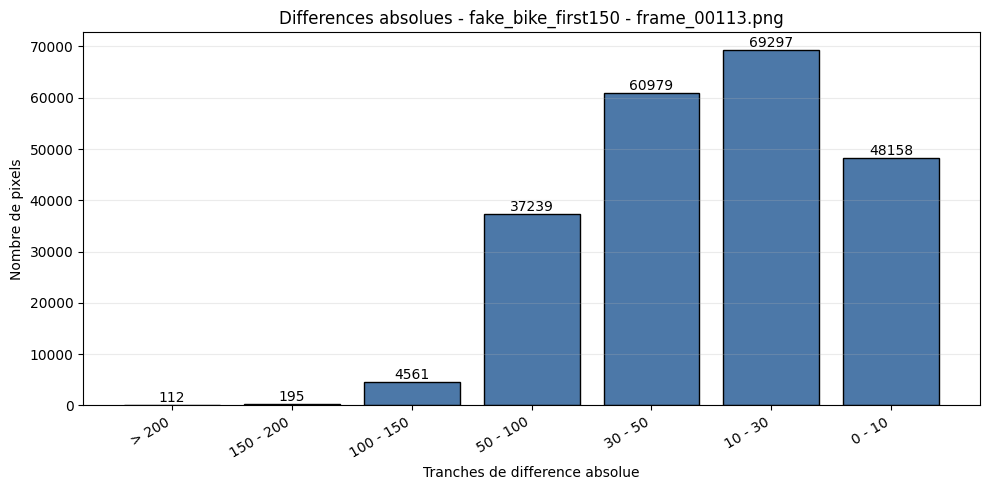

lvl:  4  initial error:  3863.0231362467866


 error improvement too small, level converged! it:  4  error:  1553.5791528724942  lambda:  3.2
lvl:  3  initial error:  1727.2038216288897


 error improvement too small, level converged! it:  6  error:  1695.0549884952798  lambda:  0.0


lvl:  2  initial error:  1767.597110074077


 error improvement too small, level converged! it:  7  error:  1723.7922651060264  lambda:  0.0


[fake_bike_first150] frame 114 -> frame_00114.png | sum error = 401531616.00 | mean abs error = 32.8479 | valid pixels = 220541


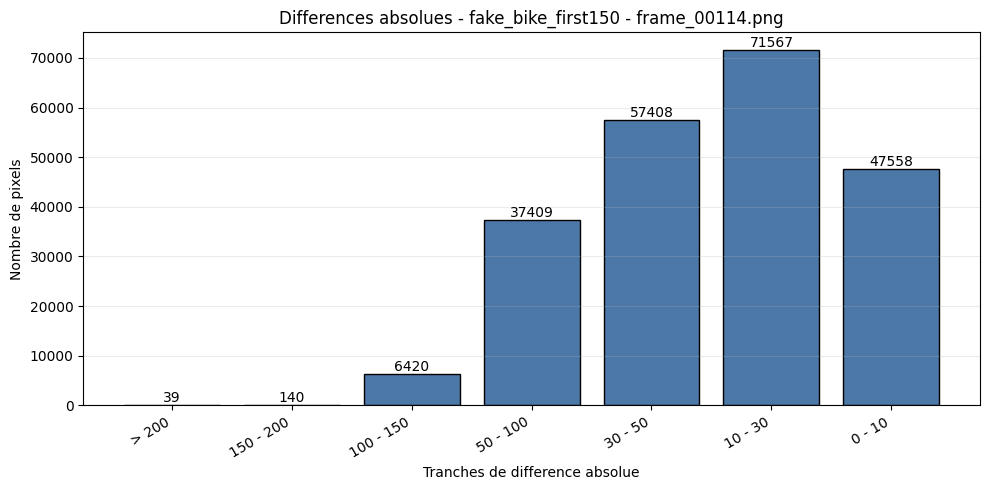

lvl:  4  initial error:  3921.4151670951155


 error improvement too small, level converged! it:  4  error:  1678.1114882951476  lambda:  0.1
lvl:  3  initial error:  1837.816534196275


 error improvement too small, level converged! it:  5  error:  1775.7120195304449  lambda:  0.0


lvl:  2  initial error:  1818.984524904587


 error improvement too small, level converged! it:  7  error:  1784.3333351652786  lambda:  0.0


[fake_bike_first150] frame 115 -> frame_00115.png | sum error = 410442944.00 | mean abs error = 33.2059 | valid pixels = 220541


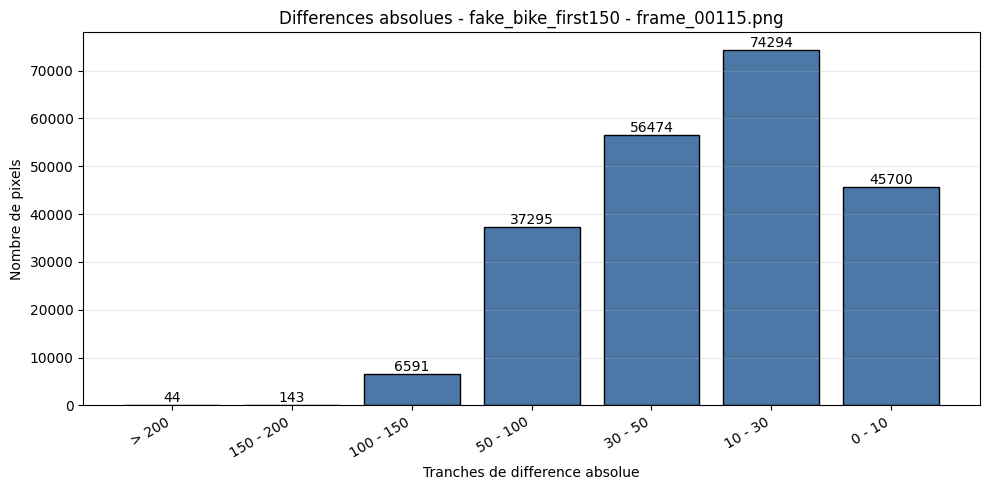

lvl:  4  initial error:  3960.9755784061695


 error improvement too small, level converged! it:  3  error:  1753.712218056811  lambda:  56294995342131.2
lvl:  3  initial error:  1844.106819529818


 error improvement too small, level converged! it:  3  error:  1812.905935459532  lambda:  0.0
lvl:  2  initial error:  1881.145815202846


 error improvement too small, level converged! it:  5  error:  1854.0027808085206  lambda:  0.0


[fake_bike_first150] frame 116 -> frame_00116.png | sum error = 425276896.00 | mean abs error = 33.3985 | valid pixels = 220541


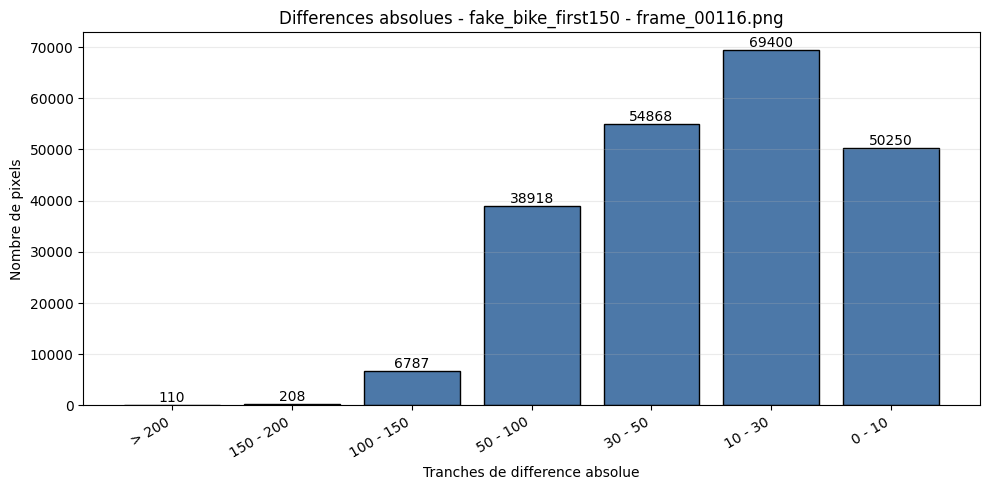

lvl:  4  initial error:  4051.287917737789


 error improvement too small, level converged! it:  5  error:  1801.456886263934  lambda:  879609302220.8
lvl:  3  initial error:  1892.833089756762


 error improvement too small, level converged! it:  4  error:  1869.3195777870012  lambda:  0.0


lvl:  2  initial error:  1910.1370542971567


 error improvement too small, level converged! it:  6  error:  1866.2013333256841  lambda:  0.0


[fake_bike_first150] frame 117 -> frame_00117.png | sum error = 428720960.00 | mean abs error = 34.0482 | valid pixels = 220541


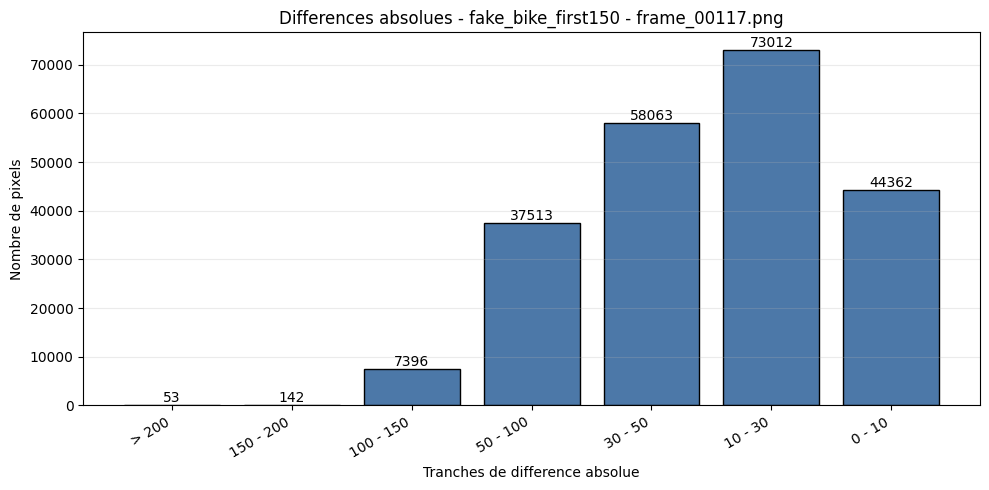

lvl:  4  initial error:  4130.194087403599


 error improvement too small, level converged! it:  4  error:  1769.8983787085401  lambda:  0.2
lvl:  3  initial error:  1885.8387177087407


 error improvement too small, level converged! it:  6  error:  1864.153764448029  lambda:  0.0


lvl:  2  initial error:  1915.8187747644902


 error improvement too small, level converged! it:  5  error:  1882.4103724745378  lambda:  0.0


[fake_bike_first150] frame 118 -> frame_00118.png | sum error = 433697632.00 | mean abs error = 34.2613 | valid pixels = 220541


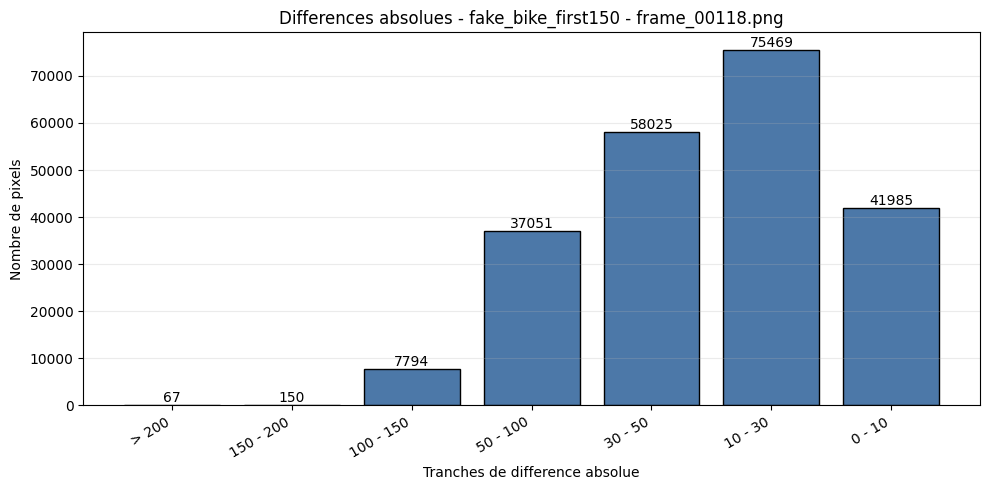

lvl:  4  initial error:  4138.349614395887


 error improvement too small, level converged! it:  4  error:  1896.2498194097573  lambda:  1.6
lvl:  3  initial error:  1968.9157616578577


 error improvement too small, level converged! it:  7  error:  1812.1209936240232  lambda:  0.1


lvl:  2  initial error:  1864.6875121394633


 error improvement too small, level converged! it:  2  error:  1855.3274566497464  lambda:  0.0


[fake_bike_first150] frame 119 -> frame_00119.png | sum error = 431530816.00 | mean abs error = 34.3483 | valid pixels = 220541


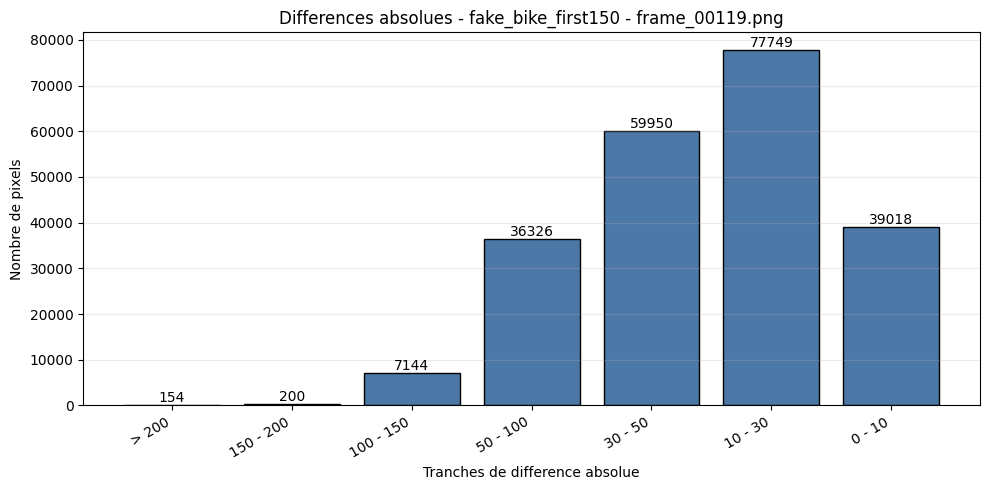

lvl:  4  initial error:  4147.3894601542415


 error improvement too small, level converged! it:  4  error:  1888.799344350106  lambda:  0.4
lvl:  3  initial error:  2063.3527565109084


 error improvement too small, level converged! it:  17  error:  1797.09679379394  lambda:  0.0
lvl:  2  initial error:  1888.3843973912624


 error improvement too small, level converged! it:  6  error:  1827.8790342425848  lambda:  0.0


[fake_bike_first150] frame 120 -> frame_00120.png | sum error = 429844320.00 | mean abs error = 34.6907 | valid pixels = 220541


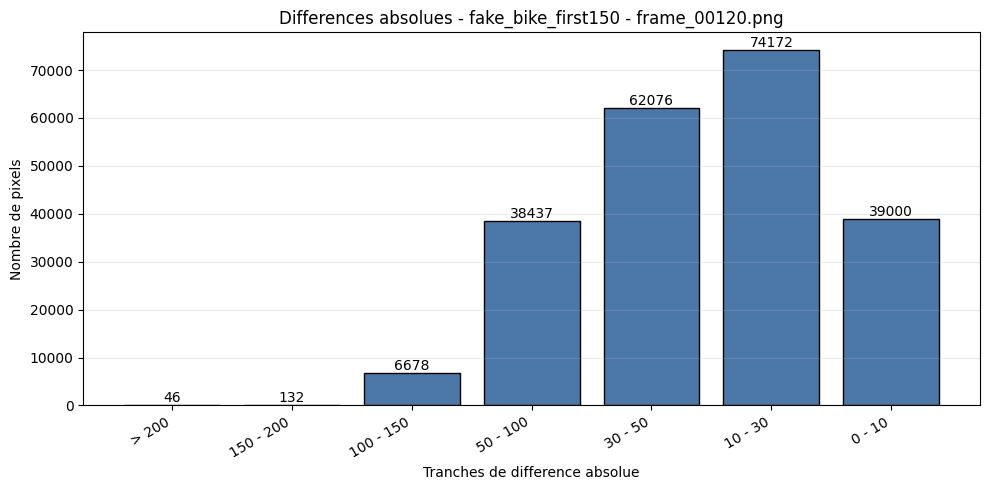

lvl:  4  initial error:  3929.739074550128


 error improvement too small, level converged! it:  4  error:  2081.8967839394995  lambda:  7036874417766.4
lvl:  3  initial error:  2087.925391141882


 error improvement too small, level converged! it:  8  error:  1971.2327642700384  lambda:  0.0


lvl:  2  initial error:  2079.80505840759


 error improvement too small, level converged! it:  6  error:  2058.7887346697257  lambda:  0.8


[fake_bike_first150] frame 121 -> frame_00121.png | sum error = 483569824.00 | mean abs error = 36.5740 | valid pixels = 220541


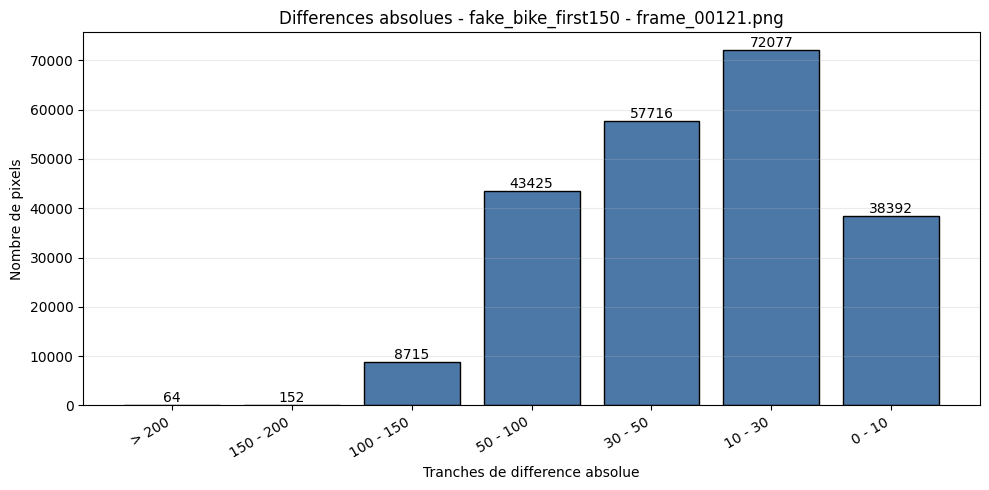

lvl:  4  initial error:  3913.8920308483284


 error improvement too small, level converged! it:  8  error:  1832.8584581566165  lambda:  0.0
lvl:  3  initial error:  2040.3312552559946


 error improvement too small, level converged! it:  11  error:  1975.0309401221732  lambda:  0.0


lvl:  2  initial error:  2036.9395682195216


 error improvement too small, level converged! it:  6  error:  1986.5579115753108  lambda:  0.0


[fake_bike_first150] frame 122 -> frame_00122.png | sum error = 478739712.00 | mean abs error = 36.4687 | valid pixels = 220541


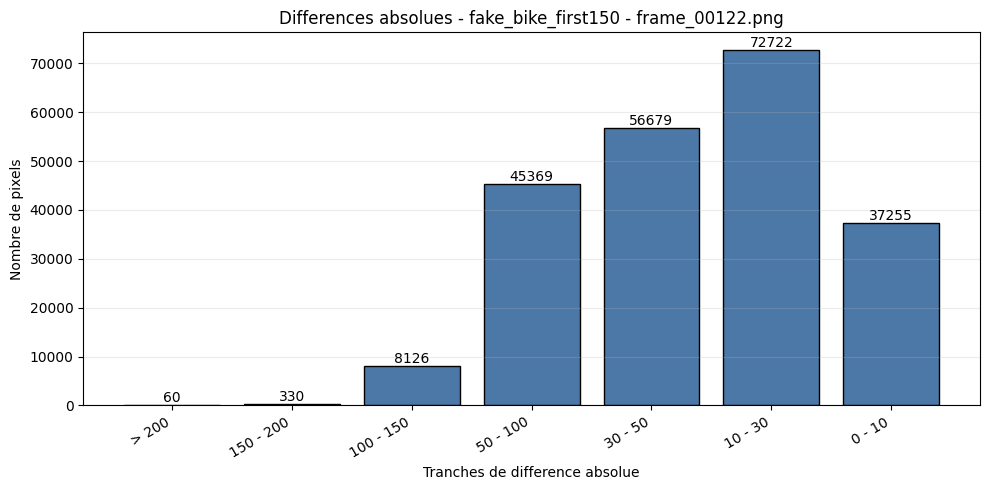

lvl:  4  initial error:  3932.991002570694


update too small, level converged! it:  4  error:  2010.8257314275074  lambda:  3602879701896397.0
lvl:  3  initial error:  2093.6857779408456


 error improvement too small, level converged! it:  10  error:  1970.9242062961432  lambda:  0.0


lvl:  2  initial error:  2117.7930511978625


 error improvement too small, level converged! it:  9  error:  2064.893154200442  lambda:  0.0


[fake_bike_first150] frame 123 -> frame_00123.png | sum error = 489385632.00 | mean abs error = 36.5320 | valid pixels = 220541


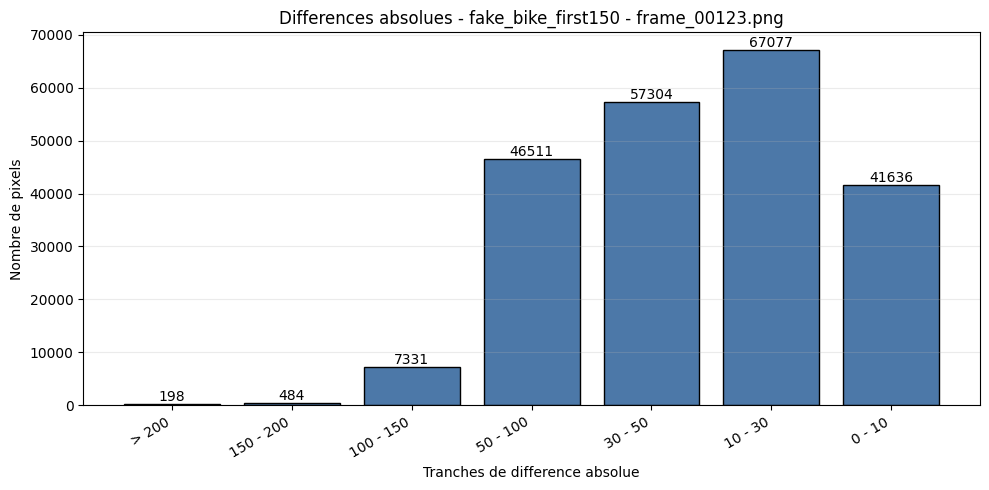

lvl:  4  initial error:  4017.670951156811


 error improvement too small, level converged! it:  4  error:  2066.4797249515354  lambda:  112589990684262.4
lvl:  3  initial error:  2150.6137497461223


update too small, level converged! it:  5  error:  2083.4322876161586  lambda:  1801439850948198.5


lvl:  2  initial error:  2235.0609846870234


 error improvement too small, level converged! it:  2  error:  2226.0505907645625  lambda:  0.1


[fake_bike_first150] frame 124 -> frame_00124.png | sum error = 523865696.00 | mean abs error = 38.0514 | valid pixels = 220251


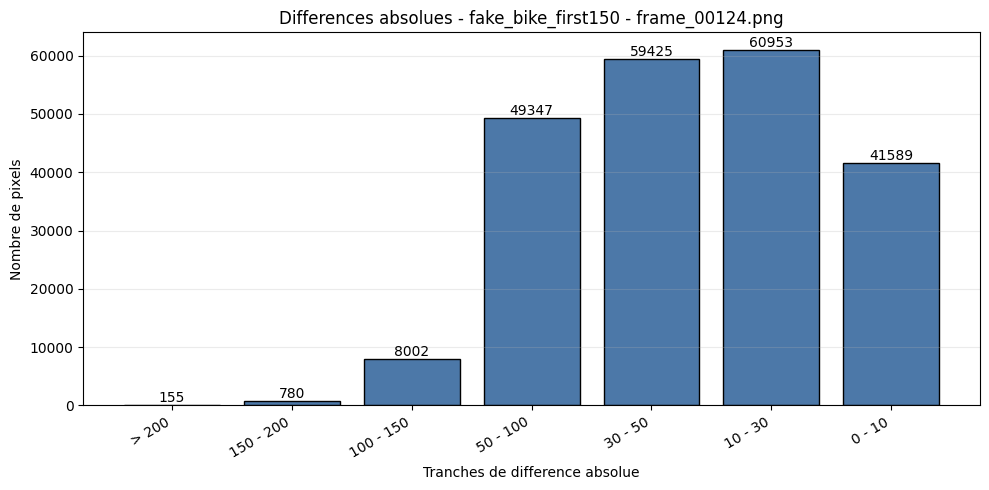

lvl:  4  initial error:  4200.338046272493


 error improvement too small, level converged! it:  9  error:  2142.501486615745  lambda:  112589990684262.4
lvl:  3  initial error:  2191.398403957465


 error improvement too small, level converged! it:  4  error:  2140.832626333148  lambda:  0.2


lvl:  2  initial error:  2312.8111624234166


 error improvement too small, level converged! it:  7  error:  2225.3652713100996  lambda:  0.0


[fake_bike_first150] frame 125 -> frame_00125.png | sum error = 522542496.00 | mean abs error = 38.2146 | valid pixels = 219434


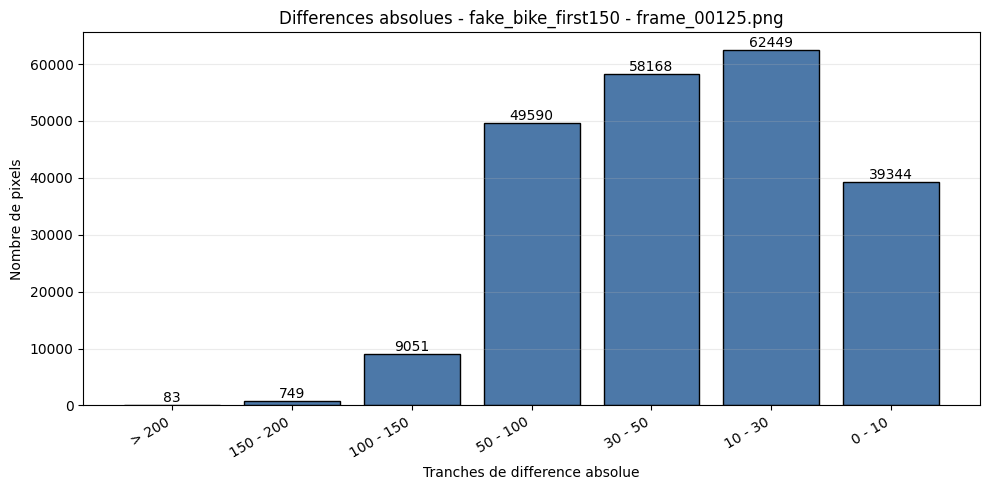

lvl:  4  initial error:  4326.985861182519


 error improvement too small, level converged! it:  5  error:  2148.1664997128346  lambda:  14073748835532.8
lvl:  3  initial error:  2320.807907534984


 error improvement too small, level converged! it:  10  error:  2214.215461953072  lambda:  0.0


lvl:  2  initial error:  2298.8744044856735


 error improvement too small, level converged! it:  2  error:  2296.281115354184  lambda:  6.4


[fake_bike_first150] frame 126 -> frame_00126.png | sum error = 530652960.00 | mean abs error = 38.5877 | valid pixels = 219041


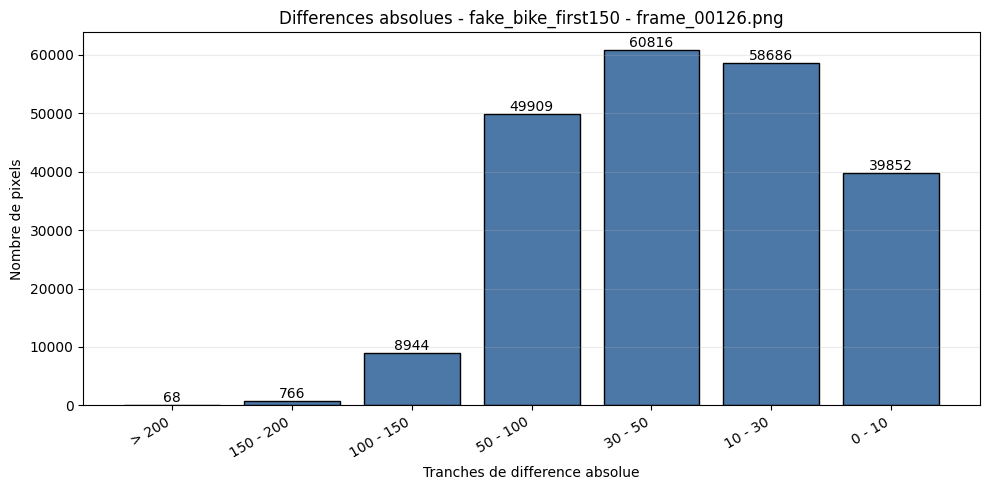

lvl:  4  initial error:  4024.910025706941


 error improvement too small, level converged! it:  6  error:  2013.9586398065187  lambda:  219902325555.2
lvl:  3  initial error:  2171.3838061563283


 error improvement too small, level converged! it:  2  error:  2163.187702769013  lambda:  0.4


lvl:  2  initial error:  2343.534722188965


 error improvement too small, level converged! it:  5  error:  2300.0586163657495  lambda:  0.0


[fake_bike_first150] frame 127 -> frame_00127.png | sum error = 530461952.00 | mean abs error = 38.3831 | valid pixels = 219018


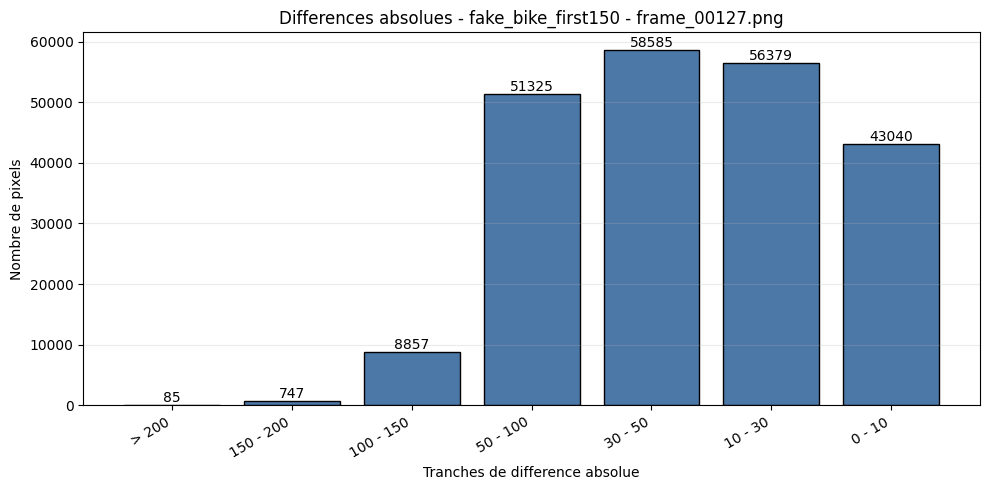

lvl:  4  initial error:  4046.532133676092


 error improvement too small, level converged! it:  4  error:  1979.3464734809638  lambda:  28147497671065.6
lvl:  3  initial error:  2161.716706087102


 error improvement too small, level converged! it:  2  error:  2133.165913873439  lambda:  28147497671065.6


lvl:  2  initial error:  2355.262482040176


 error improvement too small, level converged! it:  5  error:  2320.402565283772  lambda:  0.0


[fake_bike_first150] frame 128 -> frame_00128.png | sum error = 535199360.00 | mean abs error = 38.6129 | valid pixels = 219136


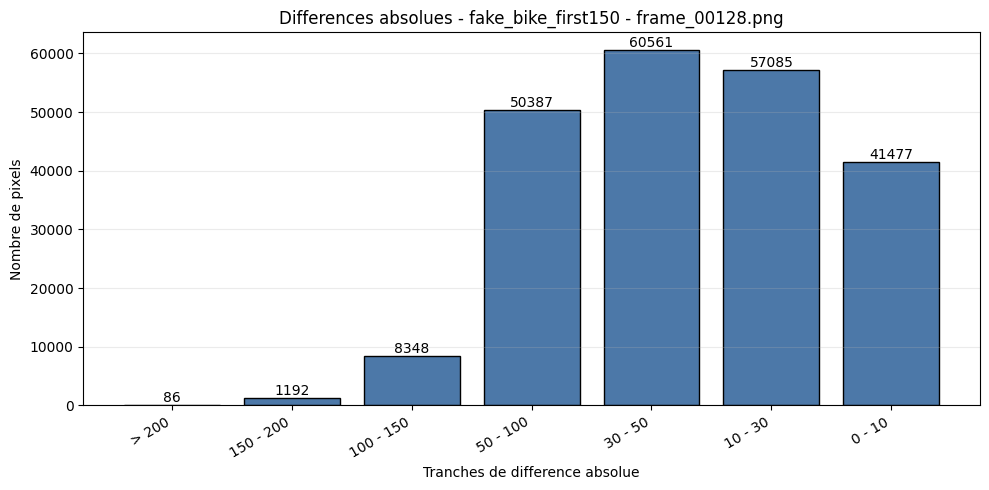

lvl:  4  initial error:  4046.86503856041


 error improvement too small, level converged! it:  4  error:  2003.0647051705557  lambda:  6.4
lvl:  3  initial error:  2315.23881603581


 error improvement too small, level converged! it:  10  error:  2192.2944687140775  lambda:  0.0


lvl:  2  initial error:  2344.70193955059


 error improvement too small, level converged! it:  2  error:  2335.582742919798  lambda:  0.0


[fake_bike_first150] frame 129 -> frame_00129.png | sum error = 543862720.00 | mean abs error = 39.4440 | valid pixels = 219456


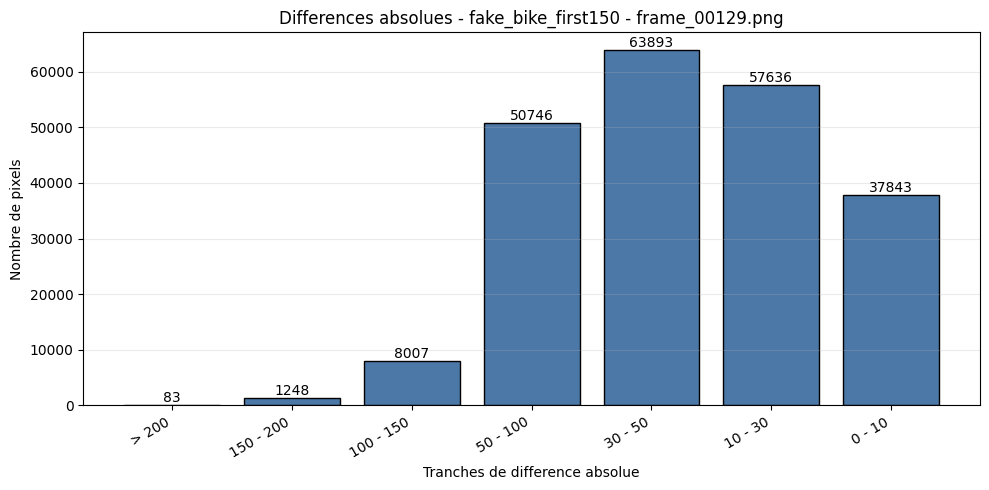

lvl:  4  initial error:  3902.1928020565542
 error improvement too small, level converged! it:  2  error:  2054.233836354632  lambda:  0.2


lvl:  3  initial error:  2277.6586542501304


 error improvement too small, level converged! it:  9  error:  2174.3182322653292  lambda:  0.0


lvl:  2  initial error:  2357.891584366367


 error improvement too small, level converged! it:  2  error:  2354.648674937036  lambda:  0.0


[fake_bike_first150] frame 130 -> frame_00130.png | sum error = 544024384.00 | mean abs error = 39.1004 | valid pixels = 219877


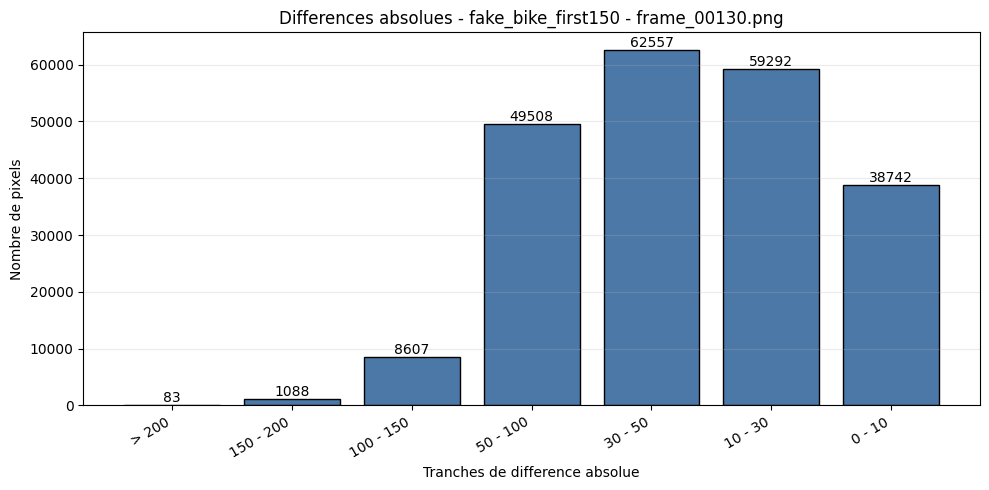

lvl:  4  initial error:  3735.87532133676


 error improvement too small, level converged! it:  4  error:  1956.2444892095732  lambda:  1.6
lvl:  3  initial error:  2228.36296644319


 error improvement too small, level converged! it:  3  error:  2203.8305938359204  lambda:  0.0


lvl:  2  initial error:  2260.2454944120423


 error improvement too small, level converged! it:  17  error:  2182.773751237652  lambda:  0.0


[fake_bike_first150] frame 131 -> frame_00131.png | sum error = 510060448.00 | mean abs error = 37.6817 | valid pixels = 220012


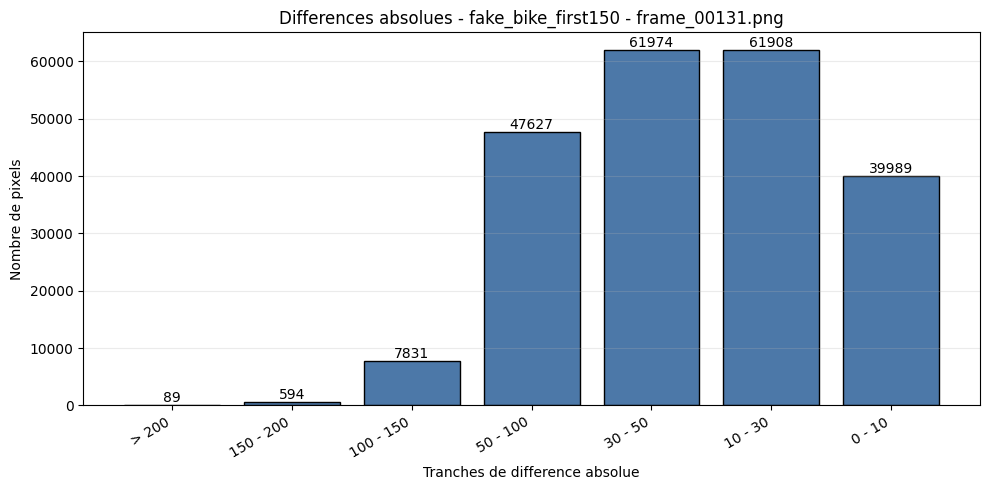

lvl:  4  initial error:  3495.329048843187


 error improvement too small, level converged! it:  6  error:  1743.2814257420948  lambda:  0.4
lvl:  3  initial error:  2198.752589073815


 error improvement too small, level converged! it:  7  error:  2069.054681809816  lambda:  0.0


lvl:  2  initial error:  2138.6797589750363


 error improvement too small, level converged! it:  5  error:  2122.0257861767523  lambda:  0.0


[fake_bike_first150] frame 132 -> frame_00132.png | sum error = 491406464.00 | mean abs error = 36.7171 | valid pixels = 220118


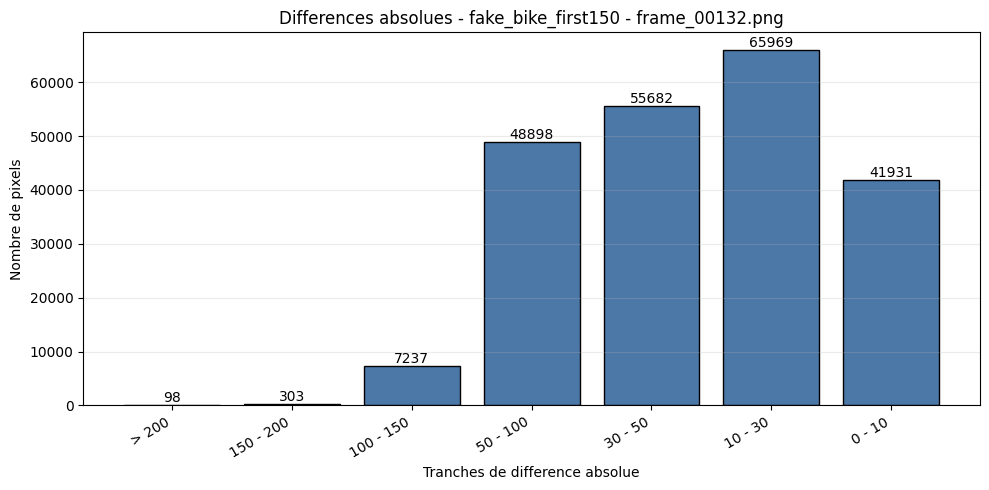

lvl:  4  initial error:  3647.0951156812334


 error improvement too small, level converged! it:  4  error:  1895.3840983199887  lambda:  0.4
lvl:  3  initial error:  2055.72774663448


 error improvement too small, level converged! it:  1  error:  2054.9862939591894  lambda:  0.0


lvl:  2  initial error:  2104.2130952161274


 error improvement too small, level converged! it:  3  error:  2090.292521986381  lambda:  0.0


[fake_bike_first150] frame 133 -> frame_00133.png | sum error = 504454336.00 | mean abs error = 37.4665 | valid pixels = 220541


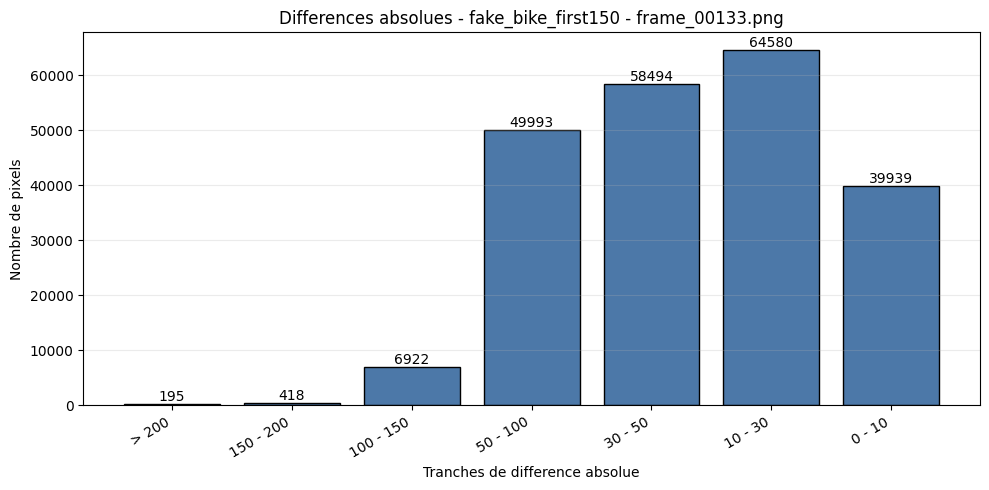

lvl:  4  initial error:  3891.057840616966


 error improvement too small, level converged! it:  6  error:  1857.4823594628274  lambda:  112589990684262.4
lvl:  3  initial error:  2214.4210800965157


 error improvement too small, level converged! it:  5  error:  2067.8297412076868  lambda:  879609302220.8


lvl:  2  initial error:  2188.9839476440793


 error improvement too small, level converged! it:  3  error:  2139.86001412156  lambda:  0.0


[fake_bike_first150] frame 134 -> frame_00134.png | sum error = 508160096.00 | mean abs error = 37.5954 | valid pixels = 220541


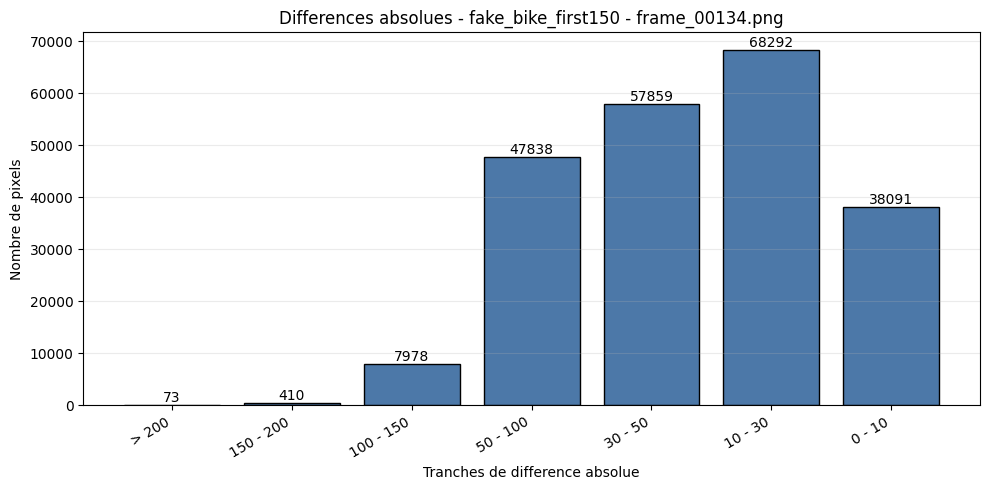

lvl:  4  initial error:  4174.890745501284


update too small, level converged! it:  4  error:  2349.9663527787993  lambda:  1.4411518807585588e+16
lvl:  3  initial error:  2461.484197826486


 error improvement too small, level converged! it:  20  error:  2308.2603795376886  lambda:  0.0


lvl:  2  initial error:  2375.450940115566


 error improvement too small, level converged! it:  4  error:  2346.1518622929702  lambda:  0.0


[fake_bike_first150] frame 135 -> frame_00135.png | sum error = 566161984.00 | mean abs error = 40.0241 | valid pixels = 220335


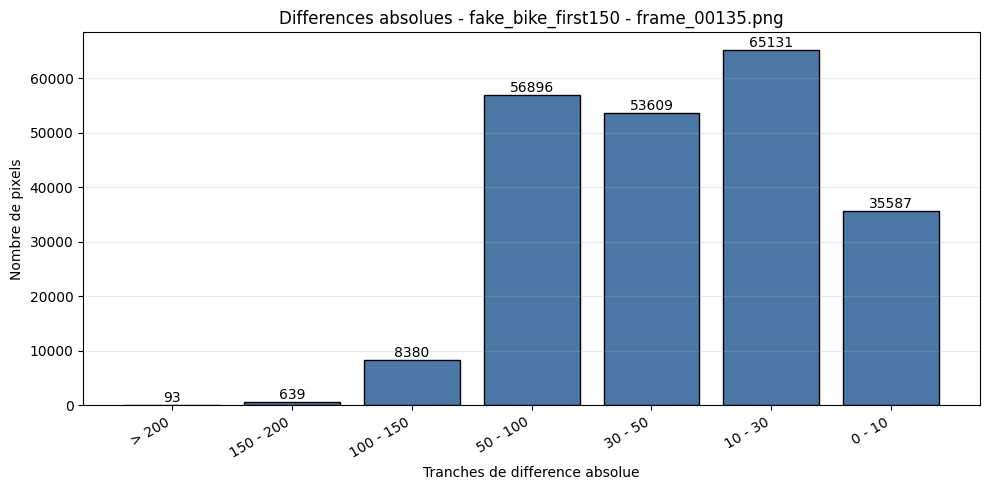

lvl:  4  initial error:  4441.0861182519275


update too small, level converged! it:  4  error:  2295.7440715032676  lambda:  7205759403792794.0
lvl:  3  initial error:  2472.5660374779577


 error improvement too small, level converged! it:  13  error:  2303.4777711548923  lambda:  0.0


lvl:  2  initial error:  2525.6766568405487


 error improvement too small, level converged! it:  7  error:  2448.058637255886  lambda:  0.0


[fake_bike_first150] frame 136 -> frame_00136.png | sum error = 567852544.00 | mean abs error = 39.2319 | valid pixels = 219210


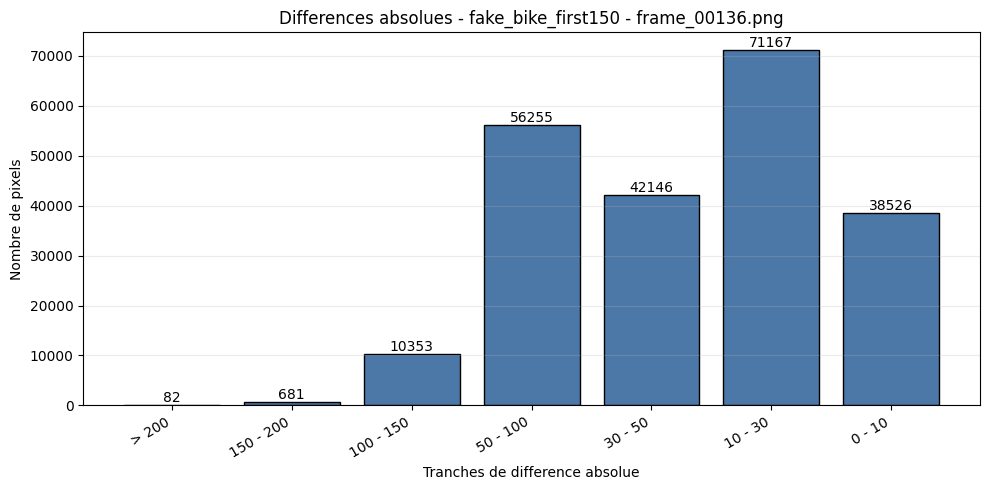

lvl:  4  initial error:  4402.841902313624


 error improvement too small, level converged! it:  4  error:  2334.093213551989  lambda:  28147497671065.6
lvl:  3  initial error:  2559.813767010766


 error improvement too small, level converged! it:  6  error:  2437.060978364188  lambda:  0.0


lvl:  2  initial error:  2598.7743296604917


 error improvement too small, level converged! it:  10  error:  2456.7944037010043  lambda:  0.0


[fake_bike_first150] frame 137 -> frame_00137.png | sum error = 570750464.00 | mean abs error = 39.6277 | valid pixels = 218371


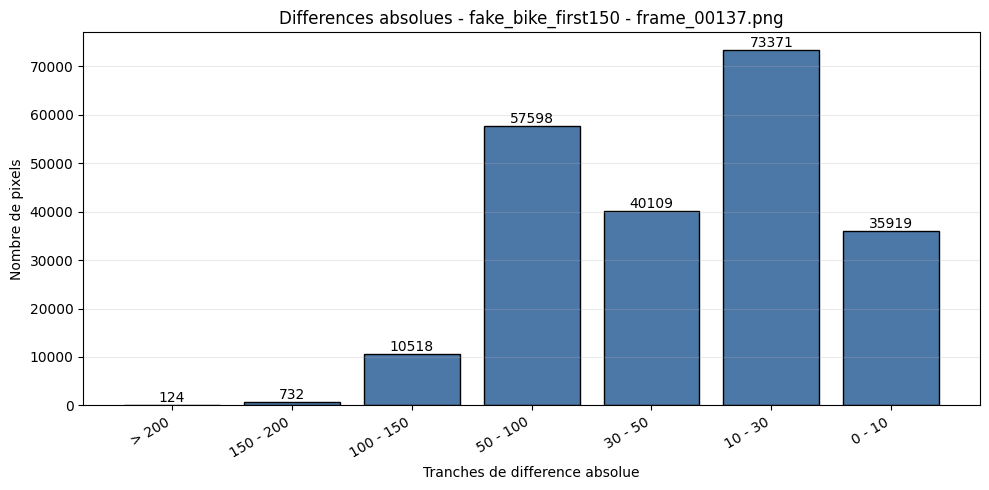

lvl:  4  initial error:  4543.428020565552


 error improvement too small, level converged! it:  14  error:  2109.85267075153  lambda:  0.0
lvl:  3  initial error:  2420.419113586365


 error improvement too small, level converged! it:  3  error:  2351.3090390410384  lambda:  0.0


lvl:  2  initial error:  2475.9016538256196


 error improvement too small, level converged! it:  8  error:  2431.6052929849643  lambda:  0.0


[fake_bike_first150] frame 138 -> frame_00138.png | sum error = 563347456.00 | mean abs error = 39.1421 | valid pixels = 217604


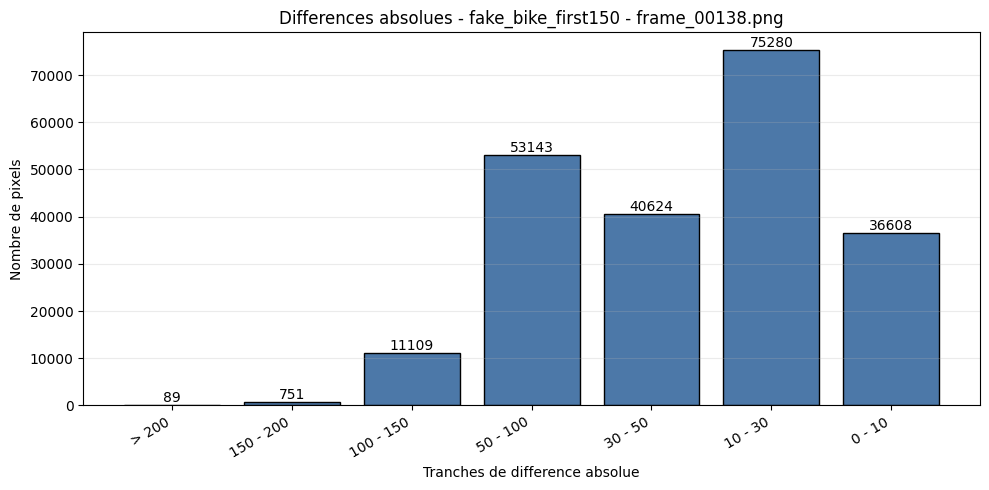

lvl:  4  initial error:  4592.273778920307
 error improvement too small, level converged! it:  2  error:  2167.354019333164  lambda:  0.1
lvl:  3  initial error:  2279.717586157222


 error improvement too small, level converged! it:  2  error:  2242.1211333717247  lambda:  0.0


lvl:  2  initial error:  2432.8135934930374


 error improvement too small, level converged! it:  22  error:  2312.925419554847  lambda:  0.0


[fake_bike_first150] frame 139 -> frame_00139.png | sum error = 528870880.00 | mean abs error = 37.7032 | valid pixels = 216939


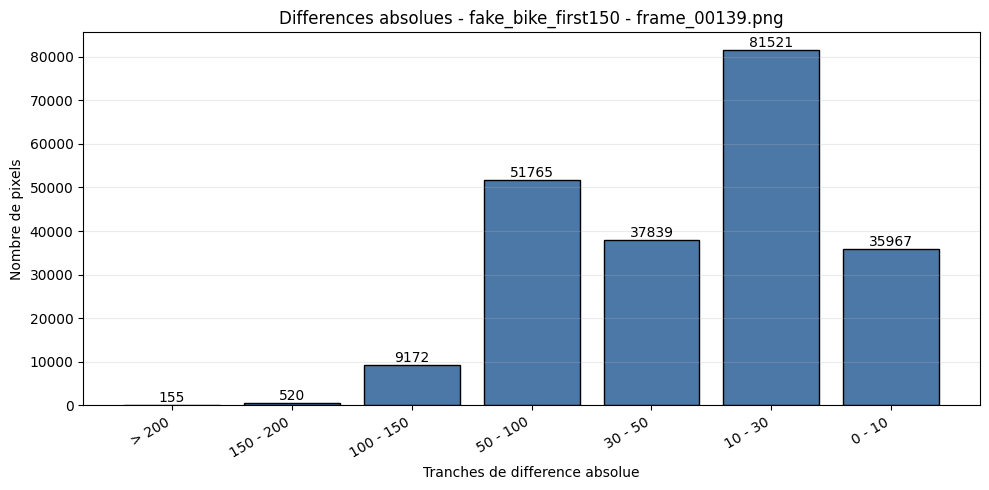

lvl:  4  initial error:  4392.929305912596


update too small, level converged! it:  10  error:  2058.9436122981374  lambda:  7205759403792794.0
lvl:  3  initial error:  2200.038303279237


 error improvement too small, level converged! it:  3  error:  2170.1576272549223  lambda:  0.0


lvl:  2  initial error:  2251.290284547407


 error improvement too small, level converged! it:  4  error:  2209.213253013044  lambda:  0.2


[fake_bike_first150] frame 140 -> frame_00140.png | sum error = 517319040.00 | mean abs error = 36.9586 | valid pixels = 218481


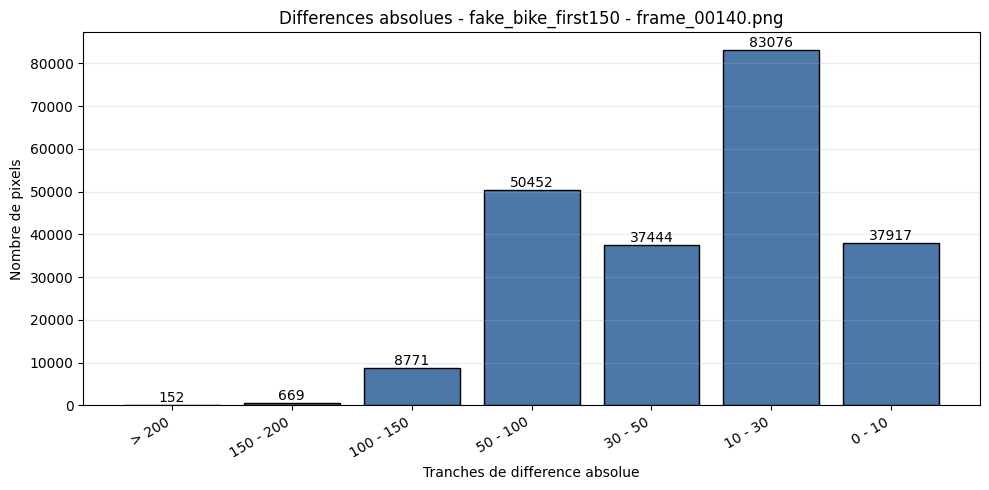

lvl:  4  initial error:  4449.417737789203


 error improvement too small, level converged! it:  9  error:  2023.7477275225963  lambda:  0.0
lvl:  3  initial error:  2198.2683400801316


 error improvement too small, level converged! it:  3  error:  2106.331435723172  lambda:  0.0


lvl:  2  initial error:  2224.4770162026753


 error improvement too small, level converged! it:  6  error:  2183.222077122077  lambda:  0.0


[fake_bike_first150] frame 141 -> frame_00141.png | sum error = 515227456.00 | mean abs error = 37.4259 | valid pixels = 219770


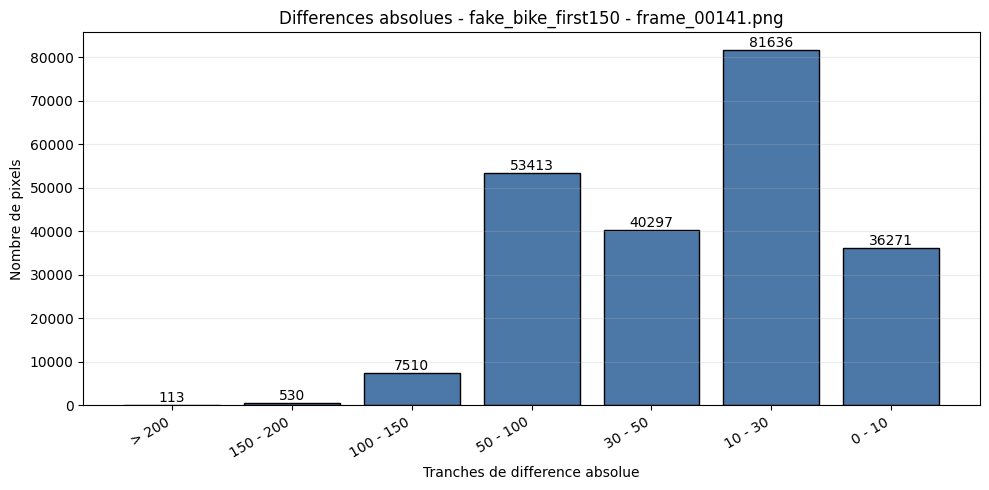

lvl:  4  initial error:  4170.1889460154225


 error improvement too small, level converged! it:  6  error:  2015.3059386593202  lambda:  3.2
lvl:  3  initial error:  2131.247207448931


 error improvement too small, level converged! it:  3  error:  2099.706025125557  lambda:  0.0


lvl:  2  initial error:  2231.766412060146


 error improvement too small, level converged! it:  4  error:  2200.1202095283315  lambda:  0.0


[fake_bike_first150] frame 142 -> frame_00142.png | sum error = 523271936.00 | mean abs error = 37.6169 | valid pixels = 220541


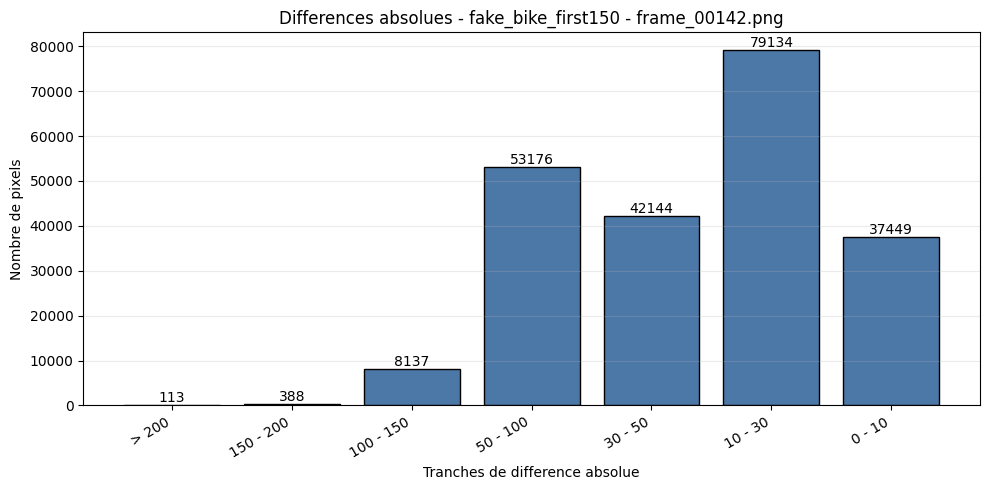

lvl:  4  initial error:  4028.74678663239


update too small, level converged! it:  10  error:  2155.216802857823  lambda:  450359962737049.6
lvl:  3  initial error:  2206.4520244460914


 error improvement too small, level converged! it:  12  error:  2071.780980732733  lambda:  0.0


lvl:  2  initial error:  2207.2850101790614


 error improvement too small, level converged! it:  3  error:  2189.2760208374475  lambda:  439804651110.4


[fake_bike_first150] frame 143 -> frame_00143.png | sum error = 515250272.00 | mean abs error = 37.7152 | valid pixels = 220541


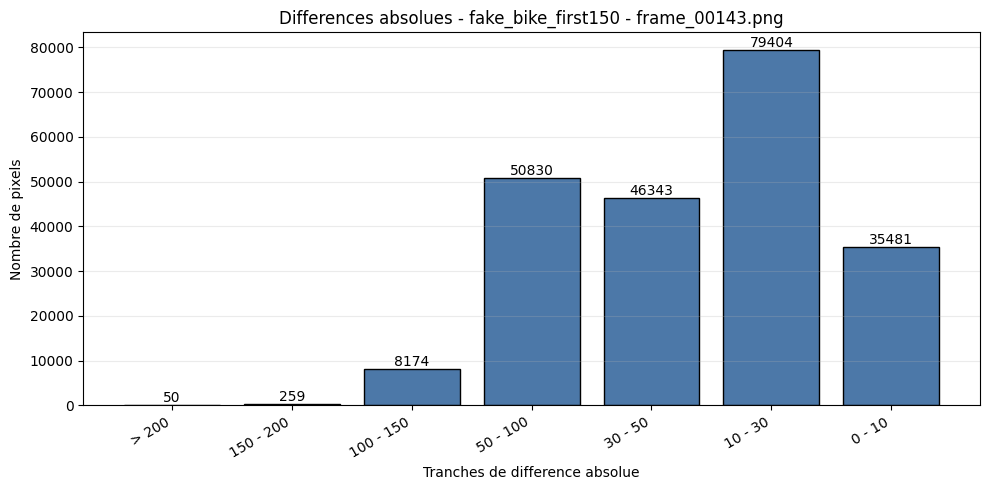

lvl:  4  initial error:  3795.992287917737


 error improvement too small, level converged! it:  8  error:  1992.3328080008655  lambda:  0.0
lvl:  3  initial error:  2448.030580777822


 error improvement too small, level converged! it:  7  error:  2255.5630907218024  lambda:  0.0


lvl:  2  initial error:  2431.7298821883805


 error improvement too small, level converged! it:  11  error:  2375.8609159733282  lambda:  0.0


[fake_bike_first150] frame 144 -> frame_00144.png | sum error = 562893184.00 | mean abs error = 39.6585 | valid pixels = 220541


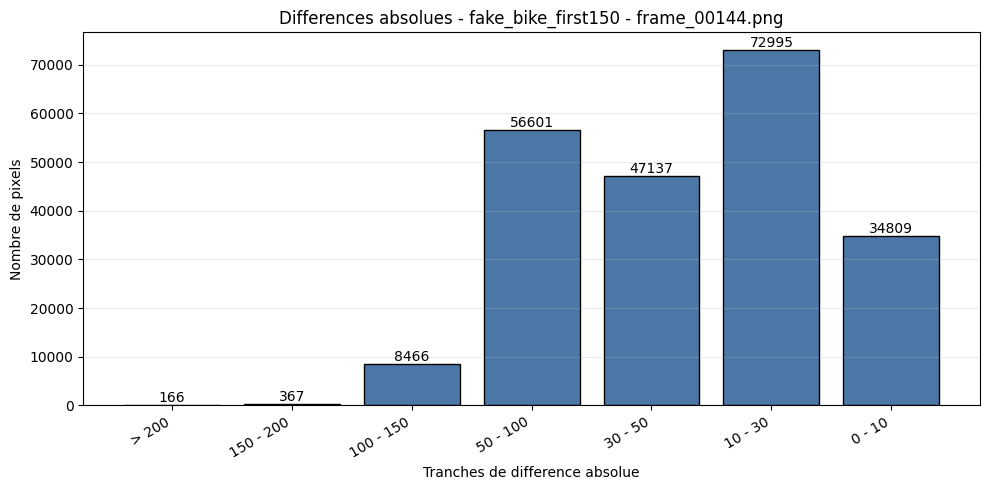

lvl:  4  initial error:  4112.71208226221


 error improvement too small, level converged! it:  5  error:  2130.105512396741  lambda:  6.4
lvl:  3  initial error:  2373.3510255138285


 error improvement too small, level converged! it:  5  error:  2308.792964674549  lambda:  0.0


lvl:  2  initial error:  2466.288248905896


 error improvement too small, level converged! it:  24  error:  2276.5285037715885  lambda:  0.0


[fake_bike_first150] frame 145 -> frame_00145.png | sum error = 532148960.00 | mean abs error = 38.4561 | valid pixels = 220541


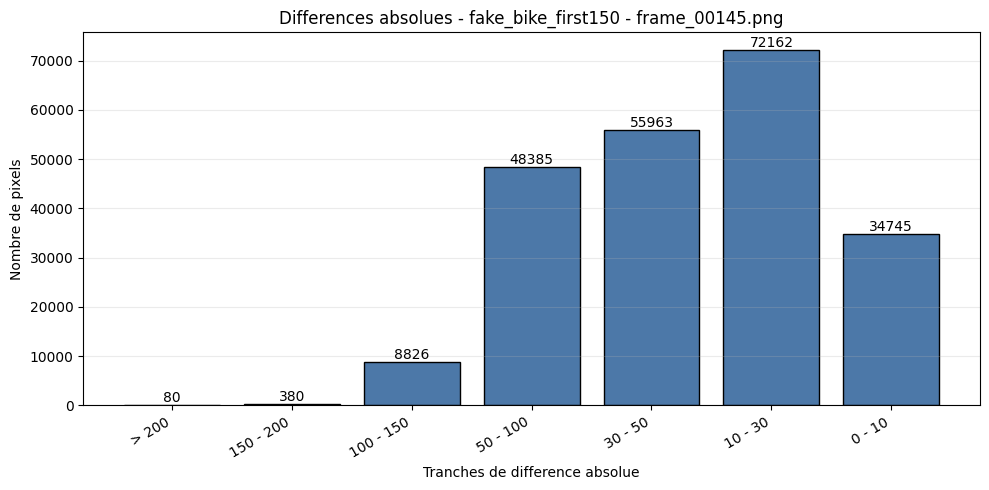

lvl:  4  initial error:  4166.2802056555265


 error improvement too small, level converged! it:  4  error:  2243.618388039864  lambda:  12.8
lvl:  3  initial error:  2277.3525251523156


 error improvement too small, level converged! it:  7  error:  2215.8224931845866  lambda:  0.0


lvl:  2  initial error:  2367.661877882514


 error improvement too small, level converged! it:  6  error:  2316.7493628477832  lambda:  0.0


[fake_bike_first150] frame 146 -> frame_00146.png | sum error = 550760768.00 | mean abs error = 39.5045 | valid pixels = 219423


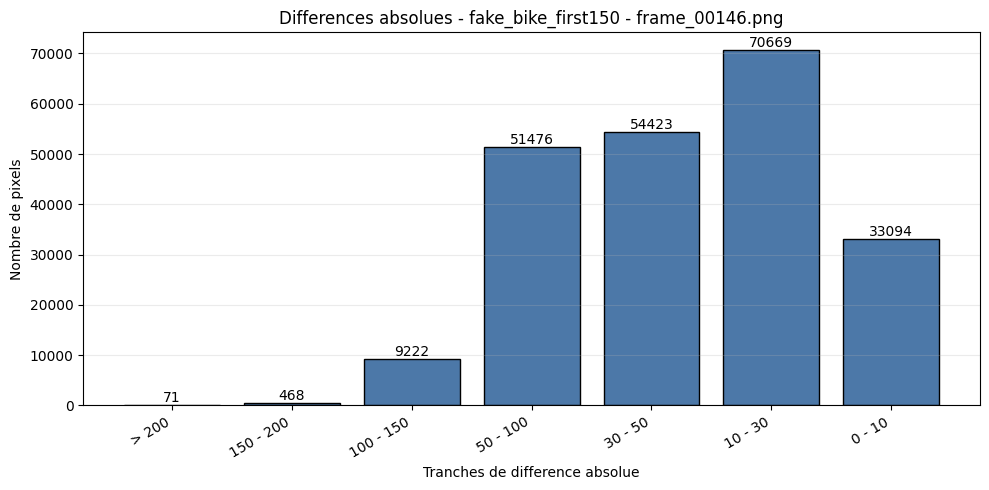

lvl:  4  initial error:  4242.412596401027


 error improvement too small, level converged! it:  6  error:  2317.2721494044295  lambda:  0.0
lvl:  3  initial error:  2401.59946207628


 error improvement too small, level converged! it:  5  error:  2300.1916362290863  lambda:  0.0


lvl:  2  initial error:  2462.770962441749


 error improvement too small, level converged! it:  10  error:  2418.112039161106  lambda:  0.0


[fake_bike_first150] frame 147 -> frame_00147.png | sum error = 565022144.00 | mean abs error = 39.7679 | valid pixels = 219323


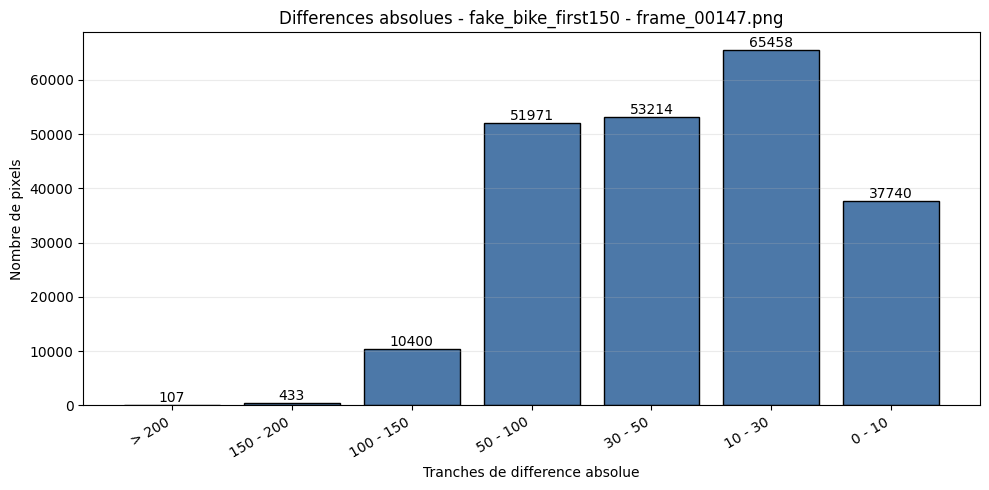

lvl:  4  initial error:  4324.160668380461


 error improvement too small, level converged! it:  7  error:  2256.9811907323747  lambda:  0.8
lvl:  3  initial error:  2443.6715016317885


 error improvement too small, level converged! it:  8  error:  2363.1073364944577  lambda:  0.0


lvl:  2  initial error:  2450.4481028449436


 error improvement too small, level converged! it:  4  error:  2412.7520701951557  lambda:  0.0


[fake_bike_first150] frame 148 -> frame_00148.png | sum error = 567108032.00 | mean abs error = 40.1114 | valid pixels = 219381


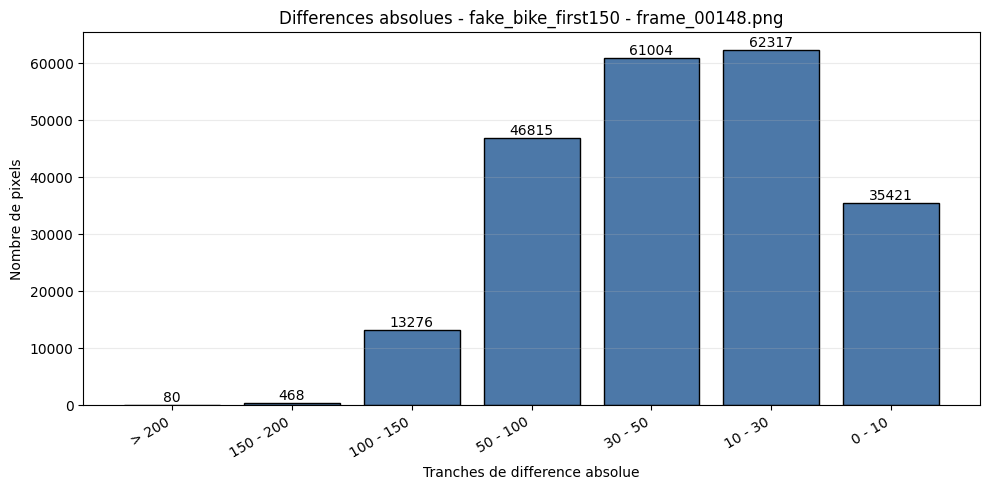

lvl:  4  initial error:  4327.374035989716


 error improvement too small, level converged! it:  4  error:  2349.0274581773183  lambda:  3518437208883.2
lvl:  3  initial error:  2478.9671774108365


 error improvement too small, level converged! it:  7  error:  2372.7416428041715  lambda:  0.0


lvl:  2  initial error:  2559.0843776675133


 error improvement too small, level converged! it:  6  error:  2509.049732963692  lambda:  0.0


[fake_bike_first150] frame 149 -> frame_00149.png | sum error = 584933312.00 | mean abs error = 40.6437 | valid pixels = 218947


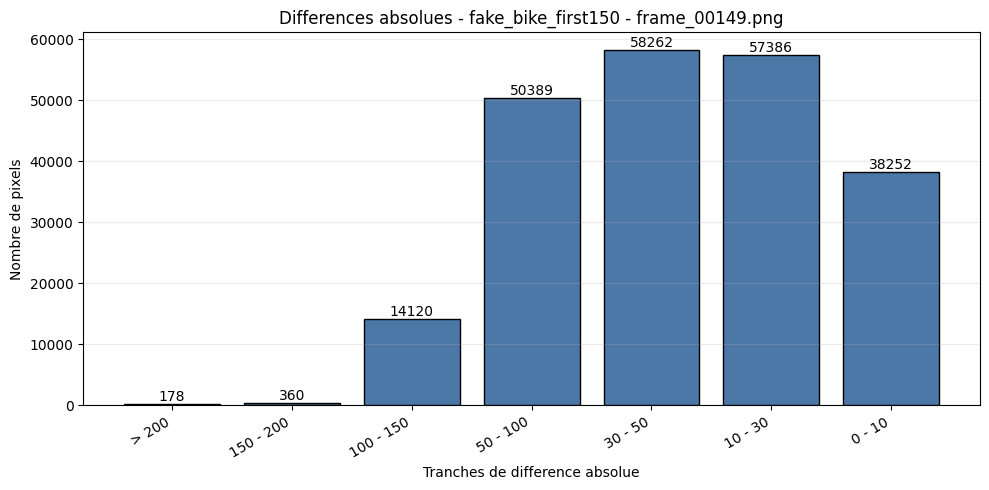

In [32]:
# Boucle simple sur toute la sequence: depth estimation puis pose estimation par frame.
# Cette version reconstruit une camera coherente pour la sequence traitee
# et reinitialise le solveur pour eviter de reutiliser un etat precedent.
frame_paths = fake_frame_paths[:150]

if len(frame_paths) < 2:
    raise ValueError("Il faut au moins 2 frames pour lancer le pipeline.")

sequence_name = "fake_bike_first150"
sequence_keyframe = None
sequence_results = []

first_image_path = normalize_image_path(frame_paths[0])
first_image = load_gray_image(first_image_path)
sequence_height, sequence_width = first_image.shape[:2]

sequence_cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    sequence_width,
    sequence_height,
)
sequence_pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(sequence_cam, show_debug=False)

print(f"Sequence {sequence_name}:")
print(f"  source size = {sequence_width} x {sequence_height}")
print(f"  working size level-0 = {sequence_cam.width[0]} x {sequence_cam.height[0]}")
print(f"  fx level-0 = {sequence_cam.fx[0]}")
print(f"  fy level-0 = {sequence_cam.fy[0]}")
print()

for step, image_path in enumerate(frame_paths):
    image_path = normalize_image_path(image_path)
    image = load_gray_image(image_path)

    if image.shape[:2] != (sequence_height, sequence_width):
        raise ValueError(
            f"Toutes les images de la sequence {sequence_name} doivent avoir la meme taille. "
            f"Attendu: {(sequence_height, sequence_width)}, obtenu: {image.shape[:2]} pour {image_path.name}"
        )

    depth_map = load_depth_map(image_path)
    inv_depth, inv_depth_var, depth_valid_mask = depth_to_invdepth(depth_map)

    current_frame = frameData.frameData()
    current_frame.setImage(image)
    current_frame.setInvDepth(inv_depth, inv_depth_var)

    if step == 0:
        sequence_keyframe = current_frame
        print(f"[{sequence_name}] frame {step} -> keyframe de reference: {image_path.name}")
        sequence_results.append(
            {
                "index": step,
                "image_path": str(image_path),
                "depth_valid_ratio": float(depth_valid_mask.mean()),
                "pose_matrix": current_frame.pose.as_matrix(),
                "photometric_error": None,
                "photometric_error_mean": None,
                "valid_pixel_count": None,
                "histogram_counts": None,
            }
        )
        continue

    sequence_pose_solver.optPose(current_frame, sequence_keyframe)
    evaluation = compute_photometric_error(current_frame, sequence_keyframe, sequence_cam, lvl=0)

    abs_error_map = np.sqrt(evaluation["squared_error_map"])
    valid_mask = evaluation["valid_mask"]
    valid_abs_errors = abs_error_map[valid_mask]
    valid_pixel_count = int(valid_abs_errors.size)
    photometric_error = float(evaluation["photometric_error"])
    photometric_error_mean = float(valid_abs_errors.mean()) if valid_pixel_count > 0 else None
    mean_error_display = f"{photometric_error_mean:.4f}" if photometric_error_mean is not None else "None"

    print(
        f"[{sequence_name}] frame {step} -> {image_path.name} | "
        f"sum error = {photometric_error:.2f} | "
        f"mean abs error = {mean_error_display} | "
        f"valid pixels = {valid_pixel_count}"
    )

    num_gt_200 = int(np.sum(valid_abs_errors > 200))
    num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
    num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
    num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))
    num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))
    num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))
    num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

    range_labels = [
        "> 200",
        "150 - 200",
        "100 - 150",
        "50 - 100",
        "30 - 50",
        "10 - 30",
        "0 - 10",
    ]

    range_counts = [
        num_gt_200,
        num_150_200,
        num_100_150,
        num_50_100,
        num_30_50,
        num_10_30,
        num_0_10,
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
    plt.title(f"Differences absolues - {sequence_name} - {image_path.name}")
    plt.xlabel("Tranches de difference absolue")
    plt.ylabel("Nombre de pixels")
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=30, ha="right")

    for bar, count in zip(bars, range_counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    sequence_results.append(
        {
            "index": step,
            "image_path": str(image_path),
            "depth_valid_ratio": float(depth_valid_mask.mean()),
            "pose_matrix": current_frame.pose.as_matrix(),
            "photometric_error": photometric_error,
            "photometric_error_mean": photometric_error_mean,
            "valid_pixel_count": valid_pixel_count,
            "histogram_counts": range_counts,
        }
    )


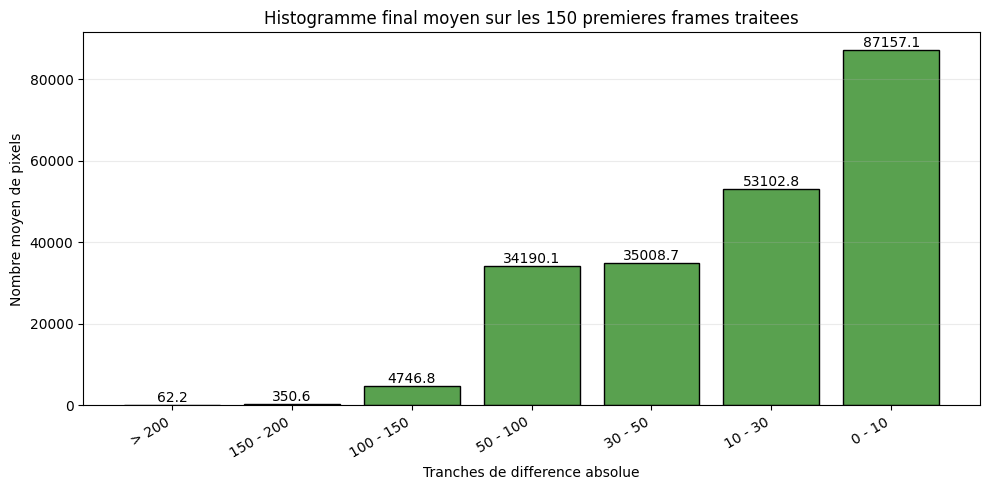

Histogramme final moyen:
     > 200 -> 62.17
  150 - 200 -> 350.61
  100 - 150 -> 4746.76
  50 - 100 -> 34190.06
   30 - 50 -> 35008.69
   10 - 30 -> 53102.81
    0 - 10 -> 87157.12
Image sauvegardee : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\image\fake_bike_first150_mean_histogram.png


In [33]:
valid_histogram_results = [
    item for item in sequence_results
    if item.get("histogram_counts") is not None
]

if not valid_histogram_results:
    raise ValueError("Aucun histogramme valide disponible pour calculer la moyenne finale.")

histogram_matrix = np.array([item["histogram_counts"] for item in valid_histogram_results], dtype=np.float64)
mean_histogram_counts = histogram_matrix.mean(axis=0)

final_range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

plt.figure(figsize=(10, 5))
bars = plt.bar(final_range_labels, mean_histogram_counts, color="#59A14F", edgecolor="black")
plt.title("Histogramme final moyen sur les 150 premieres frames traitees")
plt.xlabel("Tranches de difference absolue")
plt.ylabel("Nombre moyen de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, mean_histogram_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
final_histogram_path = IMAGE_OUTPUT_DIR / "fake_bike_first150_mean_histogram.png"
plt.savefig(final_histogram_path, dpi=150, bbox_inches="tight")
plt.show()

print("Histogramme final moyen:")
for label, value in zip(final_range_labels, mean_histogram_counts):
    print(f"  {label:>8} -> {value:.2f}")
print(f"Image sauvegardee : {final_histogram_path}")


325771161.4228188


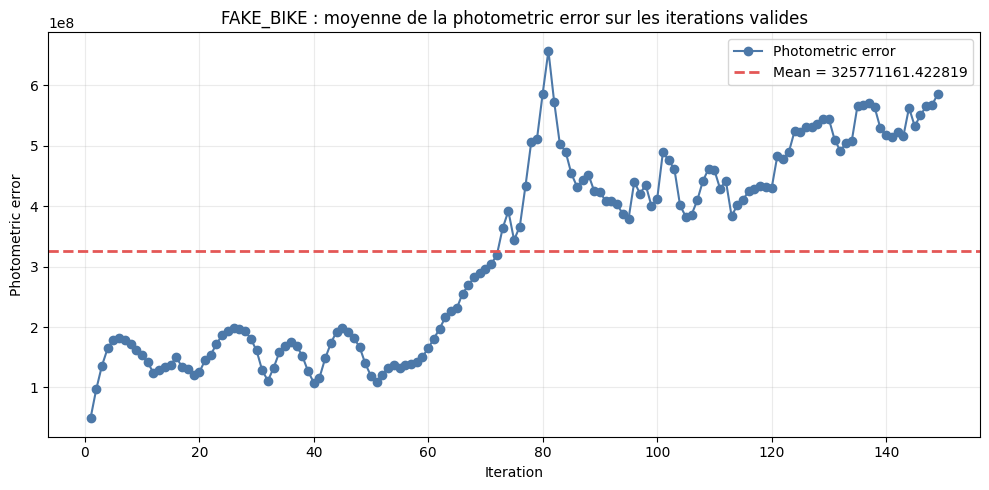

Image sauvegardee : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\image\fake_bike_first150_photometric_error.png


In [34]:
valid_results = [
    item for item in sequence_results
    if item["photometric_error"] is not None
]

if not valid_results:
    raise ValueError("Aucun resultat valide disponible pour calculer la moyenne des erreurs photometriques.")

iteration_indices = [item["index"] for item in valid_results]
photometric_errors = [item["photometric_error"] for item in valid_results]
mean_photometric_error = float(np.mean(photometric_errors))

print(mean_photometric_error)

plt.figure(figsize=(10, 5))
plt.plot(iteration_indices, photometric_errors, marker="o", color="#4C78A8", label="Photometric error")
plt.axhline(
    mean_photometric_error,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_photometric_error:.6f}"
)
plt.title("FAKE_BIKE : moyenne de la photometric error sur les iterations valides")
plt.xlabel("Iteration")
plt.ylabel("Photometric error")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
final_error_curve_path = IMAGE_OUTPUT_DIR / "fake_bike_first150_photometric_error.png"
plt.savefig(final_error_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Image sauvegardee : {final_error_curve_path}")
